# RAPIDS & Scanpy Single-Cell RNA-seq Workflow on mouse PFC cells

Copyright (c) 2020, NVIDIA CORPORATION.

Licensed under the Apache License, Version 2.0 (the "License") you may not use this file except in compliance with the License. You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

This notebook demonstrates a single-cell RNA analysis workflow that begins with preprocessing a count matrix of size `(n_gene, n_cell)` and results in a visualization of the clustered cells for further analysis.

For demonstration purposes, we use a dataset of 1.3 M brain cells with Unified Virtual Memory to oversubscribe GPU memory.

## Import requirements

In [2]:
import numpy as np
import scanpy as sc
import anndata

import time
import os, wget

import cupy as cp
import cupyx as cpx
import cudf

from cuml.decomposition import PCA
from cuml.manifold import TSNE
from cuml.cluster import KMeans
from cuml.preprocessing import StandardScaler

import rapids_scanpy_funcs
import utils

import warnings
warnings.filterwarnings('ignore', 'Expected ')
warnings.simplefilter('ignore')
import pandas as pd
from sh import gunzip
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import rmm

# managed_memory オプションなどで RMM を初期化
#rmm.reinitialize(managed_memory=True)

from rmm.allocators.cupy import rmm_cupy_allocator
import cupy
cupy.cuda.set_allocator(rmm_cupy_allocator)

import calculation_tool as ct
import gc

gc.collect()
cp.get_default_memory_pool().free_all_blocks()

In [ ]:
import sys, os, platform, subprocess, json

print("=== Python / OS ===")
print(sys.version)
print(platform.platform())

def sh(cmd):
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True, timeout=10)
        print(f"$ {cmd}\n{out}")
    except Exception as e:
        print(f"$ {cmd}\n<failed> {e}")

print("\n=== GPU / Driver ===")
sh("nvidia-smi --query-gpu=driver_version,name,memory.total,memory.used --format=csv,noheader")

print("\n=== Key Python pkgs ===")
def ver(mod):
    try:
        m = __import__(mod)
        v = getattr(m, "__version__", "<no __version__>")
        print(f"{mod}: {v}")
        return m
    except Exception as e:
        print(f"{mod}: <not found> ({e})")

cupy = ver("cupy")
cudf = ver("cudf")
cuml = ver("cuml")
sk = ver("sklearn")
an = ver("anndata")
sc = ver("scanpy")

if cupy:
    try:
        print("\n=== CuPy config ===")
        cupy.show_config()
        import cupy.cuda.runtime as rt
        print("CUDA runtime version:", rt.runtimeGetVersion())
        import cupy.cuda.device as dev
        with dev.Device(0):
            free, total = dev.mem_info
            print(f"GPU0 mem free/total: {free/1024**3:.2f} / {total/1024**3:.2f} GiB")
    except Exception as e:
        print("CuPy check failed:", e)

print("\n=== Env (threads, CUDA) ===")
for k in ["CUDA_VISIBLE_DEVICES", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "CUML_LOG_LEVEL", "RMM_POOL_SIZE"]:
    print(k, "=", os.environ.get(k))


We use the RAPIDS memory manager to enable Unified Virtual Memory management, which allows us to oversubscribe the GPU memory.

## Input data

In the cell below, we provide the path to the sparse `.h5ad` file containing the count matrix to analyze. Please see the README for instructions on how to download the dataset we use here.

To run this notebook using your own dataset, please see the README for instructions to convert your own count matrix into this format. Then, replace the path in the cell below with the path to your generated `.h5ad` file.

In [ ]:
import os
import urllib.request
import gzip
import shutil

url_list=[r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482102&format=file&file=GSM5482102%5FPFC%5FWT%5FRep1%5Fbarcodes%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482102&format=file&file=GSM5482102%5FPFC%5FWT%5FRep1%5Ffeatures%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482102&format=file&file=GSM5482102%5FPFC%5FWT%5FRep1%5Fmatrix%2Emtx%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482103&format=file&file=GSM5482103%5FPFC%5FWT%5FRep2%5Fbarcodes%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482103&format=file&file=GSM5482103%5FPFC%5FWT%5FRep2%5Ffeatures%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482103&format=file&file=GSM5482103%5FPFC%5FWT%5FRep2%5Fmatrix%2Emtx%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482104&format=file&file=GSM5482104%5FPFC%5FSetd1aHet%5FRep1%5Fbarcodes%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482104&format=file&file=GSM5482104%5FPFC%5FSetd1aHet%5FRep1%5Ffeatures%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482104&format=file&file=GSM5482104%5FPFC%5FSetd1aHet%5FRep1%5Fmatrix%2Emtx%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482105&format=file&file=GSM5482105%5FPFC%5FSetd1aHet%5FRep2%5Fbarcodes%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482105&format=file&file=GSM5482105%5FPFC%5FSetd1aHet%5FRep2%5Ffeatures%2Etsv%2Egz",
r"https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5482105&format=file&file=GSM5482105%5FPFC%5FSetd1aHet%5FRep2%5Fmatrix%2Emtx%2Egz"]

def download_file(url, dir, file_name):
    full_path = os.path.join(dir, file_name)
    urllib.request.urlretrieve(url, full_path)
    # 以下のコメントアウト部分を活用する場合は、解凍の手順を追加することができます。
    # with gzip.open(full_path, 'rb') as f_in:
    #     with open(full_path[:-3], 'wb') as f_out:
    #         shutil.copyfileobj(f_in, f_out)

dir = "/data/mouse_PFC/"

for url in url_list:
    acc = url.split("acc=")[1].split("&")[0]
    file_name_from_url = url.split("file=")[1]

    # WTとSetd1aHetのサブフォルダを作成
    subfolder = "WT" if "WT" in file_name_from_url else "Setd1aHet"
    acc_dir = os.path.join(dir,subfolder, acc)
    os.makedirs(acc_dir, exist_ok=True)

    # 標準的なファイル名に変更（.gzを取り除く）
    standard_file_name = file_name_from_url.split('_')[-1].replace('.gz', '')
    
    if "barcodes" in file_name_from_url:
        standard_file_name = "barcodes.tsv.gz"
    elif "features" in file_name_from_url:
        standard_file_name = "features.tsv.gz"
    elif "matrix" in file_name_from_url:
        standard_file_name = "matrix.mtx.gz"
    
    # ファイルをダウンロード
    download_file(url, acc_dir, standard_file_name)


In [ ]:
# ダウンロードディレクトリ
base_dir = "/data/mouse_PFC/"

def read_10x_mtx(path, label):
    """10x mtxフォーマットのデータを読み込み、指定されたラベルを追加します。"""
    adata = sc.read_10x_mtx(
        path,
        var_names='gene_symbols',
        cache=True
    )
    adata.obs['label'] = label
    return adata

labels = ["WT", "Setd1aHet"]

all_adatas = []

for label in labels:
    label_dir = os.path.join(base_dir, label)
    gsm_dirs = [os.path.join(label_dir, d) for d in os.listdir(label_dir) if os.path.isdir(os.path.join(label_dir, d))]
    
    for gsm_dir in gsm_dirs:
        if os.path.exists(gsm_dir):
            all_adatas.append(read_10x_mtx(gsm_dir, label))

# 全てのAnnDataオブジェクトを1つに結合
combined_adata = all_adatas[0].concatenate(all_adatas[1:], join='outer')

# .h5ad形式で保存
combined_adata.write("/data/mouse_PFC/combined_data.h5ad")

# WTのみ抽出
wt_adata = combined_adata[combined_adata.obs["label"] == "WT"].copy()

# 保存
wt_adata.write("/data/mouse_PFC/WT_only_data.h5ad")

## load data

In [ ]:
import gc
import cupy as cp
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

preprocess_in_bulk
HTR1E is not included
HTR1E is removed from marker list
DRD3 is not included
DRD3 is removed from marker list
CHRM4 is not included
CHRM4 is removed from marker list
ADRA2B is not included
ADRA2B is removed from marker list
NEUN is not included
NEUN is removed from marker list
['CX3CR1', 'CLDN5', 'GLUL', 'NDRG2', 'PCDH15', 'PLP1', 'MBP', 'SATB2', 'SLC17A7', 'SLC17A6', 'GAD2', 'GAD1', 'SNAP25', 'HTR1A', 'HTR1B', 'HTR1D', 'HTR2A', 'HTR2B', 'HTR2C', 'HTR3A', 'HTR4', 'HTR5A', 'HTR6', 'HTR7', 'DRD1', 'DRD2', 'DRD4', 'DRD5', 'HRH1', 'HRH2', 'HRH3', 'CHRM1', 'CHRM2', 'CHRM3', 'CHRM5', 'ADRA1A', 'ADRA1B', 'ADRA2A', 'ADRA2C', 'ADRB1', 'ADRB2', 'CAMK2A', 'CAMK2B', 'CUX1', 'CUX2', 'RORB', 'BCL6', 'BCL11B', 'FEZF2', 'TLE4', 'FOXP2', 'PCP4', 'PVALB', 'SST', 'GPR149', 'THSD7A', 'VIP', 'HTR3A', 'CRH', 'ADARB2', 'RELN', 'LAMP5']
perform regression
perform scale
float32
Total Preprocessing time: 10.272605657577515
shape of adata: (15759, 20789)
shape of adata: (15759, 20789)
perform 

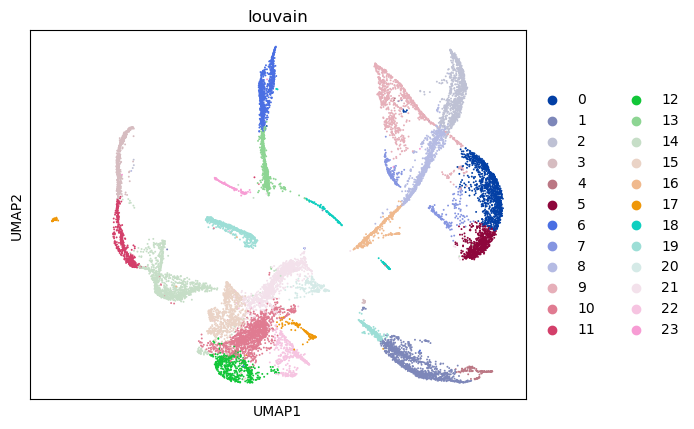

UMAP leiden


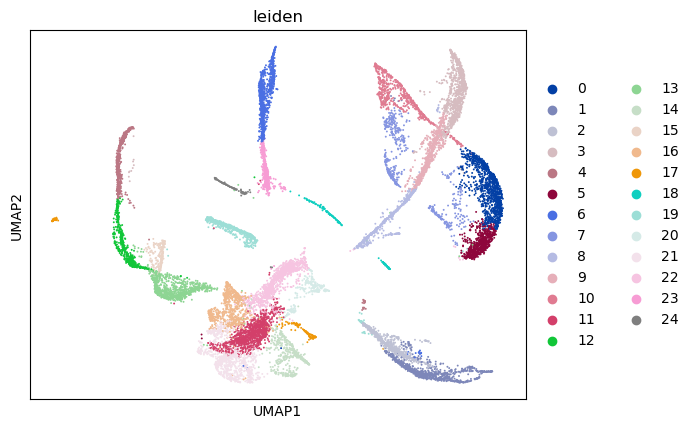

calc drug response
clz selective cells
# of clz selective cells: is_clz_selective
False    15540
True       219
Name: count, dtype: int64


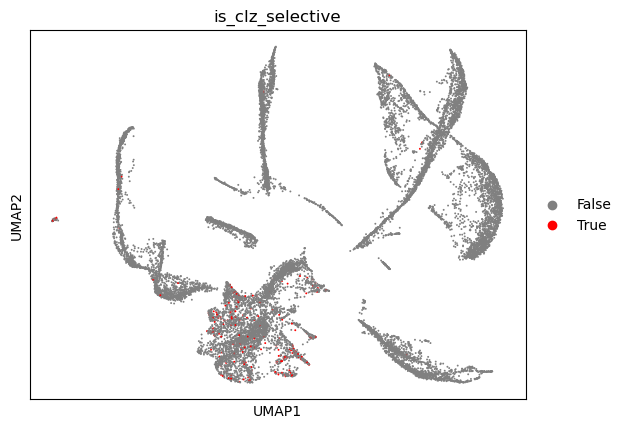

In [3]:
import calculation_tool as ct
#file_path="/data/mouse_PFC/combined_data.h5ad"
file_path="/data/mouse_PFC/WT_only_data.h5ad"
add_markers=["NEUN","CAMK2A","CAMK2B",    "CUX1", "CUX2", "RORB", "BCL6", "BCL11B", "FEZF2",
    "TLE4", "FOXP2", "PCP4", "PVALB", "SST", "GPR149", "THSD7A",
    "VIP", "HTR3A", "CRH", "ADARB2", "RELN", "LAMP5"]
adata,GPCR_df=ct.preprocess_adata_in_bulk(file_path,label=None,add_markers=add_markers)
#GPCR_df.to_csv("/data/mouse_PFC/combined_data_GPCR_df.csv")
GPCR_df.to_csv("/data/mouse_PFC/WT_only_data_GPCR_df.csv")

In [7]:
import calculation_tool as ct
D_R_mtx,GPCR_type_df,drug_list,GPCR_list=ct.load_parameters()
params=ct.set_parameters_for_preprocess(GPCR_list)

In [ ]:
file_path="/data/mouse_PFC/combined_data.h5ad"
adata = anndata.read_h5ad(file_path)

In [ ]:
GPCR_df=pd.read_csv("/data/mouse_PFC/combined_data_GPCR_df.csv")
#ct.drug_titeration(adata, GPCR_df, GPCR_type_df, drug_list, D_R_mtx)

clz selective cells
# of clz selective cells: is_clz_selective
False    15552
True       207
Name: count, dtype: int64


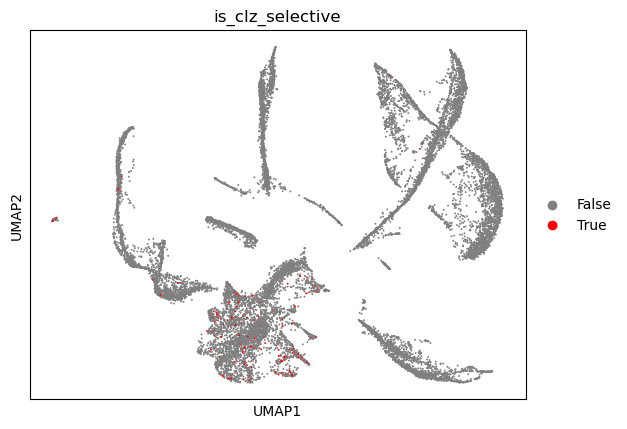

In [8]:
drug_conc=10**3
adata=ct.calc_drug_response(adata,GPCR_df,GPCR_type_df,drug_list,D_R_mtx,drug_conc)
selectivity_threshold=1.5
adata,num_clz_selective=ct.calc_clz_selective_cell(adata,drug_list,selectivity_threshold)

file_root, file_extension = os.path.splitext(file_path)
# Append '_processed' to the root and add the extension back
processed_file_path = f"{file_root}_processed{file_extension}"
adata.write(processed_file_path)

In [ ]:
file_path="/data/mouse_PFC/combined_data.h5ad"
file_root, file_extension = os.path.splitext(file_path)
# Append '_processed' to the root and add the extension back
processed_file_path = f"{file_root}_processed{file_extension}"
adata=anndata.read_h5ad(processed_file_path)

In [4]:
GPCR_adata=anndata.AnnData(X=GPCR_df)
GPCR_adata_norm=sc.pp.normalize_total(GPCR_adata,target_sum=1e4,inplace=False)['X']
GPCR_adata_norm_df=pd.DataFrame(GPCR_adata_norm,columns=GPCR_adata.var.index)


In [9]:
import calculation_tool as ct

drug_conc=10**4
results_df_sorted,all_responses=ct.sim_inhibit_pattern(adata,GPCR_adata_norm_df,GPCR_type_df,drug_conc,n_pattern=10000)

Pattern_1: {'HTR1A_raw': True, 'HTR1B_raw': False, 'HTR1D_raw': False, 'HTR2A_raw': False, 'HTR2B_raw': False, 'HTR2C_raw': True, 'HTR3A_raw': True, 'HTR4_raw': False, 'HTR5A_raw': True, 'HTR6_raw': True, 'HTR7_raw': True, 'DRD1_raw': False, 'DRD2_raw': False, 'DRD4_raw': True, 'DRD5_raw': True, 'HRH1_raw': True, 'HRH2_raw': False, 'HRH3_raw': True, 'CHRM1_raw': True, 'CHRM2_raw': False, 'CHRM3_raw': False, 'CHRM5_raw': True, 'ADRA1A_raw': False, 'ADRA1B_raw': False, 'ADRA2A_raw': False, 'ADRA2C_raw': False, 'ADRB1_raw': True, 'ADRB2_raw': True}
Pattern_2: {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1D_raw': True, 'HTR2A_raw': False, 'HTR2B_raw': False, 'HTR2C_raw': True, 'HTR3A_raw': True, 'HTR4_raw': False, 'HTR5A_raw': True, 'HTR6_raw': True, 'HTR7_raw': True, 'DRD1_raw': True, 'DRD2_raw': False, 'DRD4_raw': True, 'DRD5_raw': False, 'HRH1_raw': False, 'HRH2_raw': True, 'HRH3_raw': True, 'CHRM1_raw': False, 'CHRM2_raw': False, 'CHRM3_raw': True, 'CHRM5_raw': False, 'ADRA1A_raw': Tru

Simulating drug responses: 100%|██████████| 10000/10000 [02:04<00:00, 80.50it/s]

      pattern_name                                            pattern  \
4283  Pattern_4284  {'HTR1A_raw': True, 'HTR1B_raw': False, 'HTR1D...   
7410  Pattern_7411  {'HTR1A_raw': True, 'HTR1B_raw': True, 'HTR1D_...   
7567  Pattern_7568  {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1...   
4669  Pattern_4670  {'HTR1A_raw': True, 'HTR1B_raw': True, 'HTR1D_...   
3788  Pattern_3789  {'HTR1A_raw': False, 'HTR1B_raw': True, 'HTR1D...   

             diff  
4283  3127.361048  
7410  3116.902616  
7567  3108.250857  
4669  3099.436603  
3788  3098.919466  


In [5]:
dir="/data/mouse_PFC/WT_only"
results_df_sorted.to_csv(os.path.join(dir,"results_df_sorted.csv"))
all_responses.to_csv(os.path.join(dir,"all_responses.csv"))

NameError: name 'results_df_sorted' is not defined

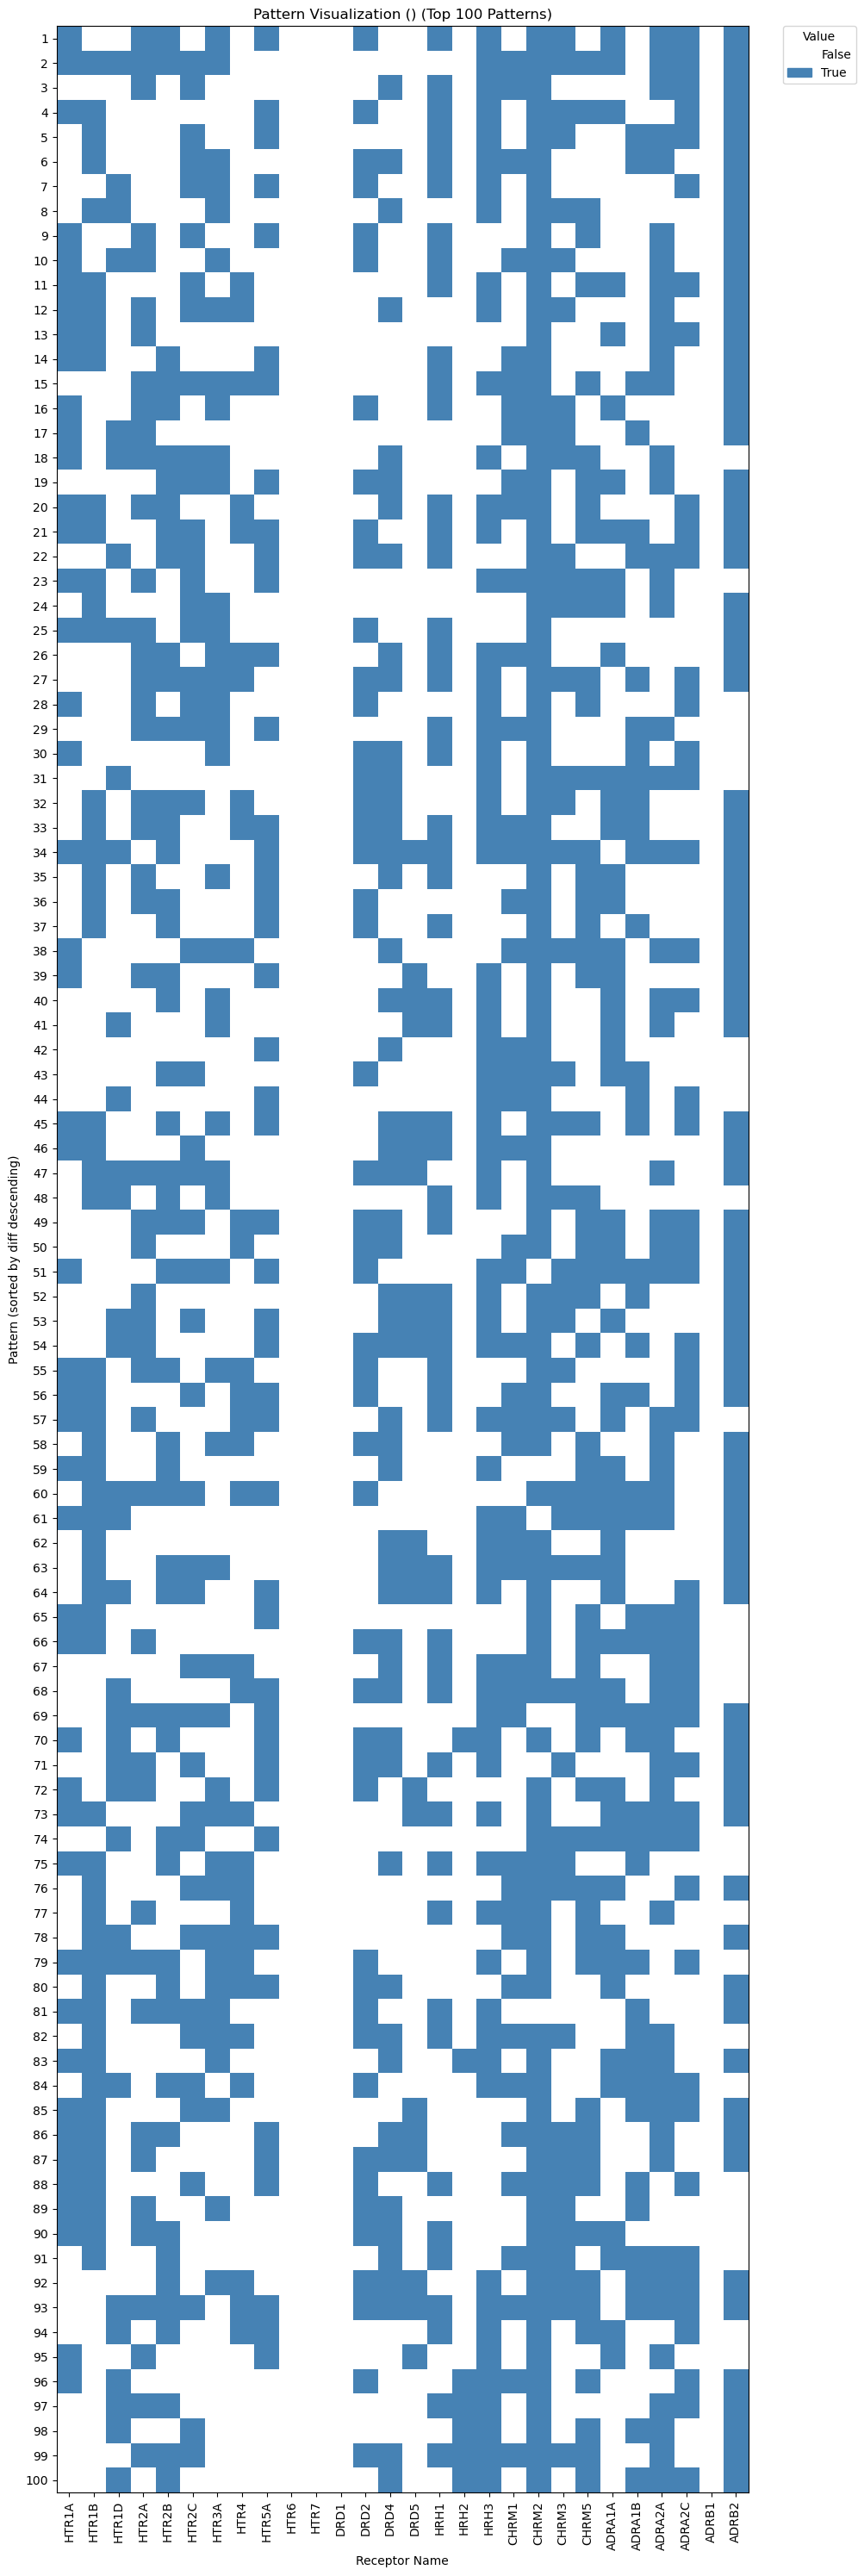

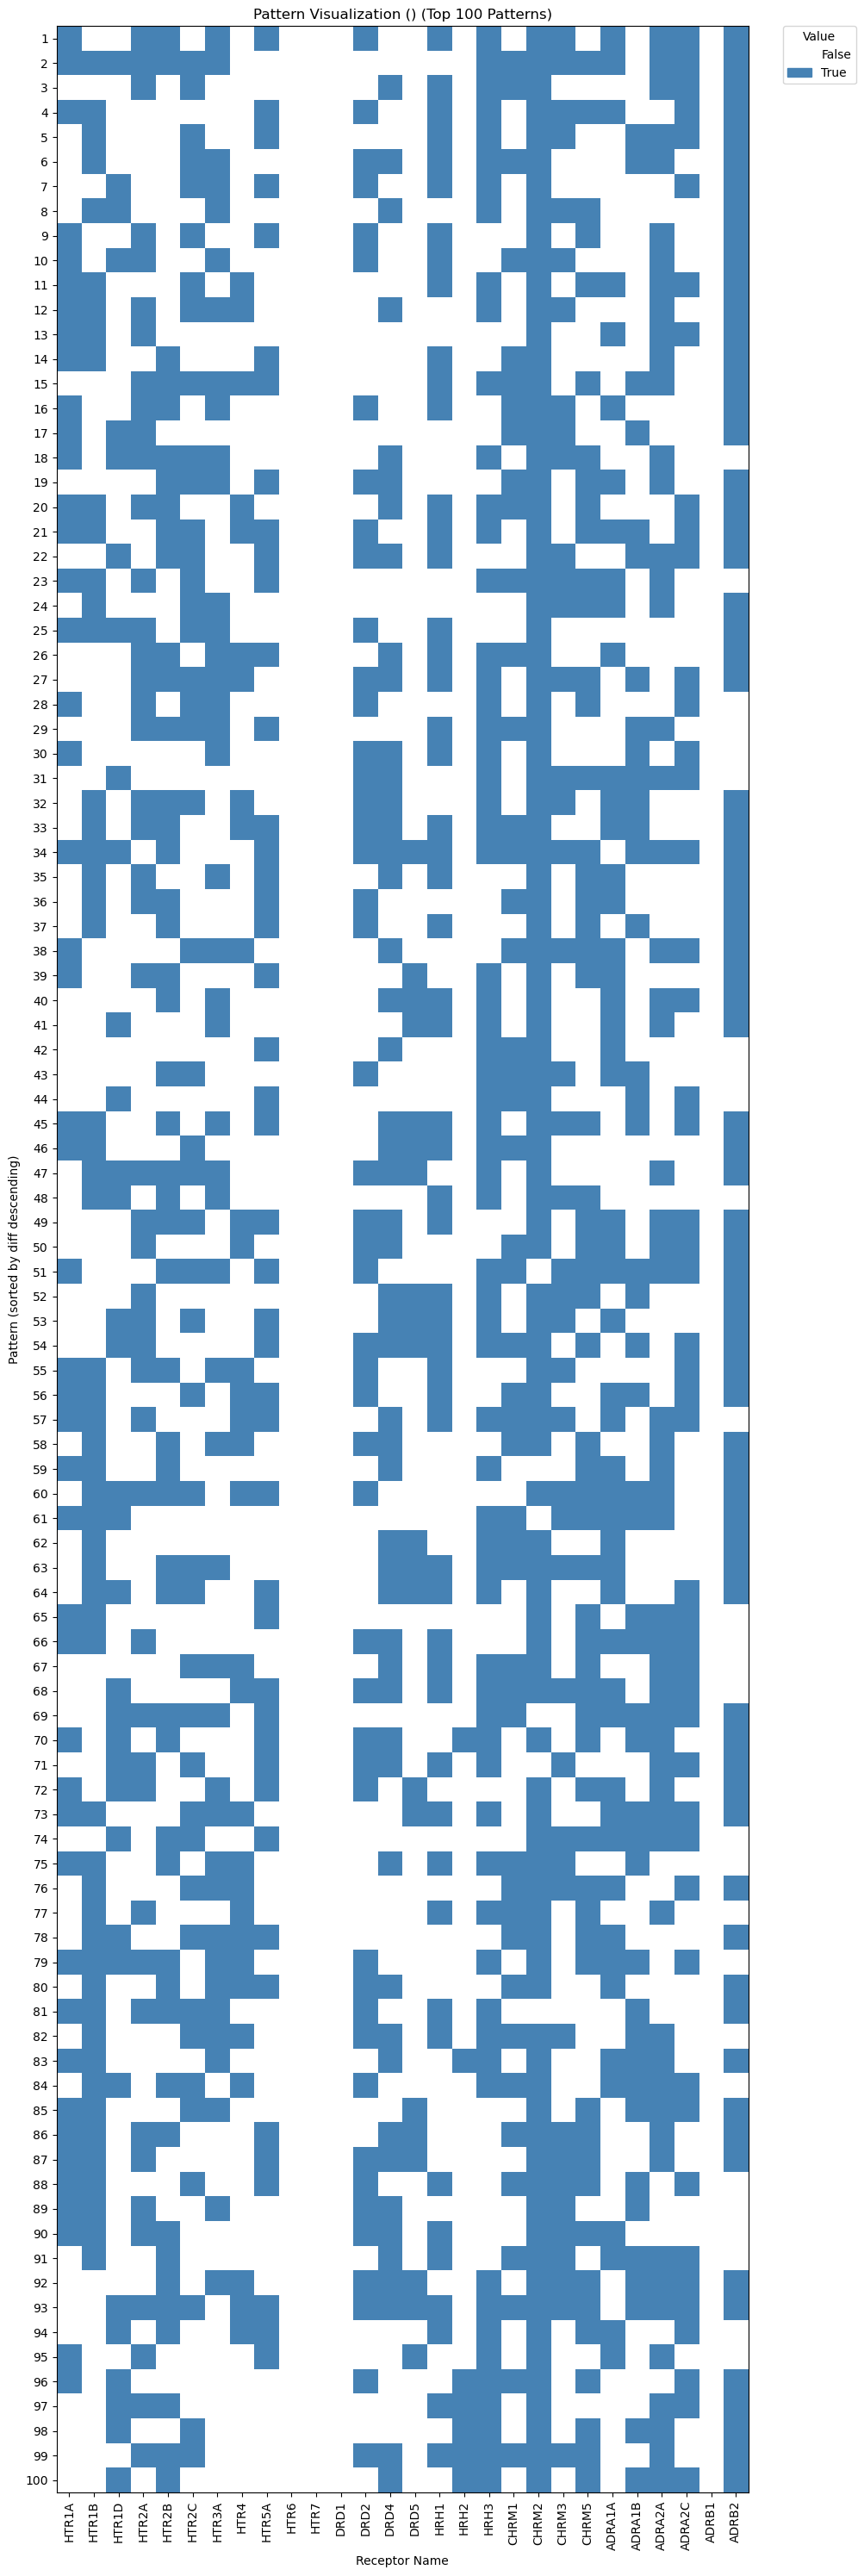

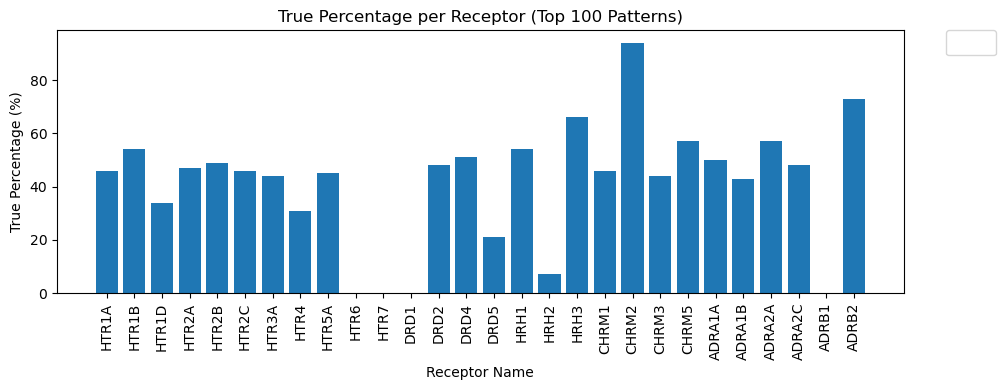

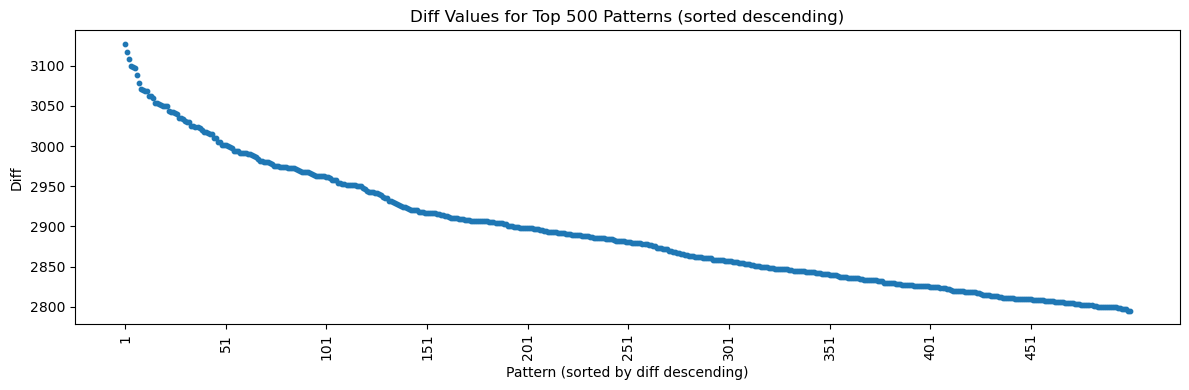

In [10]:
ct.visualize_patterns(results_df_sorted, top_n=100, top_n_for_heatmap=100, scatter_n=500)

Generating inhibition patterns: 100%|██████████| 3276/3276 [00:00<00:00, 172431.39it/s]


Pattern_1: {'HTR1A_raw': True, 'HTR1B_raw': True, 'HTR1D_raw': True, 'HTR2A_raw': False, 'HTR2B_raw': False, 'HTR2C_raw': False, 'HTR3A_raw': False, 'HTR4_raw': False, 'HTR5A_raw': False, 'HTR6_raw': False, 'HTR7_raw': False, 'DRD1_raw': False, 'DRD2_raw': False, 'DRD4_raw': False, 'DRD5_raw': False, 'HRH1_raw': False, 'HRH2_raw': False, 'HRH3_raw': False, 'CHRM1_raw': False, 'CHRM2_raw': False, 'CHRM3_raw': False, 'CHRM5_raw': False, 'ADRA1A_raw': False, 'ADRA1B_raw': False, 'ADRA2A_raw': False, 'ADRA2C_raw': False, 'ADRB1_raw': False, 'ADRB2_raw': False}
Pattern_2: {'HTR1A_raw': True, 'HTR1B_raw': True, 'HTR1D_raw': False, 'HTR2A_raw': True, 'HTR2B_raw': False, 'HTR2C_raw': False, 'HTR3A_raw': False, 'HTR4_raw': False, 'HTR5A_raw': False, 'HTR6_raw': False, 'HTR7_raw': False, 'DRD1_raw': False, 'DRD2_raw': False, 'DRD4_raw': False, 'DRD5_raw': False, 'HRH1_raw': False, 'HRH2_raw': False, 'HRH3_raw': False, 'CHRM1_raw': False, 'CHRM2_raw': False, 'CHRM3_raw': False, 'CHRM5_raw': False

Simulating drug responses: 100%|██████████| 3276/3276 [00:40<00:00, 81.49it/s]


      pattern_name                                            pattern  \
3127  Pattern_3128  {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1...   
322    Pattern_323  {'HTR1A_raw': True, 'HTR1B_raw': False, 'HTR1D...   
3216  Pattern_3217  {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1...   
297    Pattern_298  {'HTR1A_raw': True, 'HTR1B_raw': False, 'HTR1D...   
3218  Pattern_3219  {'HTR1A_raw': False, 'HTR1B_raw': False, 'HTR1...   

             diff  
3127  5620.062700  
322   5553.571292  
3216  5550.877423  
297   5519.831758  
3218  5518.422926  


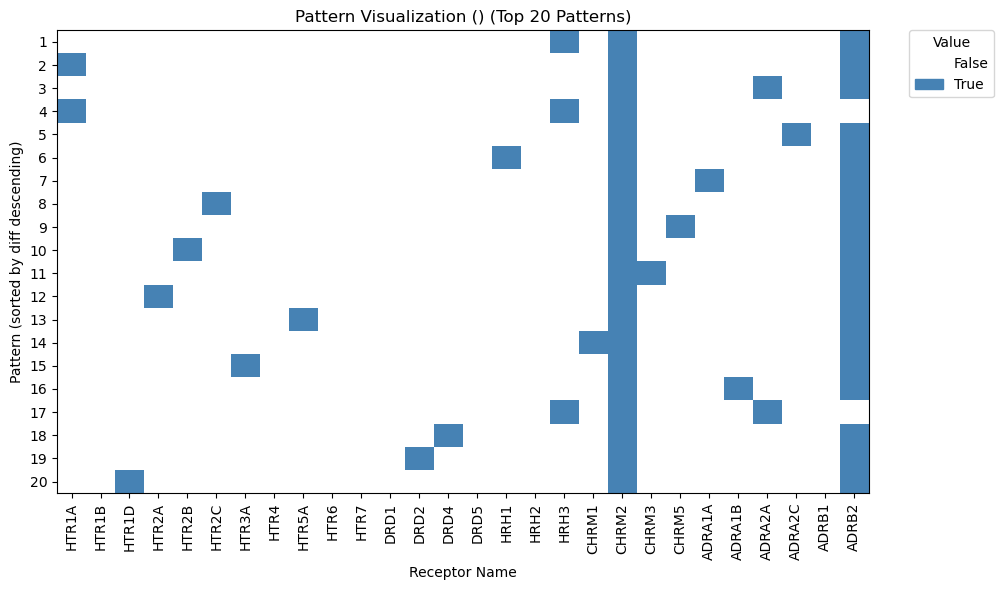

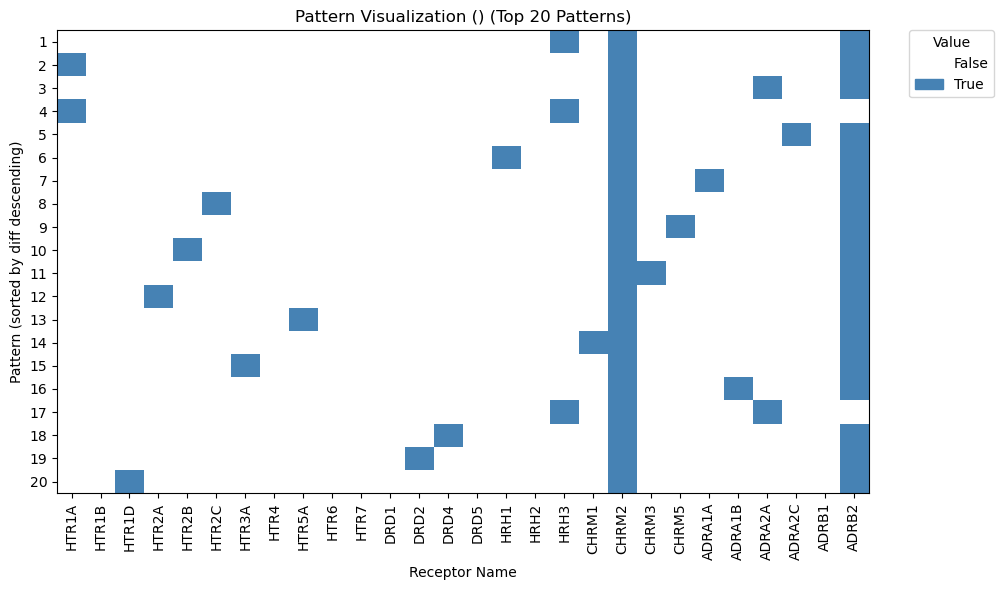

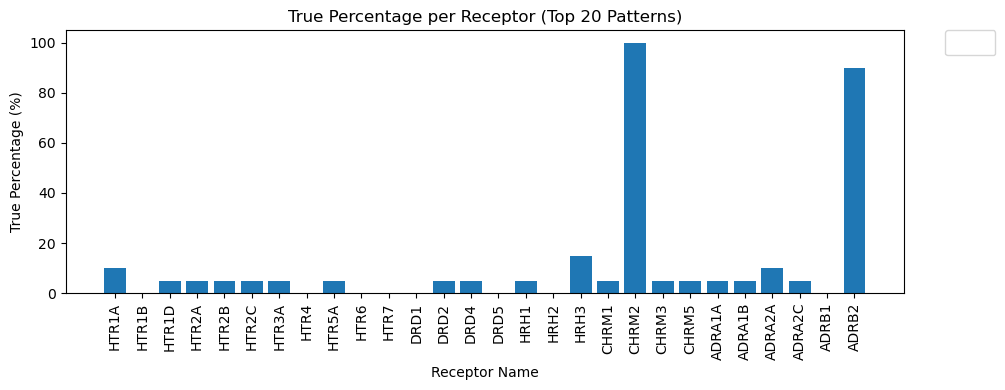

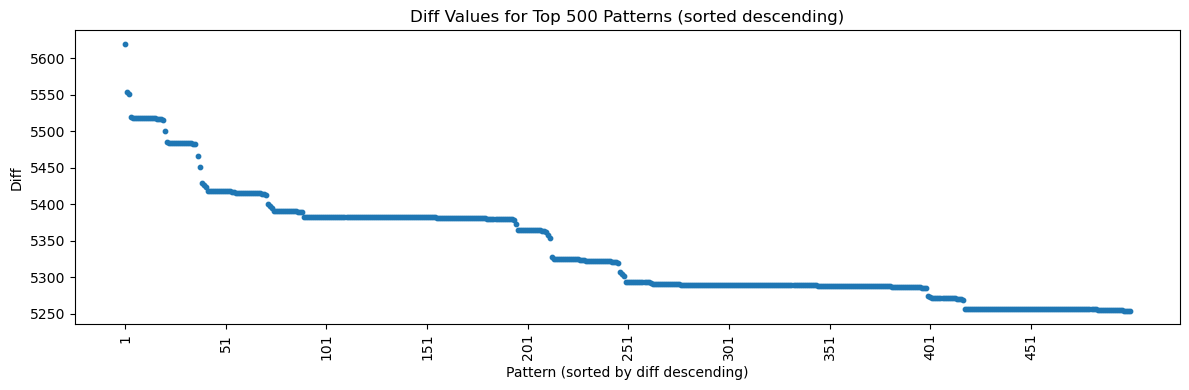

In [11]:
import calculation_tool as ct

drug_conc=10**3
results_df_sorted,all_responses=ct.sim_inhibit_pattern_3r(adata,GPCR_adata_norm_df,GPCR_type_df,drug_conc)
dir="/data/mouse_PFC/WT_only"
results_df_sorted.to_csv(os.path.join(dir,"results_df_sorted_3r.csv"))
all_responses.to_csv(os.path.join(dir,"all_responses_3r.csv"))
ct.visualize_patterns(results_df_sorted, top_n=20, top_n_for_heatmap=20, scatter_n=500)

In [ ]:
ct.visualize_patterns(results_df_sorted, top_n=40, top_n_for_heatmap=40, scatter_n=500)

category
is_clz_selective
False    15552
True       207
Name: count, dtype: int64


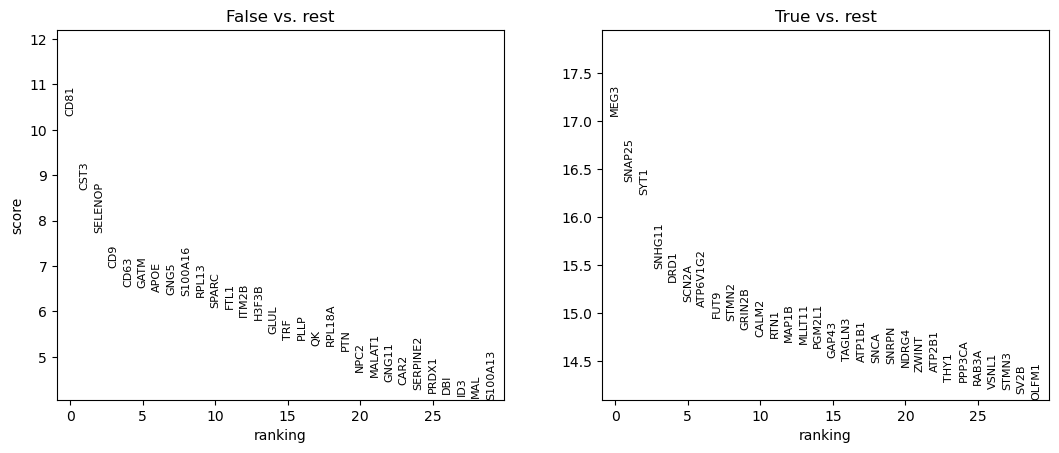

In [14]:
# is_clz_selective をカテゴリ型に変換
adata.obs["is_clz_selective"] = adata.obs["is_clz_selective"].astype("category")

# 念のため確認
print(adata.obs["is_clz_selective"].dtype)
print(adata.obs["is_clz_selective"].value_counts())

# その後で rank_genes_groups
sc.tl.rank_genes_groups(adata, 'is_clz_selective', method='wilcoxon',layer="lognorm",
    use_raw=False,
    pts=True)
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False)
df_deg = sc.get.rank_genes_groups_df(adata, group=None)
df_sig = df_deg[df_deg["pvals_adj"] < 0.05]
df_sig.to_csv("/data/mouse_PFC/WT_only/significant_DEG_is_clz_selective.csv", index=False)


In [15]:
def plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.05,
    log2fc_cutoff=0.25,
    top_n_labels=20,
    output_pdf=None,
    title=None,
    figsize=(7, 6),
):
    """
    Scanpy sc.get.rank_genes_groups_df() の結果から volcano plot を作成する関数。

    Parameters
    ----------
    df_deg : pandas.DataFrame
        sc.get.rank_genes_groups_df(adata, group=None) の出力
    group : bool or str
        プロットする group。例: True, False, "True", "False"
    adj_p_cutoff : float
        adjusted p-value のカットオフ
    log2fc_cutoff : float
        absolute log2 fold change のカットオフ
    top_n_labels : int
        ラベル表示する有意遺伝子数
    output_pdf : str or None
        PDF保存先。Noneなら保存しない
    title : str or None
        プロットタイトル
    figsize : tuple
        図のサイズ
    """

    df = df_deg.copy()

    # groupで絞り込み
    if "group" in df.columns:
        df["group"] = df["group"].astype(str)
        df = df[df["group"] == str(group)].copy()

    if df.empty:
        raise ValueError(f"No rows found for group={group}")

    # logfoldchangesをlog2foldchangeとして扱う
    if "logfoldchanges" in df.columns:
        df["log2foldchange"] = df["logfoldchanges"]
    elif "log2foldchange" not in df.columns:
        raise ValueError("df_deg must contain 'logfoldchanges' or 'log2foldchange'.")

    # adjusted p-value列
    if "pvals_adj" in df.columns:
        p_col = "pvals_adj"
    elif "adj_p_val" in df.columns:
        p_col = "adj_p_val"
    else:
        raise ValueError("df_deg must contain 'pvals_adj' or 'adj_p_val'.")

    # p=0対策
    min_positive_p = df.loc[df[p_col] > 0, p_col].min()
    if pd.isna(min_positive_p):
        min_positive_p = 1e-300

    df[p_col] = df[p_col].replace(0, min_positive_p)
    df["minus_log10_adj_p"] = -np.log10(df[p_col])

    # 有意判定
    df["significant"] = (
        (df[p_col] < adj_p_cutoff)
        & (df["log2foldchange"].abs() >= log2fc_cutoff)
    )

    df["direction"] = "Not significant"
    df.loc[
        df["significant"] & (df["log2foldchange"] > 0),
        "direction"
    ] = "Up"

    df.loc[
        df["significant"] & (df["log2foldchange"] < 0),
        "direction"
    ] = "Down"

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        df.loc[df["direction"] == "Not significant", "log2foldchange"],
        df.loc[df["direction"] == "Not significant", "minus_log10_adj_p"],
        s=8,
        alpha=0.4,
        color="lightgray",
        label="Not significant",
    )

    ax.scatter(
        df.loc[df["direction"] == "Up", "log2foldchange"],
        df.loc[df["direction"] == "Up", "minus_log10_adj_p"],
        s=12,
        alpha=0.8,
        color="crimson",
        label="Up",
    )

    ax.scatter(
        df.loc[df["direction"] == "Down", "log2foldchange"],
        df.loc[df["direction"] == "Down", "minus_log10_adj_p"],
        s=12,
        alpha=0.8,
        color="royalblue",
        label="Down",
    )

    # cutoff lines
    ax.axhline(
        -np.log10(adj_p_cutoff),
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )
    ax.axvline(
        -log2fc_cutoff,
        linestyle="--",
        linewidth=1,
        color="black",
    )

    # gene labels
    if "names" in df.columns and top_n_labels > 0:
        label_df = (
            df[df["significant"]]
            .sort_values(p_col)
            .head(top_n_labels)
        )

        for _, row in label_df.iterrows():
            ax.text(
                row["log2foldchange"],
                row["minus_log10_adj_p"],
                row["names"],
                fontsize=8,
                ha="center",
                va="bottom",
            )

    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")

    if title is None:
        title = f"Volcano plot: group={group}"

    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if output_pdf is not None:
        plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
        print(f"Saved: {output_pdf}")

    plt.show()

    print("Total genes:", len(df))
    print("Significant genes:", df["significant"].sum())
    print("Up:", (df["direction"] == "Up").sum())
    print("Down:", (df["direction"] == "Down").sum())

    return df

Saved: /data/mouse_PFC/WT_only/volcano_is_clz_selective_groupTrue.pdf


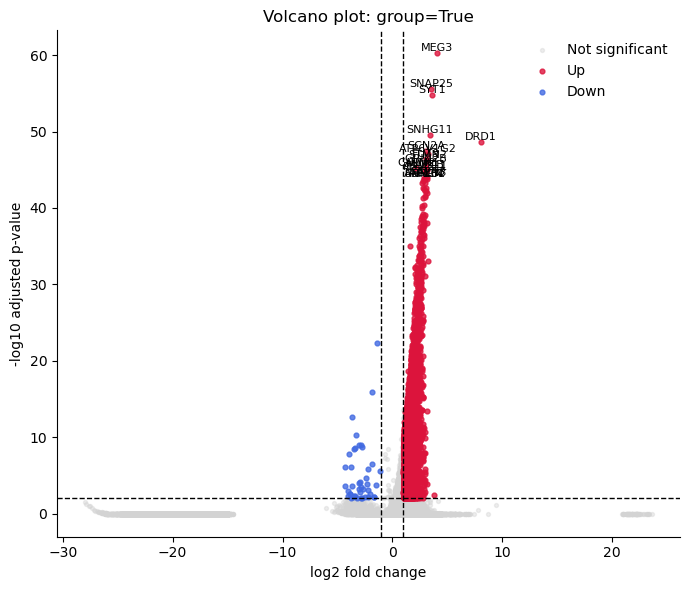

Total genes: 20789
Significant genes: 3323
Up: 3280
Down: 43


In [16]:
volcano_df = plot_volcano_from_deg(
    df_deg,
    group=True,
    adj_p_cutoff=0.01,
    log2fc_cutoff=1,
    top_n_labels=20,
    output_pdf="/data/mouse_PFC/WT_only/volcano_is_clz_selective_groupTrue.pdf",
)

In [ ]:
drug_conc=10**3
adata=ct.calc_drug_response(adata,GPCR_df,GPCR_type_df,drug_list,D_R_mtx,drug_conc)
selectivity_threshold=1.5
adata,num_clz_selective=ct.calc_clz_selective_cell(adata,drug_list,selectivity_threshold)

Group counts:
_clz_group
FALSE    15552
TRUE       207
Name: count, dtype: int64
adata.layers['lognorm'] already exists.
Found genes: {'5HT1A': 'HTR1A', 'M2': 'CHRM2', 'H3': 'HRH3'}
stats_df:


,gene_label,gene,group_FALSE,group_TRUE,n_FALSE,n_TRUE,mean_FALSE_lognorm,mean_TRUE_lognorm,delta_mean_TRUE_minus_FALSE,median_FALSE_lognorm,...,delta_median_TRUE_minus_FALSE,pct_expr_FALSE,pct_expr_TRUE,delta_pct_TRUE_minus_FALSE,mannwhitneyu_stat,p_value_expression,fisher_odds_ratio_positive,p_value_positive_fraction,q_value_expression_FDR,q_value_positive_fraction_FDR
0,5HT1A,HTR1A,FALSE,TRUE,15552,207,0.010843,0.036399,0.025556,0.0,...,0.0,0.970936,3.864734,2.893798,1656090.5,3.666168e-05,4.100236,1.207205e-03,3.666168e-05,1.207205e-03
1,M2,CHRM2,FALSE,TRUE,15552,207,0.022812,0.126626,0.103814,0.0,...,0.0,1.504630,10.144928,8.640298,1748285.0,1.720809e-22,7.390819,2.191744e-11,5.162428e-22,6.575232e-11
2,H3,HRH3,FALSE,TRUE,15552,207,0.052989,0.108253,0.055264,0.0,...,0.0,3.587963,11.594203,8.006240,1735057.0,3.553386e-09,3.524061,7.136191e-07,5.330079e-09,1.070429e-06


summary_pct:


,gene_label,gene,group,pct_expressing,mean_lognorm_expression,median_lognorm_expression,n_cells
0,5HT1A,HTR1A,FALSE,0.970936,0.010843,0.0,15552
1,5HT1A,HTR1A,TRUE,3.864734,0.036399,0.0,207
2,H3,HRH3,FALSE,3.587963,0.052989,0.0,15552
3,H3,HRH3,TRUE,11.594203,0.108253,0.0,207
4,M2,CHRM2,FALSE,1.504630,0.022812,0.0,15552
5,M2,CHRM2,TRUE,10.144928,0.126626,0.0,207


saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/receptor_lognorm_expression_violin_TRUE_vs_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/receptor_mean_lognorm_expression_TRUE_vs_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/receptor_positive_fraction_TRUE_vs_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/receptor_delta_mean_expression_TRUE_minus_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/scanpy_dotplot_receptors_TRUE_vs_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis/scanpy_violin_receptors_TRUE_vs_FALSE.pdf
Done.
All outputs saved to: /data/mouse_PFC/WT_only/clz_receptor_expression_analysis


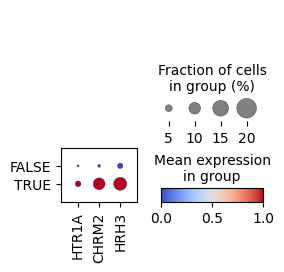

In [17]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests

# =========================
# settings
# =========================
OUTDIR = "/data/mouse_PFC/WT_only/clz_receptor_expression_analysis"
# OUTDIRが既に定義されていればそれを使う
try:
    OUTDIR
except NameError:
    OUTDIR = "/data/mouse_PFC/WT_only/clz_receptor_expression_analysis"

os.makedirs(OUTDIR, exist_ok=True)

GROUPBY = "is_clz_selective"
LAYER = "lognorm"
RAW_LAYER = "raw_counts"

# Illustrator編集用PDF設定
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12

gene_aliases = {
    "5HT1A": ["Htr1a", "HTR1A"],
    "M2":    ["Chrm2", "CHRM2"],
    "H3":    ["Hrh3", "HRH3"],
}

# 比較順
GROUP_ORDER = ["FALSE", "TRUE"]
GROUP_LABELS = {
    "FALSE": "Non-responsive",
    "TRUE": "Clozapine-responsive",
}


# =========================
# helper functions
# =========================

def save_pdf(fig, filename):
    path = os.path.join(OUTDIR, filename)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("saved:", path)


def ensure_clz_group(adata, groupby=GROUPBY):
    """
    TRUE/FALSEを安定して扱うための列を作る。
    """
    adata.obs["_clz_group"] = (
        adata.obs[groupby]
        .astype(str)
        .str.upper()
        .replace({
            "1": "TRUE",
            "0": "FALSE",
            "TRUE": "TRUE",
            "FALSE": "FALSE",
            "True": "TRUE",
            "False": "FALSE",
        })
        .astype("category")
    )

    print("Group counts:")
    print(adata.obs["_clz_group"].value_counts())

    valid = adata.obs["_clz_group"].isin(["TRUE", "FALSE"])
    return valid


def ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER):
    """
    lognorm layerがなければraw_countsから作成。
    """
    if layer in adata.layers:
        print(f"adata.layers['{layer}'] already exists.")
        return

    if raw_layer not in adata.layers:
        raise ValueError(
            f"adata.layers['{layer}'] not found, and "
            f"adata.layers['{raw_layer}'] is also missing."
        )

    print(f"Creating adata.layers['{layer}'] from adata.layers['{raw_layer}']...")

    adata.layers[layer] = adata.layers[raw_layer].copy()

    sc.pp.normalize_total(
        adata,
        target_sum=1e4,
        layer=layer
    )
    sc.pp.log1p(
        adata,
        layer=layer
    )

    adata.layers[layer] = adata.layers[layer].astype("float32")
    print("done.")


def resolve_gene_aliases(adata, gene_aliases):
    """
    mouse/human両対応。
    adata.var_names上の実際のgene名を探す。
    大文字小文字の違いも吸収する。
    """
    var_map = {str(g).upper(): str(g) for g in adata.var_names}

    found_genes = {}
    missing = {}

    for label, aliases in gene_aliases.items():
        hit = None

        for g in aliases:
            gu = str(g).upper()
            if gu in var_map:
                hit = var_map[gu]
                break

        if hit is None:
            missing[label] = aliases
            print(f"Warning: {label} not found. tried: {aliases}")
        else:
            found_genes[label] = hit

    print("Found genes:", found_genes)

    if len(found_genes) == 0:
        raise ValueError("No target genes were found in adata.var_names.")

    return found_genes, missing


def get_expr_vector(adata, gene, layer):
    """
    指定layerからgene expression vectorを取得。
    """
    idx = adata.var_names.get_loc(gene)
    x = adata.layers[layer][:, idx]

    if sparse.issparse(x):
        x = x.toarray()

    return np.asarray(x).ravel()


def add_gene_vectors_to_obs(adata, found_genes, layer=LAYER, raw_layer=RAW_LAYER):
    """
    lognorm expressionとraw positiveをobsに追加。
    """
    for label, gene in found_genes.items():
        expr = get_expr_vector(adata, gene, layer=layer)
        adata.obs[f"{label}_gene"] = gene
        adata.obs[f"{label}_lognorm"] = expr

        if raw_layer in adata.layers:
            raw = get_expr_vector(adata, gene, layer=raw_layer)
            adata.obs[f"{label}_raw"] = raw
            adata.obs[f"{label}_positive"] = raw > 0
        else:
            adata.obs[f"{label}_positive"] = expr > 0

    return adata


def build_long_expression_df(adata, found_genes, valid_mask):
    records = []

    for label, gene in found_genes.items():
        tmp = pd.DataFrame({
            "cell": adata.obs_names[valid_mask],
            "group": adata.obs.loc[valid_mask, "_clz_group"].astype(str).values,
            "gene_label": label,
            "gene": gene,
            "lognorm_expression": adata.obs.loc[valid_mask, f"{label}_lognorm"].values,
            "expressed": adata.obs.loc[valid_mask, f"{label}_positive"].values,
        })

        if f"{label}_raw" in adata.obs.columns:
            tmp["raw_counts"] = adata.obs.loc[valid_mask, f"{label}_raw"].values

        records.append(tmp)

    return pd.concat(records, axis=0, ignore_index=True)


def compute_stats(df_expr):
    stats = []

    groups = [g for g in GROUP_ORDER if g in df_expr["group"].unique()]
    if len(groups) != 2:
        raise ValueError(f"Expected 2 groups, got: {groups}")

    g_false, g_true = groups[0], groups[1]

    for label in df_expr["gene_label"].unique():
        d = df_expr[df_expr["gene_label"] == label].copy()

        x_false = d.loc[d["group"] == g_false, "lognorm_expression"].values
        x_true = d.loc[d["group"] == g_true, "lognorm_expression"].values

        u, p_expr = mannwhitneyu(
            x_true,
            x_false,
            alternative="two-sided"
        )

        pos_false = d.loc[d["group"] == g_false, "expressed"].values.astype(bool)
        pos_true = d.loc[d["group"] == g_true, "expressed"].values.astype(bool)

        table = [
            [pos_true.sum(), len(pos_true) - pos_true.sum()],
            [pos_false.sum(), len(pos_false) - pos_false.sum()],
        ]

        odds, p_pos = fisher_exact(table)

        stats.append({
            "gene_label": label,
            "gene": d["gene"].iloc[0],

            "group_FALSE": g_false,
            "group_TRUE": g_true,

            "n_FALSE": len(x_false),
            "n_TRUE": len(x_true),

            "mean_FALSE_lognorm": np.mean(x_false),
            "mean_TRUE_lognorm": np.mean(x_true),
            "delta_mean_TRUE_minus_FALSE": np.mean(x_true) - np.mean(x_false),

            "median_FALSE_lognorm": np.median(x_false),
            "median_TRUE_lognorm": np.median(x_true),
            "delta_median_TRUE_minus_FALSE": np.median(x_true) - np.median(x_false),

            "pct_expr_FALSE": np.mean(pos_false) * 100,
            "pct_expr_TRUE": np.mean(pos_true) * 100,
            "delta_pct_TRUE_minus_FALSE": (np.mean(pos_true) - np.mean(pos_false)) * 100,

            "mannwhitneyu_stat": u,
            "p_value_expression": p_expr,

            "fisher_odds_ratio_positive": odds,
            "p_value_positive_fraction": p_pos,
        })

    stats_df = pd.DataFrame(stats)

    stats_df["q_value_expression_FDR"] = multipletests(
        stats_df["p_value_expression"],
        method="fdr_bh"
    )[1]

    stats_df["q_value_positive_fraction_FDR"] = multipletests(
        stats_df["p_value_positive_fraction"],
        method="fdr_bh"
    )[1]

    return stats_df


# =========================
# plotting functions
# =========================

def plot_lognorm_violin(df_expr, stats_df):
    genes = list(df_expr["gene_label"].unique())
    n_genes = len(genes)

    fig, ax = plt.subplots(figsize=(max(5.5, 1.4 * n_genes), 4.5))

    positions = []
    data = []
    xticks = []

    width_offset = 0.18

    for i, label in enumerate(genes):
        for j, group in enumerate(GROUP_ORDER):
            vals = df_expr.loc[
                (df_expr["gene_label"] == label) &
                (df_expr["group"] == group),
                "lognorm_expression"
            ].values

            pos = i + (-width_offset if group == "FALSE" else width_offset)
            positions.append(pos)
            data.append(vals)

        xticks.append(i)

    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.28,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    # jitter points
    rng = np.random.default_rng(0)
    for pos, vals in zip(positions, data):
        if len(vals) > 3000:
            vals_plot = rng.choice(vals, size=3000, replace=False)
        else:
            vals_plot = vals

        jitter = rng.normal(loc=pos, scale=0.025, size=len(vals_plot))
        ax.scatter(
            jitter,
            vals_plot,
            s=4,
            alpha=0.25,
            linewidths=0,
        )

    ax.set_xticks(xticks)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Expression\nlog-normalized")
    ax.set_xlabel("")
    ax.set_title("Receptor mRNA expression")

    # 凡例用ダミー
    ax.scatter([], [], label="Non-responsive", alpha=0.7)
    ax.scatter([], [], label="Clozapine-responsive", alpha=0.7)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))

    # p値アノテーション
    y_max = df_expr["lognorm_expression"].max()
    y_text = y_max * 1.05 if y_max > 0 else 0.1

    for i, label in enumerate(genes):
        row = stats_df[stats_df["gene_label"] == label].iloc[0]
        ax.text(
            i,
            y_text,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_lognorm_expression_violin_TRUE_vs_FALSE.pdf")


def plot_mean_expression_bar(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x - width / 2,
        stats_df["mean_FALSE_lognorm"],
        width,
        label="Non-responsive",
    )
    ax.bar(
        x + width / 2,
        stats_df["mean_TRUE_lognorm"],
        width,
        label="Clozapine-responsive",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Mean expression\nlog-normalized")
    ax.set_xlabel("")
    ax.set_title("Mean receptor expression")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    for i, row in stats_df.iterrows():
        ymax = max(row["mean_FALSE_lognorm"], row["mean_TRUE_lognorm"])
        ax.text(
            i,
            ymax * 1.05 if ymax > 0 else 0.05,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_mean_lognorm_expression_TRUE_vs_FALSE.pdf")


def plot_positive_fraction_bar(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x - width / 2,
        stats_df["pct_expr_FALSE"],
        width,
        label="Non-responsive",
    )
    ax.bar(
        x + width / 2,
        stats_df["pct_expr_TRUE"],
        width,
        label="Clozapine-responsive",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("% expressing cells\nraw count > 0")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.set_title("Fraction of receptor-expressing cells")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    for i, row in stats_df.iterrows():
        ymax = max(row["pct_expr_FALSE"], row["pct_expr_TRUE"])
        ax.text(
            i,
            min(ymax + 4, 98),
            f"q={row['q_value_positive_fraction_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_positive_fraction_TRUE_vs_FALSE.pdf")


def plot_delta_summary(stats_df):
    genes = stats_df["gene_label"].tolist()
    x = np.arange(len(genes))

    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(genes)), 4))

    ax.bar(
        x,
        stats_df["delta_mean_TRUE_minus_FALSE"],
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(genes)
    ax.set_ylabel("Delta mean expression\nTRUE - FALSE")
    ax.set_title("Expression enrichment in clozapine-responsive cells")

    for i, row in stats_df.iterrows():
        y = row["delta_mean_TRUE_minus_FALSE"]
        ax.text(
            i,
            y,
            f"q={row['q_value_expression_FDR']:.1e}",
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=9,
        )

    save_pdf(fig, "receptor_delta_mean_expression_TRUE_minus_FALSE.pdf")


def plot_scanpy_dotplot(adata, genes_for_plot):
    """
    Scanpy dotplotもPDF保存。
    """
    dp = sc.pl.dotplot(
        adata,
        var_names=genes_for_plot,
        groupby="_clz_group",
        layer=LAYER,
        use_raw=False,
        standard_scale="var",
        color_map="coolwarm",
        return_fig=True,
        show=False,
    )

    path = os.path.join(OUTDIR, "scanpy_dotplot_receptors_TRUE_vs_FALSE.pdf")
    dp.savefig(path)
    print("saved:", path)


def plot_scanpy_violin(adata, genes_for_plot):
    """
    Scanpy violinもPDF保存。
    """
    sc.pl.violin(
        adata,
        keys=genes_for_plot,
        groupby="_clz_group",
        layer=LAYER,
        use_raw=False,
        stripplot=False,
        jitter=False,
        rotation=45,
        show=False,
    )

    path = os.path.join(OUTDIR, "scanpy_violin_receptors_TRUE_vs_FALSE.pdf")
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print("saved:", path)


# =========================
# main
# =========================

valid_mask = ensure_clz_group(adata, GROUPBY)
ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER)

found_genes, missing_genes = resolve_gene_aliases(adata, gene_aliases)

adata = add_gene_vectors_to_obs(
    adata,
    found_genes,
    layer=LAYER,
    raw_layer=RAW_LAYER,
)

df_expr = build_long_expression_df(
    adata,
    found_genes,
    valid_mask=valid_mask,
)

df_expr = df_expr[df_expr["group"].isin(GROUP_ORDER)].copy()
df_expr["group"] = pd.Categorical(
    df_expr["group"],
    categories=GROUP_ORDER,
    ordered=True,
)

stats_df = compute_stats(df_expr)

# =========================
# save tables
# =========================

df_expr.to_csv(
    os.path.join(OUTDIR, "receptor_expression_long_format.csv"),
    index=False,
)

stats_df.to_csv(
    os.path.join(OUTDIR, "receptor_expression_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

summary_pct = (
    df_expr
    .groupby(["gene_label", "gene", "group"], observed=True)
    .agg(
        pct_expressing=("expressed", lambda x: np.mean(x) * 100),
        mean_lognorm_expression=("lognorm_expression", "mean"),
        median_lognorm_expression=("lognorm_expression", "median"),
        n_cells=("lognorm_expression", "size"),
    )
    .reset_index()
)

summary_pct.to_csv(
    os.path.join(OUTDIR, "receptor_expression_summary_by_group.csv"),
    index=False,
)

print("stats_df:")
display(stats_df)

print("summary_pct:")
display(summary_pct)

# =========================
# save figures as Illustrator-editable PDF
# =========================

genes_for_plot = list(found_genes.values())

plot_lognorm_violin(df_expr, stats_df)
plot_mean_expression_bar(stats_df)
plot_positive_fraction_bar(stats_df)
plot_delta_summary(stats_df)

plot_scanpy_dotplot(adata[valid_mask].copy(), genes_for_plot)
plot_scanpy_violin(adata[valid_mask].copy(), genes_for_plot)

print("Done.")
print("All outputs saved to:", OUTDIR)

In [22]:
from itertools import combinations
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# =========================
# settings
# =========================

# 前半コードで定義済みならそれを使う
OUTDIR = "/data/mouse_mPFC/WT_only/clz_receptor_expression_analysis"
try:
    OUTDIR
except NameError:
    OUTDIR = "/data/mouse_mPFC/WT_only/clz_receptor_expression_analysis"

os.makedirs(OUTDIR, exist_ok=True)

try:
    GROUPBY
except NameError:
    GROUPBY = "is_clz_selective"

try:
    GROUP_ORDER
except NameError:
    GROUP_ORDER = ["FALSE", "TRUE"]

try:
    GROUP_LABELS
except NameError:
    GROUP_LABELS = {
        "FALSE": "Non-responsive",
        "TRUE": "Clozapine-responsive",
    }

# Illustrator編集用PDF設定
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12


# =========================
# helper
# =========================

def save_pdf(fig, filename):
    path = os.path.join(OUTDIR, filename)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("saved:", path)


def add_percent_labels(ax, bars, fmt="{:.1f}", y_offset=1.5):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + y_offset,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=9,
        )


# =========================
# 9. receptor positive matrixを作成
# =========================
# df_expr columns:
# cell, group, gene_label, gene, lognorm_expression, expressed, raw_counts(optional)

required_cols = {"cell", "group", "gene_label", "expressed"}
missing_cols = required_cols - set(df_expr.columns)
if missing_cols:
    raise ValueError(f"df_expr is missing columns: {missing_cols}")

df_pos = (
    df_expr
    .pivot_table(
        index=["cell", "group"],
        columns="gene_label",
        values="expressed",
        aggfunc="first"
    )
    .reset_index()
)

# found_genesがある場合はその順序を使う
try:
    gene_labels = list(found_genes.keys())
except NameError:
    gene_labels = [
        c for c in df_pos.columns
        if c not in ["cell", "group"]
    ]

# boolean化
for g in gene_labels:
    if g not in df_pos.columns:
        df_pos[g] = False
    df_pos[g] = df_pos[g].fillna(False).astype(bool)

# group order整理
df_pos = df_pos[df_pos["group"].isin(GROUP_ORDER)].copy()
df_pos["group"] = pd.Categorical(
    df_pos["group"],
    categories=GROUP_ORDER,
    ordered=True
)

print(df_pos.head())


# =========================
# 10. double positive / triple positiveを定義
# =========================

combo_cols = []

# double positive
for g1, g2 in combinations(gene_labels, 2):
    col = f"{g1}+{g2}"
    df_pos[col] = df_pos[g1] & df_pos[g2]
    combo_cols.append(col)

# triple or higher positive
if len(gene_labels) >= 3:
    all_col = "+".join(gene_labels)
    df_pos[all_col] = df_pos[gene_labels].all(axis=1)
    combo_cols.append(all_col)

if len(combo_cols) == 0:
    raise ValueError("Need at least 2 genes to compute double-positive combinations.")

df_pos.to_csv(
    os.path.join(OUTDIR, "receptor_positive_matrix_per_cell.csv"),
    index=False,
)

print(df_pos[["cell", "group"] + gene_labels + combo_cols].head())


# =========================
# 11. 群ごとのdouble/triple positive率
# =========================

summary_combo_long = []

for group_name, d in df_pos.groupby("group", observed=True):
    for col in combo_cols:
        summary_combo_long.append({
            "group": str(group_name),
            "group_label": GROUP_LABELS.get(str(group_name), str(group_name)),
            "combination": col,
            "fraction": d[col].mean(),
            "percent": d[col].mean() * 100,
            "n_cells": len(d),
            "n_positive": int(d[col].sum()),
        })

summary_combo_long = pd.DataFrame(summary_combo_long)

summary_combo_long.to_csv(
    os.path.join(OUTDIR, "receptor_combo_positive_fraction_by_group.csv"),
    index=False,
)

print(summary_combo_long)


# =========================
# 12. Fisher's exact testで2群比較
# =========================

available_groups = [g for g in GROUP_ORDER if g in df_pos["group"].astype(str).unique()]

if len(available_groups) != 2:
    raise ValueError(f"group should have exactly 2 groups, but got: {available_groups}")

g_false, g_true = available_groups[0], available_groups[1]

stats_combo = []

for col in combo_cols:
    x_false = df_pos.loc[df_pos["group"].astype(str) == g_false, col].astype(bool)
    x_true = df_pos.loc[df_pos["group"].astype(str) == g_true, col].astype(bool)

    # contingency table
    #          positive  negative
    # TRUE
    # FALSE
    table = np.array([
        [x_true.sum(),  (~x_true).sum()],
        [x_false.sum(), (~x_false).sum()],
    ])

    oddsratio, p = fisher_exact(table, alternative="two-sided")

    stats_combo.append({
        "combination": col,

        "group_FALSE": g_false,
        "group_TRUE": g_true,

        "n_FALSE": len(x_false),
        "n_TRUE": len(x_true),

        "positive_FALSE": int(x_false.sum()),
        "positive_TRUE": int(x_true.sum()),

        "percent_FALSE": x_false.mean() * 100,
        "percent_TRUE": x_true.mean() * 100,
        "delta_percent_TRUE_minus_FALSE": (x_true.mean() - x_false.mean()) * 100,

        "odds_ratio_TRUE_enrichment": oddsratio,
        "p_value": p,
    })

stats_combo_df = pd.DataFrame(stats_combo)

stats_combo_df["q_value_FDR"] = multipletests(
    stats_combo_df["p_value"],
    method="fdr_bh"
)[1]

stats_combo_df = stats_combo_df.sort_values(
    ["q_value_FDR", "delta_percent_TRUE_minus_FALSE"],
    ascending=[True, False]
)

stats_combo_df.to_csv(
    os.path.join(OUTDIR, "receptor_combo_positive_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

print(stats_combo_df)


# =========================
# 13. 可視化1：double/triple positive細胞率
# =========================

def plot_combo_positive_fraction(summary_combo_long, stats_combo_df):
    combos = combo_cols
    x = np.arange(len(combos))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(6, 1.4 * len(combos)), 4.5))

    false_vals = []
    true_vals = []

    for combo in combos:
        d_false = summary_combo_long[
            (summary_combo_long["combination"] == combo) &
            (summary_combo_long["group"] == g_false)
        ]
        d_true = summary_combo_long[
            (summary_combo_long["combination"] == combo) &
            (summary_combo_long["group"] == g_true)
        ]

        false_vals.append(float(d_false["percent"].iloc[0]) if len(d_false) else 0)
        true_vals.append(float(d_true["percent"].iloc[0]) if len(d_true) else 0)

    bars_false = ax.bar(
        x - width / 2,
        false_vals,
        width,
        label=GROUP_LABELS.get(g_false, g_false),
    )

    bars_true = ax.bar(
        x + width / 2,
        true_vals,
        width,
        label=GROUP_LABELS.get(g_true, g_true),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(combos, rotation=45, ha="right")
    ax.set_ylabel("% positive cells\nraw count > 0")
    ax.set_xlabel("")
    ax.set_ylim(0, max(max(false_vals), max(true_vals)) * 1.35 + 1)
    ax.set_title("Double-/triple-positive receptor-expressing cells")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

    # q値 annotation
    for i, combo in enumerate(combos):
        row = stats_combo_df[stats_combo_df["combination"] == combo]
        if len(row) == 0:
            continue

        q = row["q_value_FDR"].iloc[0]
        ymax = max(false_vals[i], true_vals[i])

        ax.text(
            i,
            ymax + max(max(false_vals), max(true_vals)) * 0.06 + 0.5,
            f"q={q:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    save_pdf(fig, "receptor_combo_positive_fraction_TRUE_vs_FALSE.pdf")


plot_combo_positive_fraction(summary_combo_long, stats_combo_df)


# =========================
# 14. 可視化2：TRUE - FALSE の差分
# =========================

def plot_combo_delta(stats_combo_df):
    d = stats_combo_df.copy()
    d = d.sort_values("delta_percent_TRUE_minus_FALSE", ascending=False)

    fig, ax = plt.subplots(figsize=(max(6, 1.3 * len(d)), 4.2))

    x = np.arange(len(d))

    bars = ax.bar(
        x,
        d["delta_percent_TRUE_minus_FALSE"].values,
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(d["combination"], rotation=45, ha="right")
    ax.set_ylabel("Delta % positive cells\nTRUE - FALSE")
    ax.set_title("Enrichment of receptor co-expression\nin clozapine-responsive cells")

    for i, row in enumerate(d.itertuples()):
        y = row.delta_percent_TRUE_minus_FALSE
        ax.text(
            i,
            y,
            f"q={row.q_value_FDR:.1e}",
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=9,
        )

    save_pdf(fig, "receptor_combo_delta_percent_TRUE_minus_FALSE.pdf")


plot_combo_delta(stats_combo_df)


# =========================
# 15. 可視化3：Odds ratio
# =========================
def plot_combo_odds_ratio(stats_combo_df):
    d = stats_combo_df.copy()
    d = d.replace([np.inf, -np.inf], np.nan)

    # odds ratioの表示用カラムを作る
    finite_or = d["odds_ratio_TRUE_enrichment"].replace([np.inf, -np.inf], np.nan)
    finite_max = finite_or.max()

    if pd.isna(finite_max) or finite_max <= 0:
        finite_max = 10

    d["plot_odds_ratio"] = d["odds_ratio_TRUE_enrichment"].copy()
    d["plot_odds_ratio"] = d["plot_odds_ratio"].replace(np.inf, finite_max * 1.5)
    d["plot_odds_ratio"] = d["plot_odds_ratio"].replace(-np.inf, 0)
    d["plot_odds_ratio"] = d["plot_odds_ratio"].fillna(0)

    d = d.sort_values("plot_odds_ratio", ascending=False)

    fig, ax = plt.subplots(figsize=(max(6, 1.3 * len(d)), 4.2))

    x = np.arange(len(d))

    ax.bar(
        x,
        d["plot_odds_ratio"].values,
    )

    ax.axhline(1, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(d["combination"], rotation=45, ha="right")
    ax.set_ylabel("Odds ratio\nTRUE enrichment")
    ax.set_title("Co-expression enrichment odds ratio")

    ymax = d["plot_odds_ratio"].max()
    offset = ymax * 0.04 if ymax > 0 else 0.2

    # itertuplesではなくiterrowsを使う
    for i, (_, row) in enumerate(d.iterrows()):
        ax.text(
            i,
            row["plot_odds_ratio"] + offset,
            f"q={row['q_value_FDR']:.1e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_ylim(0, ymax + offset * 4)

    save_pdf(fig, "receptor_combo_odds_ratio_TRUE_enrichment.pdf")


plot_combo_odds_ratio(stats_combo_df)


# =========================
# 16. 可視化4：co-expression pattern composition
# =========================
# 各細胞がどの受容体陽性パターンかを分類してTRUE/FALSEで比較

def make_pattern(row, labels):
    pos = [g for g in labels if bool(row[g])]
    if len(pos) == 0:
        return "none"
    return "+".join(pos)

df_pos["receptor_pattern"] = df_pos.apply(
    lambda row: make_pattern(row, gene_labels),
    axis=1
)

pattern_summary = (
    df_pos
    .groupby(["group", "receptor_pattern"], observed=True)
    .size()
    .reset_index(name="n_cells")
)

pattern_summary["percent"] = (
    pattern_summary
    .groupby("group", observed=True)["n_cells"]
    .transform(lambda x: x / x.sum() * 100)
)

pattern_summary.to_csv(
    os.path.join(OUTDIR, "receptor_pattern_composition_by_group.csv"),
    index=False,
)

def plot_pattern_composition(pattern_summary):
    patterns = sorted(
        pattern_summary["receptor_pattern"].unique(),
        key=lambda x: (x.count("+"), x)
    )

    groups = [g for g in GROUP_ORDER if g in pattern_summary["group"].astype(str).unique()]
    x = np.arange(len(groups))

    fig, ax = plt.subplots(figsize=(6.2, 4.5))

    bottom = np.zeros(len(groups))

    for pat in patterns:
        vals = []
        for g in groups:
            d = pattern_summary[
                (pattern_summary["group"].astype(str) == g) &
                (pattern_summary["receptor_pattern"] == pat)
            ]
            vals.append(float(d["percent"].iloc[0]) if len(d) else 0)

        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=pat,
        )
        bottom += np.asarray(vals)

    ax.set_xticks(x)
    ax.set_xticklabels([GROUP_LABELS.get(g, g) for g in groups], rotation=20, ha="right")
    ax.set_ylabel("Composition (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Receptor co-expression pattern composition")
    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Pattern",
    )

    save_pdf(fig, "receptor_pattern_composition_TRUE_vs_FALSE.pdf")


plot_pattern_composition(pattern_summary)


# =========================
# 17. optional: patternごとのFisher test
# =========================

stats_pattern = []

for pat in sorted(df_pos["receptor_pattern"].unique()):
    in_pat = df_pos["receptor_pattern"] == pat
    is_true = df_pos["group"].astype(str) == g_true
    is_false = df_pos["group"].astype(str) == g_false

    x_true = in_pat & is_true
    x_false = in_pat & is_false

    table = np.array([
        [x_true.sum(),  is_true.sum() - x_true.sum()],
        [x_false.sum(), is_false.sum() - x_false.sum()],
    ])

    odds, p = fisher_exact(table, alternative="two-sided")

    stats_pattern.append({
        "pattern": pat,
        "n_TRUE": int(is_true.sum()),
        "n_FALSE": int(is_false.sum()),
        "positive_TRUE": int(x_true.sum()),
        "positive_FALSE": int(x_false.sum()),
        "percent_TRUE": x_true.sum() / is_true.sum() * 100 if is_true.sum() > 0 else np.nan,
        "percent_FALSE": x_false.sum() / is_false.sum() * 100 if is_false.sum() > 0 else np.nan,
        "delta_percent_TRUE_minus_FALSE": (
            x_true.sum() / is_true.sum() - x_false.sum() / is_false.sum()
        ) * 100 if is_true.sum() > 0 and is_false.sum() > 0 else np.nan,
        "odds_ratio_TRUE_enrichment": odds,
        "p_value": p,
    })

stats_pattern_df = pd.DataFrame(stats_pattern)

stats_pattern_df["q_value_FDR"] = multipletests(
    stats_pattern_df["p_value"],
    method="fdr_bh"
)[1]

stats_pattern_df = stats_pattern_df.sort_values(
    ["q_value_FDR", "delta_percent_TRUE_minus_FALSE"],
    ascending=[True, False]
)

stats_pattern_df.to_csv(
    os.path.join(OUTDIR, "receptor_pattern_TRUE_vs_FALSE_stats.csv"),
    index=False,
)

print("stats_pattern_df:")
print(stats_pattern_df)

print("Done.")
print("All combo outputs saved to:", OUTDIR)

gene_label                  cell  group  5HT1A     H3     M2
0           AAACCTGAGAATGTGT-1-1  FALSE  False  False  False
1           AAACCTGAGATCCCGC-1-0  FALSE  False  False  False
2           AAACCTGAGCTAAGAT-1-0  FALSE  False  False  False
3           AAACCTGAGGATTCGG-1-1  FALSE  False  False  False
4           AAACCTGAGTGTTAGA-1-1  FALSE  False  False  False
gene_label                  cell  group  5HT1A     M2     H3  5HT1A+M2  \
0           AAACCTGAGAATGTGT-1-1  FALSE  False  False  False     False   
1           AAACCTGAGATCCCGC-1-0  FALSE  False  False  False     False   
2           AAACCTGAGCTAAGAT-1-0  FALSE  False  False  False     False   
3           AAACCTGAGGATTCGG-1-1  FALSE  False  False  False     False   
4           AAACCTGAGTGTTAGA-1-1  FALSE  False  False  False     False   

gene_label  5HT1A+H3  M2+H3  5HT1A+M2+H3  
0              False  False        False  
1              False  False        False  
2              False  False        False  
3              Fa

In [20]:
import numpy as np
import pandas as pd
from scipy import sparse

def matrix_basic_stats(x, name="matrix", n_sample=200000):
    """
    Check whether a matrix looks like raw counts.
    Works for dense and sparse matrices.
    """

    # sparseの場合は非ゼロ要素だけを見る
    if sparse.issparse(x):
        data = x.data
        shape = x.shape
        nnz = x.nnz
        total = shape[0] * shape[1]
        zero_fraction = 1 - nnz / total

        if len(data) == 0:
            vals = np.array([0])
        else:
            vals = data

    else:
        shape = x.shape
        arr = np.asarray(x)
        total = arr.size
        nnz = np.count_nonzero(arr)
        zero_fraction = 1 - nnz / total
        vals = arr.ravel()

    # 大きすぎる場合はサンプリング
    if len(vals) > n_sample:
        rng = np.random.default_rng(0)
        vals_sample = rng.choice(vals, size=n_sample, replace=False)
    else:
        vals_sample = vals

    vals_sample = np.asarray(vals_sample)

    min_val = np.min(vals_sample)
    max_val = np.max(vals_sample)
    mean_val = np.mean(vals_sample)
    median_val = np.median(vals_sample)

    # integer-like判定
    integer_like = np.allclose(vals_sample, np.round(vals_sample), atol=1e-8)

    # non-negative判定
    non_negative = min_val >= 0

    # log-normalizedっぽいか
    has_decimal = not integer_like
    has_negative = min_val < 0

    # 小さい値の例
    unique_preview = np.unique(vals_sample[:min(10000, len(vals_sample))])
    unique_preview = unique_preview[:20]

    # raw countっぽさの判定
    if non_negative and integer_like and max_val > 1:
        guess = "likely raw counts"
    elif non_negative and integer_like and max_val <= 1:
        guess = "possibly binary/counts but unusual"
    elif non_negative and has_decimal:
        guess = "likely normalized/log-normalized expression"
    elif has_negative:
        guess = "likely scaled/z-scored data"
    else:
        guess = "unclear"

    return {
        "name": name,
        "shape": shape,
        "min": min_val,
        "max": max_val,
        "mean_nonzero_or_all": mean_val,
        "median_nonzero_or_all": median_val,
        "zero_fraction": zero_fraction,
        "integer_like": integer_like,
        "non_negative": non_negative,
        "guess": guess,
        "unique_preview": unique_preview,
    }


def inspect_adata_matrices(adata):
    results = []

    # adata.X
    results.append(matrix_basic_stats(adata.X, "adata.X"))

    # adata.raw.X
    if adata.raw is not None:
        results.append(matrix_basic_stats(adata.raw.X, "adata.raw.X"))
    else:
        print("adata.raw is None")

    # layers
    if len(adata.layers.keys()) > 0:
        for layer_name in adata.layers.keys():
            results.append(matrix_basic_stats(adata.layers[layer_name], f"adata.layers['{layer_name}']"))
    else:
        print("No layers found.")

    df = pd.DataFrame([
        {k: v for k, v in r.items() if k != "unique_preview"}
        for r in results
    ])

    display(df)

    print("\nUnique value previews:")
    for r in results:
        print(f"\n--- {r['name']} ---")
        print(r["unique_preview"])

    return df, results


df_matrix_check, matrix_check_results = inspect_adata_matrices(adata)

adata.raw is None


,name,shape,min,max,mean_nonzero_or_all,median_nonzero_or_all,zero_fraction,integer_like,non_negative,guess
0,adata.X,"(15759, 20789)",-6.950635,10.000000,-0.011508,-0.048772,0.000000,False,False,likely scaled/z-scored data
1,adata.layers['raw_counts'],"(15759, 20789)",1.000000,2062.000000,2.169435,1.000000,0.953908,True,True,likely raw counts
2,adata.layers['lognorm'],"(15759, 20789)",0.361435,8.495487,1.868066,1.821536,0.953908,False,True,likely normalized/log-normalized expression



Unique value previews:

--- adata.X ---
[-3.4354405 -2.8037102 -2.7859733 -2.700135  -2.671662  -2.5119934
 -2.4933546 -2.438336  -2.4188435 -2.41657   -2.3774064 -2.3617609
 -2.3591821 -2.3022454 -2.2872624 -2.2495906 -2.189432  -2.1840389
 -2.1783795 -2.1776323]

--- adata.layers['raw_counts'] ---
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]

--- adata.layers['lognorm'] ---
[0.36143547 0.36325395 0.36977386 0.3707167  0.4004781  0.40762675
 0.4076941  0.41728798 0.42166248 0.42943835 0.43266508 0.43451744
 0.43710303 0.4446083  0.4540099  0.45539814 0.455567   0.45560926
 0.46086565 0.4666679 ]


In [23]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os

# 出力ディレクトリ
outdir = "/data/mouse_PFC/WT_only/figures"
os.makedirs(outdir, exist_ok=True)

# フォント / PDF 設定（イラレ編集用）
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "DejaVu Sans"
rcParams["font.size"] = 10
rcParams["axes.unicode_minus"] = False

# is_clz_selective をカテゴリ型にしておく（Scanpy必須）
adata.obs["is_clz_selective"] = adata.obs["is_clz_selective"].astype("category")

print(adata.obs["is_clz_selective"].value_counts())

# クロザピン反応細胞（True） vs それ以外（rest）
sc.tl.rank_genes_groups(
    adata,
    groupby="is_clz_selective",
    method="wilcoxon",       # t-testでもOK。wilcoxonはノンパラ
    reference="rest",        # True vs rest という形になる
    use_raw=False,           # 必要に応じて raw を使うなら True
    key_added="rg_clz"       # 結果を保存するキー名
)

is_clz_selective
False    15552
True       207
Name: count, dtype: int64


In [24]:
rg = adata.uns["rg_clz"]

# グループ名の一覧を確認
group_names = rg["names"].dtype.names
print("groups in rank_genes_groups:", group_names)

# ここで実際のグループ名を確認して、使いたい方を選ぶ
# 例: is_clz_selective が True/False の場合はだいたい 'True' or 'False'
target_group = "True"   # 必要ならここを group_names[0] とかに変える

if target_group not in group_names:
    raise ValueError(f"{target_group} is not in group_names: {group_names}")

# ---- ここがポイント：フィールド名でアクセスする ----
genes      = np.array(rg["names"][target_group],           dtype=str)
scores     = np.array(rg["scores"][target_group],          dtype=float)
logfc      = np.array(rg["logfoldchanges"][target_group],  dtype=float)
pvals_adj  = np.array(rg["pvals_adj"][target_group],       dtype=float)

# DataFrame にまとめる
de_df = pd.DataFrame({
    "gene": genes,
    "score": scores,
    "logFC": logfc,          # ln(FC)
    "p_adj": pvals_adj,
})

# -log10(p) を追加
eps = 1e-300
de_df["neg_log10_p"] = -np.log10(de_df["p_adj"] + eps)

# log2FC を追加
de_df["log2FC"] = de_df["logFC"] / np.log(2)

groups in rank_genes_groups: ('False', 'True')


## Clozapine-responsive cells: BDNF / GPCR expression comparison

クロザピン反応細胞（`is_clz_selective == True`）と非反応細胞で、BDNF、受容体親和性マトリックス内GPCR、マトリックス外も含めた検出GPCRの発現差を検定し、CSVとPDF図を出力する。



In [25]:
from clz_response_expression_analysis import run_clz_response_expression_analysis

# 解析対象:
#   - BDNF expression
#   - D_R_mtx.columns に含まれる受容体親和性マトリックス内GPCR
#   - adata 内で検出できるGPCR-like genes（マトリックス外GPCRも含む）
#
# 注意: BDNF が processed adata に無い場合は、preprocess時の add_markers に "BDNF" を追加して
#       raw expression を adata.obs["BDNF_raw"] として保持してから再実行してください。
clz_expr_results = run_clz_response_expression_analysis(
    adata=adata,
    D_R_mtx=D_R_mtx,
    group_col="is_clz_selective",
    positive_label=True,
    output_dir="/data/mouse_PFC/WT_only/figures/clz_response_expression",
    top_n_plot=30,
)

# 結果テーブルの確認
display(clz_expr_results.bdnf_stats)
display(clz_expr_results.matrix_gpcr_stats.head(20))
display(clz_expr_results.all_gpcr_stats.head(20))
display(clz_expr_results.outside_matrix_gpcr_stats.head(20))



Saved clozapine-response expression analysis to: /data/mouse_PFC/WT_only/figures/clz_response_expression
BDNF:
   gene  n_clz_responsive  n_non_responsive  mean_clz_responsive  \
0  BDNF               207             15552            -0.183311   

   mean_non_responsive  median_clz_responsive  median_non_responsive  \
0            -0.006948              -0.417189              -0.003472   

   pct_expr_clz_responsive  pct_expr_non_responsive  mean_diff  log2FC_mean  \
0                30.434783                49.466307  -0.176363     4.721461   

   mannwhitneyu       p_value      p_adj_bh  
0     1070394.0  1.103797e-16  1.103797e-16  
Affinity-matrix GPCRs:
    gene  n_clz_responsive  n_non_responsive  mean_clz_responsive  \
0   DRD1             207.0           15552.0             0.681159   
1   HTR6             207.0           15552.0             0.096618   
2   HTR7             207.0           15552.0             0.062802   
3   HRH2             207.0           15552.0             

,gene,n_clz_responsive,n_non_responsive,mean_clz_responsive,mean_non_responsive,median_clz_responsive,median_non_responsive,pct_expr_clz_responsive,pct_expr_non_responsive,mean_diff,log2FC_mean,mannwhitneyu,p_value,p_adj_bh
0,BDNF,207,15552,-0.183311,-0.006948,-0.417189,-0.003472,30.434783,49.466307,-0.176363,4.721461,1070394.0,1.103797e-16,1.103797e-16


,gene,n_clz_responsive,n_non_responsive,mean_clz_responsive,mean_non_responsive,median_clz_responsive,median_non_responsive,pct_expr_clz_responsive,pct_expr_non_responsive,mean_diff,log2FC_mean,mannwhitneyu,p_value,p_adj_bh,in_affinity_matrix,status
0,DRD1,207.0,15552.0,0.681159,0.005594,1.0,0.0,62.318841,0.507973,0.675565,6.927933,2604517.5,0.000000e+00,0.000000e+00,True,NaN
1,HTR6,207.0,15552.0,0.096618,0.000322,0.0,0.0,9.661836,0.032150,0.096297,8.231321,1764634.5,4.713092e-262,6.598328e-261,True,NaN
2,HTR7,207.0,15552.0,0.062802,0.000514,0.0,0.0,6.280193,0.051440,0.062288,6.931762,1709892.0,1.588953e-131,1.483023e-130,True,NaN
3,HRH2,207.0,15552.0,0.125604,0.005080,0.0,0.0,12.077295,0.488683,0.120524,4.627984,1796166.5,1.095700e-95,7.669897e-95,True,NaN
4,ADRB1,207.0,15552.0,0.144928,0.008359,0.0,0.0,14.492754,0.810185,0.136568,4.115848,1829811.0,8.442937e-87,4.728045e-86,True,NaN
5,HTR4,207.0,15552.0,0.024155,0.000257,0.0,0.0,2.415459,0.025720,0.023897,6.553248,1648098.0,2.320207e-46,1.082763e-45,True,NaN
6,CHRM1,207.0,15552.0,0.333333,0.054720,0.0,0.0,24.637681,4.365998,0.278614,2.606835,1937559.5,1.258887e-43,5.035549e-43,True,NaN
7,DRD5,207.0,15552.0,0.072464,0.004244,0.0,0.0,6.280193,0.411523,0.068220,4.093822,1704152.5,2.300252e-33,8.050884e-33,True,NaN
8,HTR2A,207.0,15552.0,0.202899,0.037809,0.0,0.0,15.458937,2.713477,0.165090,2.423971,1814477.0,1.551544e-27,4.827026e-27,True,NaN
9,CHRM2,207.0,15552.0,0.130435,0.019162,0.0,0.0,10.144928,1.504630,0.111273,2.767044,1748880.0,1.135423e-22,3.179185e-22,True,NaN


,gene,n_clz_responsive,n_non_responsive,mean_clz_responsive,mean_non_responsive,median_clz_responsive,median_non_responsive,pct_expr_clz_responsive,pct_expr_non_responsive,mean_diff,log2FC_mean,mannwhitneyu,p_value,p_adj_bh,in_affinity_matrix,status
0,DRD1,207.0,15552.0,0.681159,0.005594,1.000000,0.000000,62.318841,0.507973,0.675565,6.927933,2604517.5,0.000000e+00,0.000000e+00,True,NaN
1,HTR6,207.0,15552.0,0.096618,0.000322,0.000000,0.000000,9.661836,0.032150,0.096297,8.231321,1764634.5,4.713092e-262,5.113704e-260,True,NaN
2,HTR7,207.0,15552.0,0.062802,0.000514,0.000000,0.000000,6.280193,0.051440,0.062288,6.931762,1709892.0,1.588953e-131,1.149343e-129,True,NaN
3,HRH2,207.0,15552.0,0.125604,0.005080,0.000000,0.000000,12.077295,0.488683,0.120524,4.627984,1796166.5,1.095700e-95,5.944170e-94,True,NaN
4,ADRB1,207.0,15552.0,0.144928,0.008359,0.000000,0.000000,14.492754,0.810185,0.136568,4.115848,1829811.0,8.442937e-87,3.664235e-85,True,NaN
5,GPR37,207.0,15552.0,-0.344809,0.003277,-0.360808,-0.245420,1.449275,9.915123,-0.348086,NaN,547672.5,5.834191e-60,2.110033e-58,False,NaN
6,LPAR1,207.0,15552.0,-0.352886,0.000939,-0.357958,-0.201108,1.449275,8.198302,-0.353825,NaN,560081.5,1.308459e-58,4.056222e-57,False,NaN
7,ADGRL4,207.0,15552.0,-0.390643,0.002555,-0.427170,-0.200263,1.449275,8.918467,-0.393198,NaN,563935.0,3.412137e-58,9.255420e-57,False,NaN
8,GPR17,207.0,15552.0,-0.252875,-0.007852,-0.249509,-0.125847,0.483092,4.102366,-0.245023,5.009217,566920.0,7.152005e-58,1.724428e-56,False,NaN
9,CALCRL,207.0,15552.0,-0.271108,0.001264,-0.295333,-0.184746,0.966184,4.803241,-0.272372,NaN,569224.5,1.264553e-57,2.744081e-56,False,NaN


,gene,n_clz_responsive,n_non_responsive,mean_clz_responsive,mean_non_responsive,median_clz_responsive,median_non_responsive,pct_expr_clz_responsive,pct_expr_non_responsive,mean_diff,log2FC_mean,mannwhitneyu,p_value,p_adj_bh,in_affinity_matrix,status
5,GPR37,207.0,15552.0,-0.344809,0.003277,-0.360808,-0.245420,1.449275,9.915123,-0.348086,NaN,547672.5,5.834191e-60,2.110033e-58,False,NaN
6,LPAR1,207.0,15552.0,-0.352886,0.000939,-0.357958,-0.201108,1.449275,8.198302,-0.353825,NaN,560081.5,1.308459e-58,4.056222e-57,False,NaN
7,ADGRL4,207.0,15552.0,-0.390643,0.002555,-0.427170,-0.200263,1.449275,8.918467,-0.393198,NaN,563935.0,3.412137e-58,9.255420e-57,False,NaN
8,GPR17,207.0,15552.0,-0.252875,-0.007852,-0.249509,-0.125847,0.483092,4.102366,-0.245023,5.009217,566920.0,7.152005e-58,1.724428e-56,False,NaN
9,CALCRL,207.0,15552.0,-0.271108,0.001264,-0.295333,-0.184746,0.966184,4.803241,-0.272372,NaN,569224.5,1.264553e-57,2.744081e-56,False,NaN
10,S1PR5,207.0,15552.0,-0.215546,-0.002687,-0.208308,-0.093244,0.000000,1.331019,-0.212859,6.325983,571232.0,2.075408e-57,4.094214e-56,False,NaN
11,GPR160,207.0,15552.0,-0.184029,-0.002829,-0.179447,-0.106622,0.000000,1.504630,-0.181199,6.023325,571785.5,2.378790e-57,4.301646e-56,False,NaN
12,ADGRF5,207.0,15552.0,-0.434198,-0.000566,-0.446793,-0.162082,1.932367,9.047068,-0.433632,9.582660,572283.5,2.689315e-57,4.489087e-56,False,NaN
13,GPER1,207.0,15552.0,-0.250681,-0.002941,-0.254997,-0.123927,0.483092,2.829218,-0.247740,6.413250,572887.5,3.120551e-57,4.836854e-56,False,NaN
14,LPAR4,207.0,15552.0,-0.157771,-0.001844,-0.154406,-0.100971,0.000000,1.253858,-0.155927,6.418597,574112.5,4.218129e-57,6.102226e-56,False,NaN


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.stats import mannwhitneyu
import scanpy as sc

# =========================
# settings
# =========================

OUTDIR = "/data/mouse_PFC/WT_only/clz_marker_based_analysis"
FIGDIR = os.path.join(OUTDIR, "figures")
os.makedirs(FIGDIR, exist_ok=True)

CLZ_COL = "is_clz_selective"
LAYER = "lognorm"
RAW_LAYER = "raw_counts"
GENE = "BDNF"

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12


# =========================
# helper
# =========================

def resolve_gene(adata, gene):
    var_map = {str(g).upper(): str(g) for g in adata.var_names}
    gene_upper = gene.upper()
    if gene_upper not in var_map:
        raise ValueError(
            f"{gene} not found in adata.var_names. "
            f"Examples: {list(adata.var_names[:10])}"
        )
    return var_map[gene_upper]


def extract_gene_expression(adata, gene, layer=None):
    gene_resolved = resolve_gene(adata, gene)
    idx = adata.var_names.get_loc(gene_resolved)

    if layer is None:
        X = adata.X[:, idx]
    else:
        X = adata.layers[layer][:, idx]

    if sp.issparse(X):
        vals = X.toarray().ravel()
    else:
        vals = np.asarray(X).ravel()

    return vals, gene_resolved


def make_clz_group(adata, clz_col=CLZ_COL):
    if "_clz_group" not in adata.obs.columns:
        adata.obs["_clz_group"] = (
            adata.obs[clz_col]
            .astype(str)
            .str.upper()
            .replace({"1": "TRUE", "0": "FALSE"})
            .astype("category")
        )

    return adata.obs["_clz_group"].isin(["TRUE", "FALSE"])


# =========================
# prepare
# =========================

valid = make_clz_group(adata, CLZ_COL)

if LAYER not in adata.layers:
    raise ValueError(f"adata.layers['{LAYER}'] not found. Please create lognorm layer first.")

bdnf_lognorm, gene_name = extract_gene_expression(
    adata,
    GENE,
    layer=LAYER
)

adata.obs[f"{gene_name}_lognorm"] = bdnf_lognorm

if RAW_LAYER in adata.layers:
    bdnf_raw, _ = extract_gene_expression(
        adata,
        GENE,
        layer=RAW_LAYER
    )
    adata.obs[f"{gene_name}_raw"] = bdnf_raw
    adata.obs[f"{gene_name}_positive"] = bdnf_raw > 0
else:
    print(f"Warning: adata.layers['{RAW_LAYER}'] not found. Positive fraction will be skipped.")


# =========================
# comparison: all valid cells
# =========================

df_bdnf = adata.obs.loc[
    valid,
    ["_clz_group", f"{gene_name}_lognorm"]
].copy()

if f"{gene_name}_raw" in adata.obs.columns:
    df_bdnf[f"{gene_name}_raw"] = adata.obs.loc[valid, f"{gene_name}_raw"]
    df_bdnf[f"{gene_name}_positive"] = adata.obs.loc[valid, f"{gene_name}_positive"]

df_bdnf = df_bdnf[df_bdnf["_clz_group"].isin(["TRUE", "FALSE"])]

x = df_bdnf.loc[df_bdnf["_clz_group"] == "TRUE", f"{gene_name}_lognorm"]
y = df_bdnf.loc[df_bdnf["_clz_group"] == "FALSE", f"{gene_name}_lognorm"]

stat, pval = mannwhitneyu(x, y, alternative="two-sided")

summary = pd.DataFrame([{
    "gene": gene_name,
    "comparison": "clz_TRUE_vs_FALSE",
    "layer": LAYER,
    "n_TRUE": len(x),
    "n_FALSE": len(y),
    "mean_TRUE": x.mean(),
    "mean_FALSE": y.mean(),
    "median_TRUE": x.median(),
    "median_FALSE": y.median(),
    "delta_mean_TRUE_minus_FALSE": x.mean() - y.mean(),
    "mannwhitneyu_stat": stat,
    "pval": pval,
}])

if f"{gene_name}_positive" in df_bdnf.columns:
    pos_summary = (
        df_bdnf
        .groupby("_clz_group")[f"{gene_name}_positive"]
        .agg(["mean", "sum", "count"])
        .rename(columns={
            "mean": "positive_fraction",
            "sum": "positive_count",
            "count": "n_cells"
        })
    )

    pos_summary.to_csv(
        os.path.join(OUTDIR, f"{gene_name}_raw_positive_fraction_TRUE_FALSE.csv")
    )

summary.to_csv(
    os.path.join(OUTDIR, f"{gene_name}_expression_TRUE_FALSE_summary.csv"),
    index=False
)

df_bdnf.to_csv(
    os.path.join(OUTDIR, f"{gene_name}_expression_per_cell_TRUE_FALSE.csv"),
    index=False
)

print(summary)

if f"{gene_name}_positive" in df_bdnf.columns:
    print(pos_summary)


# =========================
# visualization 1: violin + jitter
# =========================

groups = ["FALSE", "TRUE"]
data = [
    df_bdnf.loc[df_bdnf["_clz_group"] == g, f"{gene_name}_lognorm"].values
    for g in groups
]

plt.figure(figsize=(4.2, 4.5))

parts = plt.violinplot(
    data,
    positions=np.arange(len(groups)),
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# jitter points
rng = np.random.default_rng(0)
for i, vals in enumerate(data):
    jitter = rng.normal(loc=i, scale=0.045, size=len(vals))
    plt.scatter(
        jitter,
        vals,
        s=8,
        alpha=0.35,
        linewidths=0
    )

plt.xticks(np.arange(len(groups)), ["Non-responsive", "Clozapine-responsive"])
plt.ylabel(f"{gene_name} expression\nlog-normalized")
plt.title(f"{gene_name} expression")
plt.text(
    0.5,
    max(np.concatenate(data)) * 1.03 if max(np.concatenate(data)) > 0 else 0.1,
    f"Mann-Whitney U p = {pval:.2e}",
    ha="center",
    va="bottom",
    fontsize=10
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGDIR, f"{gene_name}_violin_jitter_TRUE_FALSE.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(FIGDIR, f"{gene_name}_violin_jitter_TRUE_FALSE.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# =========================
# visualization 2: mean ± SEM bar
# =========================

plot_df = (
    df_bdnf
    .groupby("_clz_group")[f"{gene_name}_lognorm"]
    .agg(["mean", "sem", "count"])
    .loc[groups]
)

plt.figure(figsize=(3.8, 4.2))
xpos = np.arange(len(groups))

plt.bar(
    xpos,
    plot_df["mean"].values,
    yerr=plot_df["sem"].values,
    capsize=4
)

plt.xticks(xpos, ["Non-responsive", "Clozapine-responsive"], rotation=20, ha="right")
plt.ylabel(f"{gene_name} expression\nlog-normalized")
plt.title(f"{gene_name} mean expression")
plt.text(
    0.5,
    plot_df["mean"].max() + plot_df["sem"].max() * 1.5,
    f"p = {pval:.2e}",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGDIR, f"{gene_name}_mean_sem_TRUE_FALSE.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(FIGDIR, f"{gene_name}_mean_sem_TRUE_FALSE.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# =========================
# visualization 3: raw positive fraction
# =========================

if f"{gene_name}_positive" in df_bdnf.columns:
    pos_plot = (
        df_bdnf
        .groupby("_clz_group")[f"{gene_name}_positive"]
        .mean()
        .loc[groups]
    )

    plt.figure(figsize=(3.8, 4.2))
    xpos = np.arange(len(groups))

    plt.bar(xpos, pos_plot.values)
    plt.xticks(xpos, ["Non-responsive", "Clozapine-responsive"], rotation=20, ha="right")
    plt.ylabel(f"{gene_name}+ fraction\nraw count > 0")
    plt.ylim(0, 1)
    plt.title(f"{gene_name} detection rate")

    for i, v in enumerate(pos_plot.values):
        plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGDIR, f"{gene_name}_raw_positive_fraction_TRUE_FALSE.pdf"),
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(FIGDIR, f"{gene_name}_raw_positive_fraction_TRUE_FALSE.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()


# =========================
# visualization 4: UMAP
# =========================

if "X_umap" in adata.obsm:
    sc.pl.umap(
        adata,
        color=[f"{gene_name}_lognorm", "_clz_group"],
        layer=None,
        frameon=False,
        cmap="viridis",
        show=False
    )

    plt.savefig(
        os.path.join(FIGDIR, f"{gene_name}_umap_lognorm_and_clz_group.pdf"),
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(FIGDIR, f"{gene_name}_umap_lognorm_and_clz_group.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()


print("Saved figures to:", FIGDIR)

   gene         comparison    layer  n_TRUE  n_FALSE  mean_TRUE  mean_FALSE  \
0  BDNF  clz_TRUE_vs_FALSE  lognorm     207    15552   0.244183    0.062703   

   median_TRUE  median_FALSE  delta_mean_TRUE_minus_FALSE  mannwhitneyu_stat  \
0          0.0           0.0                     0.181479          1863419.0   

           pval  
0  2.655132e-27  
            positive_fraction  positive_count  n_cells
_clz_group                                            
FALSE                0.043274             673    15552
TRUE                 0.202899              42      207
Saved figures to: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures


In [27]:
outdir

'/data/mouse_PFC/WT_only/figures'

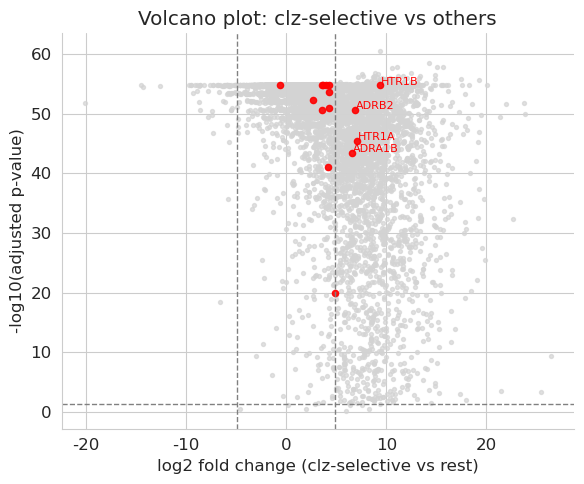

In [28]:
gpcr_genes = [
    'HTR1A','HTR1B','HTR1D','HTR1E',
    'HTR2A','HTR2B','HTR2C','HTR3A','HTR4',
    'HTR5A','HTR6','HTR7',
    'DRD1','DRD2','DRD3','DRD4','DRD5',
    'HRH1','HRH2','HRH3',
    'CHRM1','CHRM2','CHRM3','CHRM4','CHRM5',
    'ADRA1A','ADRA1B','ADRA2A','ADRA2B','ADRA2C',
    'ADRB1','ADRB2'
]

de_df["is_gpcr"] = de_df["gene"].isin(gpcr_genes)

log2fc_thr = np.log2(30)
p_thr = 0.05

fig, ax = plt.subplots(figsize=(6, 5))

# 背景（非 GPCR）
bg = de_df[~de_df["is_gpcr"]]
ax.scatter(
    bg["log2FC"],
    bg["neg_log10_p"],
    s=8,
    color="lightgray",
    alpha=0.7,
    label="other genes"
)

# GPCR
gp = de_df[de_df["is_gpcr"]]
ax.scatter(
    gp["log2FC"],
    gp["neg_log10_p"],
    s=20,
    color="red",
    alpha=0.9,
    label="GPCR genes"
)

# 閾値ライン
ax.axvline(log2fc_thr,  color="gray", linestyle="--", linewidth=1)
ax.axvline(-log2fc_thr, color="gray", linestyle="--", linewidth=1)
ax.axhline(-np.log10(p_thr), color="gray", linestyle="--", linewidth=1)

# GPCR ラベル（全部だときつければ条件絞る）
gp_label = gp[(gp["p_adj"] < p_thr) & (gp["log2FC"].abs() > log2fc_thr)]
#for _, row in gp.iterrows():
for _, row in gp_label.iterrows():
    ax.text(
        row["log2FC"] + 0.05,
        row["neg_log10_p"] + 0.1,
        row["gene"],
        fontsize=8,
        color="red"
    )

ax.set_xlabel("log2 fold change (clz-selective vs rest)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title("Volcano plot: clz-selective vs others")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
out_pdf = os.path.join(outdir, "volcano_clz_selective_log2FC_GPCRhighlight.pdf")
fig.savefig(out_pdf, bbox_inches="tight")

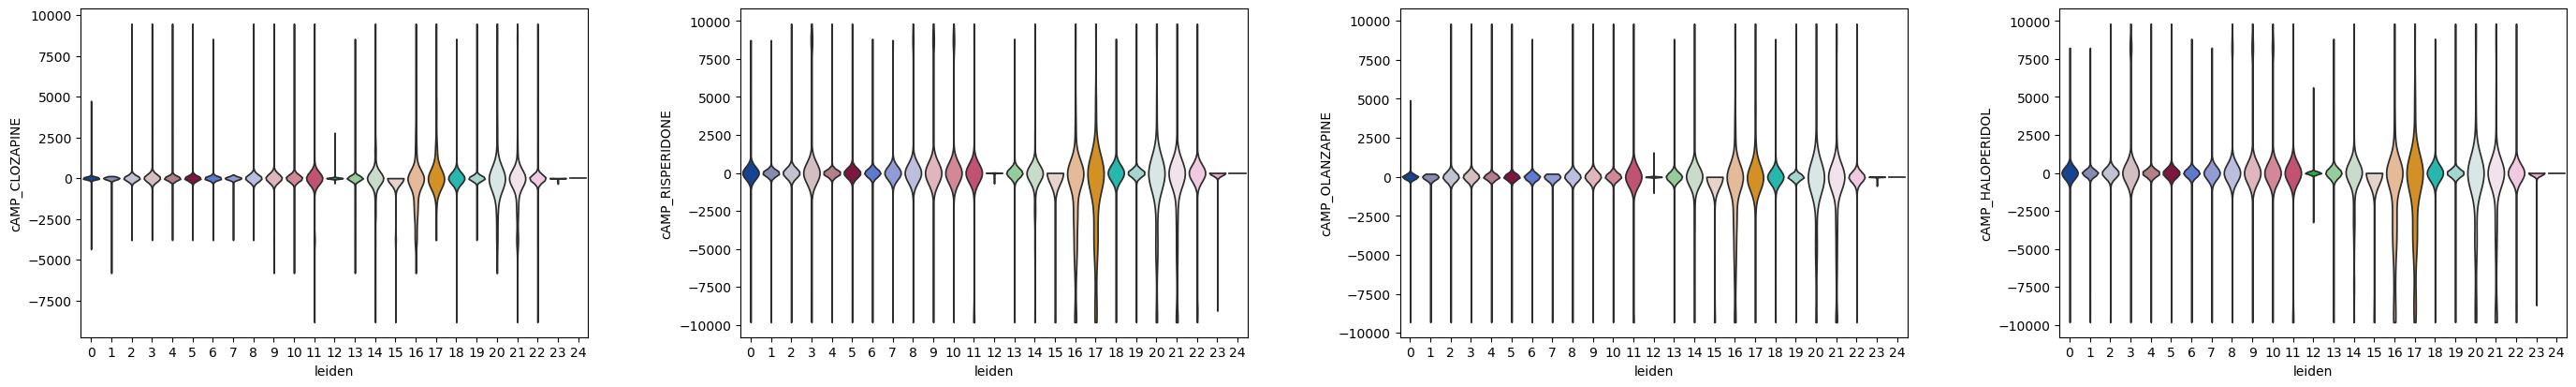

In [12]:
sc.pl.violin(
    adata,
    keys=['cAMP_CLOZAPINE',"cAMP_RISPERIDONE","cAMP_OLANZAPINE","cAMP_HALOPERIDOL"],  # Y軸に表示する変数
    groupby='leiden',       # X軸に leiden クラスタを使用
    jitter=True,            # データ点のばらつきを表示（オプション）
    stripplot=False,         # ストリッププロットを追加（オプション）
    legend=False
    
)

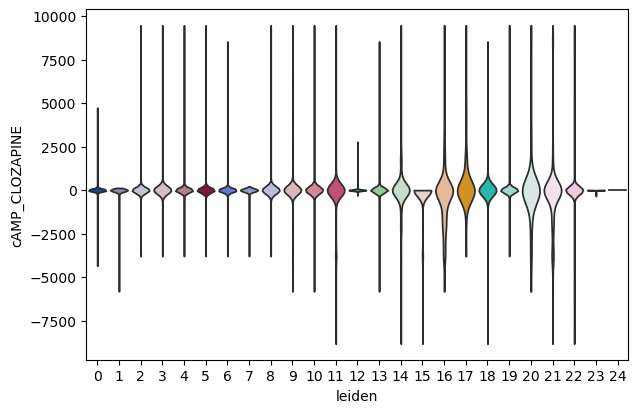

In [13]:
sc.pl.violin(
    adata,
    keys=['cAMP_CLOZAPINE'],  # Y軸に表示する変数
    groupby='leiden',       # X軸に leiden クラスタを使用
    jitter=True,            # データ点のばらつきを表示（オプション）
    stripplot=False,         # ストリッププロットを追加（オプション）
    legend=False
    
)

In [ ]:
sc.pl.umap(adata,color=["leiden"])
sc.pl.umap(adata,color=["is_clz_selective"])

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.backends.backend_pdf import PdfPages

# ============================
# フォント設定（Illustratorで文字編集可）
# ============================
rcParams["font.family"] = "Arial"          # ない場合は "DejaVu Sans"
rcParams["pdf.fonttype"] = 42              # TrueTypeフォントを埋め込み（Illustratorで編集可）
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("whitegrid")

# ============================
# 設定
# ============================
keys = [
    "cAMP_CLOZAPINE",
    "cAMP_OLANZAPINE",
    "cAMP_RISPERIDONE",
    "cAMP_HALOPERIDOL",
]

# leiden カテゴリ化とパレット作成
if not pd.api.types.is_categorical_dtype(adata.obs["leiden"]):
    adata.obs["leiden"] = adata.obs["leiden"].astype("category")

leiden_cats   = adata.obs["leiden"].cat.categories
leiden_colors = adata.uns["leiden_colors"]
palette = {cat: col for cat, col in zip(leiden_cats, leiden_colors)}

# ============================
# 複数図を1つのPDFに保存
# ============================
pdf_name = "/data/mouse_PFC/WT_only/figures/boxplots_cAMP_all.pdf"

with PdfPages(pdf_name) as pdf:
    for key in keys:
        if key not in adata.obs.columns:
            print(f"⚠️ {key} not found in adata.obs. Skipped.")
            continue

        # ---- データ準備 ----
        df = adata.obs[["leiden", key]].copy().dropna()
        if not pd.api.types.is_categorical_dtype(df["leiden"]):
            df["leiden"] = df["leiden"].astype("category")

        # ---- プロット ----
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.boxplot(
            data=df,
            x="leiden",
            y=key,
            palette=palette,
            showfliers=False,
            ax=ax
        )

        ax.set_xlabel("Leiden cluster")
        ax.set_ylabel(key)
        ax.set_title(f"{key} by Leiden cluster", pad=15)
        plt.tight_layout()

        # ---- PDFに追加 ----
        pdf.savefig(fig)
        plt.close(fig)

print(f"✅ Saved all boxplots into one Illustrator-editable PDF: {pdf_name}")

✅ Saved all boxplots into one Illustrator-editable PDF: /data/mouse_PFC/WT_only/figures/boxplots_cAMP_all.pdf


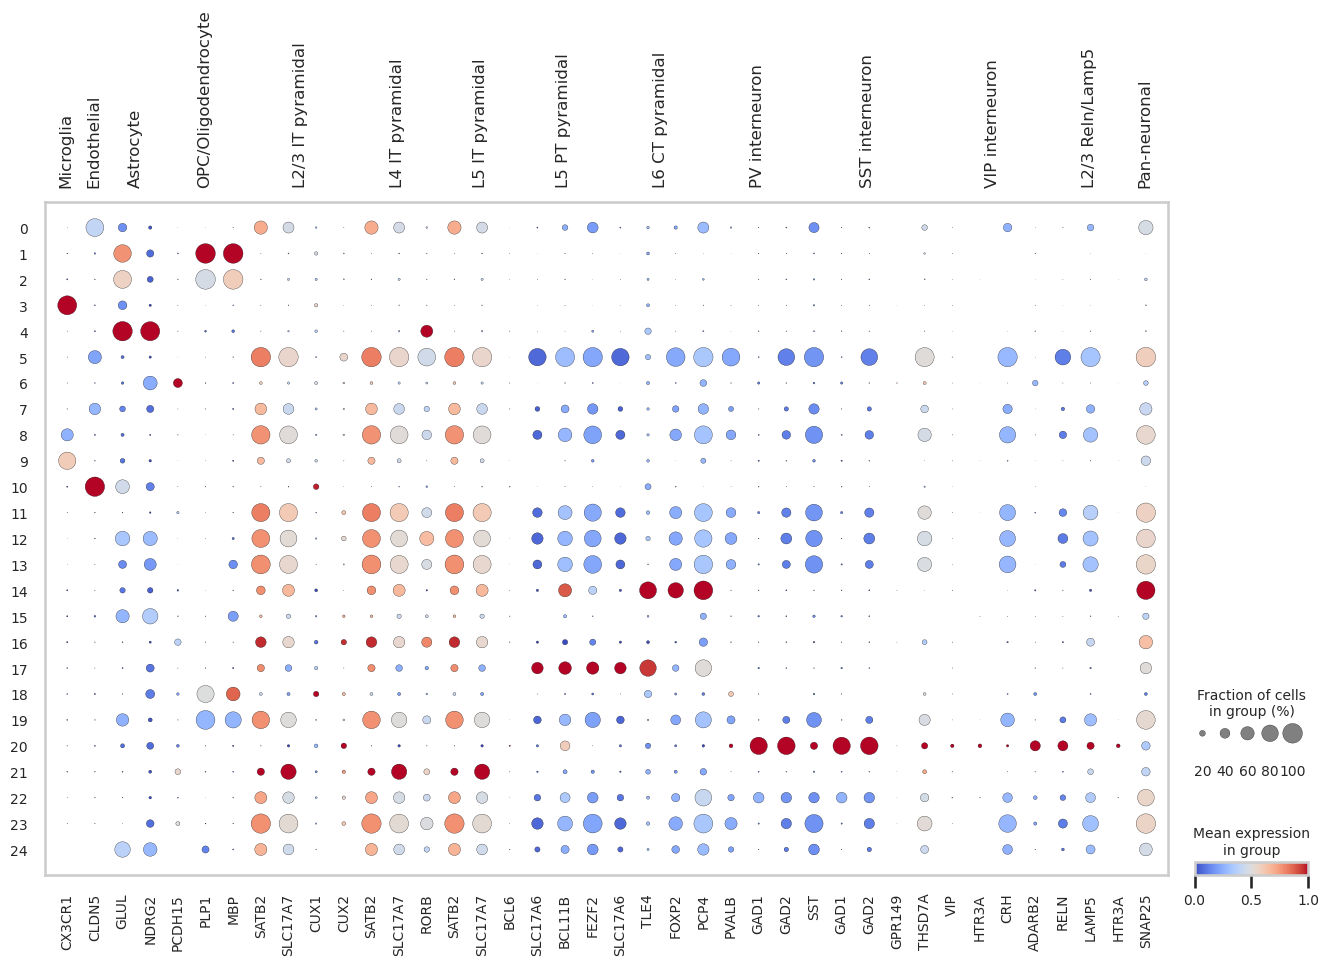

<Figure size 640x480 with 0 Axes>

In [30]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["pdf.fonttype"] = 42  # TrueTypeフォントで保存（AIで編集可能）
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "DejaVu Sans"  # 読みやすくAI互換性の高いフォント
rcParams["axes.unicode_minus"] = False
rcParams["font.size"] = 12 
marker_dict_extended = {
    # グリア・その他
    "Microglia": ["CX3CR1"],
    "Endothelial": ["CLDN5"],
    "Astrocyte": ["GLUL", "NDRG2"],
    "OPC/Oligodendrocyte": ["PCDH15", "PLP1", "MBP"],

    # 興奮性ニューロン層別
    "L2/3 IT pyramidal": ["SATB2", "SLC17A7", "CUX1", "CUX2"],
    "L4 IT pyramidal": ["SATB2", "SLC17A7", "RORB"],
    "L5 IT pyramidal": ["SATB2", "SLC17A7", "BCL6"],
    "L5 PT pyramidal": ["SLC17A6", "BCL11B", "FEZF2"],
    "L6 CT pyramidal": ["SLC17A6", "TLE4", "FOXP2", "PCP4"],

    # インターニューロン
    "PV interneuron": ["PVALB", "GAD1", "GAD2"],
    "SST interneuron": ["SST", "GAD1", "GAD2", "GPR149", "THSD7A"],
    "VIP interneuron": ["VIP", "HTR3A", "CRH", "ADARB2"],
    "L2/3 Reln/Lamp5": ["RELN", "LAMP5", "HTR3A"],

    # 汎ニューロン
    "Pan-neuronal": ["SNAP25"]
}
sc.pl.dotplot(
    adata,
    var_names=marker_dict_extended,
    groupby="leiden",
    standard_scale="var",
    color_map="coolwarm"
)
plt.savefig("/data/mouse_PFC/WT_only/figures/dotplot_marker.pdf", bbox_inches="tight")
#plt.savefig("/data/figures/dotplot_marker.pdf")

In [31]:
import os
import re
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from scipy.stats import fisher_exact, mannwhitneyu

# =========================
# settings
# =========================

OUTDIR = "/data/mouse_PFC/WT_only/clz_marker_based_analysis"
os.makedirs(OUTDIR, exist_ok=True)

CLZ_COL = "is_clz_selective"
LAYER = "lognorm"
RAW_LAYER = "raw_counts"

marker_dict_extended = {
    # グリア・その他
    "Microglia": ["CX3CR1"],
    "Endothelial": ["CLDN5"],
    "Astrocyte": ["GLUL", "NDRG2"],
    "OPC/Oligodendrocyte": ["PCDH15", "PLP1", "MBP"],

    # 興奮性ニューロン層別
    "L2/3 IT pyramidal": ["SATB2", "SLC17A7", "CUX1", "CUX2"],
    "L4 IT pyramidal": ["SATB2", "SLC17A7", "RORB"],
    "L5 IT pyramidal": ["SATB2", "SLC17A7", "BCL6"],
    "L5 PT pyramidal": ["SLC17A6", "BCL11B", "FEZF2"],
    "L6 CT pyramidal": ["SLC17A6", "TLE4", "FOXP2", "PCP4"],

    # インターニューロン
    "PV interneuron": ["PVALB", "GAD1", "GAD2"],
    "SST interneuron": ["SST", "GAD1", "GAD2", "GPR149", "THSD7A"],
    "VIP interneuron": ["VIP", "HTR3A", "CRH", "ADARB2"],
    "L2/3 Reln/Lamp5": ["RELN", "LAMP5", "HTR3A"],

    # 汎ニューロン
    "Pan-neuronal": ["SNAP25"]
}

GLIA_TYPES = [
    "Microglia",
    "Endothelial",
    "Astrocyte",
    "OPC/Oligodendrocyte"
]

EXC_TYPES = [
    "L2/3 IT pyramidal",
    "L4 IT pyramidal",
    "L5 IT pyramidal",
    "L5 PT pyramidal",
    "L6 CT pyramidal"
]

INH_TYPES = [
    "PV interneuron",
    "SST interneuron",
    "VIP interneuron",
    "L2/3 Reln/Lamp5"
]

PAN_TYPES = [
    "Pan-neuronal"
]


# =========================
# helper functions
# =========================

def sanitize_name(x):
    x = str(x)
    x = re.sub(r"[^\w]+", "_", x)
    x = re.sub(r"_+", "_", x)
    return x.strip("_")


def ensure_clz_group(adata, clz_col=CLZ_COL):
    adata.obs["_clz_group"] = (
        adata.obs[clz_col]
        .astype(str)
        .str.upper()
        .replace({"1": "TRUE", "0": "FALSE"})
        .astype("category")
    )
    print(adata.obs["_clz_group"].value_counts())
    return adata.obs["_clz_group"].isin(["TRUE", "FALSE"])


def ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER):
    if layer in adata.layers:
        print(f"adata.layers['{layer}'] already exists.")
        return

    if raw_layer not in adata.layers:
        raise ValueError(f"adata.layers['{raw_layer}'] not found.")

    print(f"Creating adata.layers['{layer}'] from adata.layers['{raw_layer}']...")
    adata.layers[layer] = adata.layers[raw_layer].copy()

    sc.pp.normalize_total(
        adata,
        target_sum=1e4,
        layer=layer
    )
    sc.pp.log1p(
        adata,
        layer=layer
    )

    adata.layers[layer] = adata.layers[layer].astype("float32")
    print("done.")


def resolve_genes(adata, genes):
    """
    大文字小文字を吸収して、adata.var_names中の正式名に戻す。
    """
    var_map = {str(g).upper(): str(g) for g in adata.var_names}
    found = []
    missing = []

    for g in genes:
        gu = str(g).upper()
        if gu in var_map:
            found.append(var_map[gu])
        else:
            missing.append(g)

    return found, missing


def get_matrix_values(adata, genes, layer=LAYER):
    found, missing = resolve_genes(adata, genes)

    if len(found) == 0:
        return None, found, missing

    idx = [adata.var_names.get_loc(g) for g in found]

    if layer is None:
        X = adata.X[:, idx]
    else:
        X = adata.layers[layer][:, idx]

    if sp.issparse(X):
        X = X.toarray()

    return np.asarray(X), found, missing


def add_marker_scores(adata, marker_dict, layer=LAYER):
    """
    各marker setの平均lognorm発現を adata.obs に追加。
    """
    marker_info = []

    for label, genes in marker_dict.items():
        X, found, missing = get_matrix_values(adata, genes, layer=layer)
        col = f"score_{sanitize_name(label)}"

        if X is None:
            adata.obs[col] = np.nan
        else:
            adata.obs[col] = X.mean(axis=1)

        marker_info.append({
            "marker_set": label,
            "score_col": col,
            "found_genes": ",".join(found),
            "missing_genes": ",".join(missing),
            "n_found": len(found),
            "n_missing": len(missing),
        })

    marker_info = pd.DataFrame(marker_info)
    marker_info.to_csv(
        os.path.join(OUTDIR, "marker_set_gene_check.csv"),
        index=False
    )

    return marker_info


def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.minimum(q, 1.0)
    return out


def category_enrichment(obs, category_col, group_col="_clz_group"):
    """
    各categoryにclz TRUEが濃縮しているかFisher exact test。
    """
    df = obs[[category_col, group_col]].copy()
    df = df[df[group_col].isin(["TRUE", "FALSE"])]
    df[category_col] = df[category_col].astype(str)

    rows = []

    for cat in sorted(df[category_col].unique()):
        in_cat = df[category_col] == cat
        is_true = df[group_col] == "TRUE"

        a = int((in_cat & is_true).sum())
        b = int((in_cat & ~is_true).sum())
        c = int((~in_cat & is_true).sum())
        d = int((~in_cat & ~is_true).sum())

        odds, p = fisher_exact([[a, b], [c, d]])

        rows.append({
            "category": cat,
            "n_TRUE_in_category": a,
            "n_FALSE_in_category": b,
            "n_TRUE_outside": c,
            "n_FALSE_outside": d,
            "clz_fraction_in_category": a / (a + b) if (a + b) > 0 else np.nan,
            "clz_fraction_outside": c / (c + d) if (c + d) > 0 else np.nan,
            "odds_ratio": odds,
            "pval": p,
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out["pval_adj"] = bh_fdr(out["pval"].values)
        out = out.sort_values(
            ["pval_adj", "odds_ratio"],
            ascending=[True, False]
        )

    return out


def compare_scores_true_vs_false(adata, score_cols, group_col="_clz_group"):
    rows = []

    for col in score_cols:
        x = adata.obs.loc[adata.obs[group_col] == "TRUE", col].dropna()
        y = adata.obs.loc[adata.obs[group_col] == "FALSE", col].dropna()

        if len(x) == 0 or len(y) == 0:
            continue

        stat, p = mannwhitneyu(x, y, alternative="two-sided")

        rows.append({
            "score_col": col,
            "marker_set": col.replace("score_", ""),
            "mean_TRUE": x.mean(),
            "mean_FALSE": y.mean(),
            "median_TRUE": x.median(),
            "median_FALSE": y.median(),
            "delta_mean_TRUE_minus_FALSE": x.mean() - y.mean(),
            "pval": p,
            "n_TRUE": len(x),
            "n_FALSE": len(y),
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out["pval_adj"] = bh_fdr(out["pval"].values)
        out = out.sort_values(
            ["pval_adj", "delta_mean_TRUE_minus_FALSE"],
            ascending=[True, False]
        )

    return out


def run_deg(adata_sub, prefix, layer=LAYER):
    adata_sub = adata_sub[
        adata_sub.obs["_clz_group"].isin(["TRUE", "FALSE"])
    ].copy()

    adata_sub.obs["_clz_group"] = adata_sub.obs["_clz_group"].astype("category")

    print(prefix)
    print(adata_sub.obs["_clz_group"].value_counts())

    sc.tl.rank_genes_groups(
        adata_sub,
        groupby="_clz_group",
        groups=["TRUE"],
        reference="FALSE",
        method="wilcoxon",
        layer=layer,
        use_raw=False,
        pts=True
    )

    df = sc.get.rank_genes_groups_df(adata_sub, group="TRUE")
    path = os.path.join(OUTDIR, f"{prefix}_DEG_TRUE_vs_FALSE.csv")
    df.to_csv(path, index=False)

    print("saved:", path)
    return df


# =========================
# prepare
# =========================

ensure_lognorm_layer(adata, layer=LAYER, raw_layer=RAW_LAYER)
valid_clz = ensure_clz_group(adata, CLZ_COL)

marker_info = add_marker_scores(
    adata,
    marker_dict_extended,
    layer=LAYER
)

print(marker_info)


# =========================
# marker score columns
# =========================

glia_score_cols = [f"score_{sanitize_name(x)}" for x in GLIA_TYPES]
exc_score_cols = [f"score_{sanitize_name(x)}" for x in EXC_TYPES]
inh_score_cols = [f"score_{sanitize_name(x)}" for x in INH_TYPES]
pan_score_cols = [f"score_{sanitize_name(x)}" for x in PAN_TYPES]

all_marker_score_cols = (
    glia_score_cols + exc_score_cols + inh_score_cols + pan_score_cols
)

# major score
adata.obs["_glia_score"] = adata.obs[glia_score_cols].max(axis=1)
adata.obs["_exc_score"] = adata.obs[exc_score_cols].max(axis=1)
adata.obs["_inh_score"] = adata.obs[inh_score_cols].max(axis=1)
adata.obs["_pan_neuronal_score"] = adata.obs[pan_score_cols].max(axis=1)

# best detailed marker type
detail_cols = glia_score_cols + exc_score_cols + inh_score_cols
score_to_label = {
    f"score_{sanitize_name(k)}": k
    for k in GLIA_TYPES + EXC_TYPES + INH_TYPES
}

adata.obs["_best_marker_score_col"] = adata.obs[detail_cols].idxmax(axis=1)
adata.obs["_best_marker_type"] = adata.obs["_best_marker_score_col"].map(score_to_label)

# major class
def assign_major_class(row):
    scores = {
        "glia_or_other": row["_glia_score"],
        "excitatory": row["_exc_score"],
        "inhibitory": row["_inh_score"],
    }
    return max(scores, key=scores.get)

adata.obs["_major_marker_class"] = adata.obs.apply(assign_major_class, axis=1)

# neuronal限定でexc/inhを決めたい場合
def assign_neuron_class(row, margin=0.02):
    if row["_exc_score"] > row["_inh_score"] + margin:
        return "excitatory_like"
    elif row["_inh_score"] > row["_exc_score"] + margin:
        return "inhibitory_like"
    else:
        return "ambiguous"

adata.obs["_exc_inh_marker_class"] = adata.obs.apply(assign_neuron_class, axis=1)


# =========================
# 1) glia以外で、clz反応細胞は興奮性 or 抑制性か
# =========================

adata_valid = adata[valid_clz].copy()

# marker scoreでglia_or_otherがbestの細胞を除外
adata_nonglia = adata_valid[
    adata_valid.obs["_major_marker_class"] != "glia_or_other"
].copy()

print("valid cells:", adata_valid.n_obs)
print("non-glia marker-based cells:", adata_nonglia.n_obs)

# excitatory / inhibitory / ambiguous のクロス集計
tab_exc_inh = pd.crosstab(
    adata_nonglia.obs["_exc_inh_marker_class"],
    adata_nonglia.obs["_clz_group"]
)

tab_exc_inh["clz_TRUE_fraction"] = (
    tab_exc_inh.get("TRUE", 0) / tab_exc_inh.sum(axis=1)
)

tab_exc_inh.to_csv(
    os.path.join(OUTDIR, "01_nonglia_exc_inh_clz_fraction.csv")
)

enrich_exc_inh = category_enrichment(
    adata_nonglia.obs,
    category_col="_exc_inh_marker_class",
    group_col="_clz_group"
)

enrich_exc_inh.to_csv(
    os.path.join(OUTDIR, "01_nonglia_exc_inh_enrichment.csv"),
    index=False
)

# 詳細marker typeごとの濃縮
tab_detail = pd.crosstab(
    adata_nonglia.obs["_best_marker_type"],
    adata_nonglia.obs["_clz_group"]
)

tab_detail["clz_TRUE_fraction"] = (
    tab_detail.get("TRUE", 0) / tab_detail.sum(axis=1)
)

tab_detail.to_csv(
    os.path.join(OUTDIR, "01_nonglia_best_marker_type_clz_fraction.csv")
)

enrich_detail = category_enrichment(
    adata_nonglia.obs,
    category_col="_best_marker_type",
    group_col="_clz_group"
)

enrich_detail.to_csv(
    os.path.join(OUTDIR, "01_nonglia_best_marker_type_enrichment.csv"),
    index=False
)

# score自体のTRUE vs FALSE比較
df_score_all = compare_scores_true_vs_false(
    adata_nonglia,
    score_cols=exc_score_cols + inh_score_cols + pan_score_cols,
    group_col="_clz_group"
)

df_score_all.to_csv(
    os.path.join(OUTDIR, "01_nonglia_marker_scores_TRUE_vs_FALSE.csv"),
    index=False
)

# non-glia内 DEG
df_deg_nonglia = run_deg(
    adata_nonglia,
    prefix="01_nonglia",
    layer=LAYER
)


# =========================
# 2) 興奮性の中でのサブタイプ解析
# =========================

adata_exc = adata_nonglia[
    adata_nonglia.obs["_exc_inh_marker_class"] == "excitatory_like"
].copy()

print("excitatory-like cells:", adata_exc.n_obs)
print(adata_exc.obs["_clz_group"].value_counts())

# 興奮性サブタイプのbest marker type
adata_exc.obs["_best_exc_subtype_col"] = adata_exc.obs[exc_score_cols].idxmax(axis=1)

exc_score_to_label = {
    f"score_{sanitize_name(k)}": k
    for k in EXC_TYPES
}

adata_exc.obs["_best_exc_subtype"] = adata_exc.obs["_best_exc_subtype_col"].map(exc_score_to_label)

# subtypeごとのclz fraction
tab_exc_subtype = pd.crosstab(
    adata_exc.obs["_best_exc_subtype"],
    adata_exc.obs["_clz_group"]
)

tab_exc_subtype["clz_TRUE_fraction"] = (
    tab_exc_subtype.get("TRUE", 0) / tab_exc_subtype.sum(axis=1)
)

tab_exc_subtype.to_csv(
    os.path.join(OUTDIR, "02_excitatory_subtype_clz_fraction.csv")
)

# subtype enrichment
enrich_exc_subtype = category_enrichment(
    adata_exc.obs,
    category_col="_best_exc_subtype",
    group_col="_clz_group"
)

enrich_exc_subtype.to_csv(
    os.path.join(OUTDIR, "02_excitatory_subtype_enrichment.csv"),
    index=False
)

# subtype marker scoreのTRUE vs FALSE比較
df_exc_score_test = compare_scores_true_vs_false(
    adata_exc,
    score_cols=exc_score_cols,
    group_col="_clz_group"
)

df_exc_score_test.to_csv(
    os.path.join(OUTDIR, "02_excitatory_subtype_scores_TRUE_vs_FALSE.csv"),
    index=False
)

# 興奮性細胞内DEG
df_deg_exc = run_deg(
    adata_exc,
    prefix="02_excitatory_only",
    layer=LAYER
)


# =========================
# Optional: marker positive rate using raw_counts
# =========================

def raw_positive_fraction_by_group(adata, marker_dict, raw_layer=RAW_LAYER, group_col="_clz_group"):
    if raw_layer not in adata.layers:
        print(f"{raw_layer} not found. skip raw positive fraction.")
        return None

    rows = []

    for marker_set, genes in marker_dict.items():
        X, found, missing = get_matrix_values(adata, genes, layer=raw_layer)

        if X is None:
            continue

        positive_any = (X > 0).any(axis=1)

        tmp = pd.DataFrame({
            "group": adata.obs[group_col].values,
            "positive_any_marker": positive_any
        })

        rates = tmp.groupby("group")["positive_any_marker"].mean()
        counts = tmp.groupby("group")["positive_any_marker"].sum()
        ns = tmp.groupby("group")["positive_any_marker"].count()

        row = {
            "marker_set": marker_set,
            "found_genes": ",".join(found),
            "missing_genes": ",".join(missing),
        }

        for g in rates.index:
            row[f"positive_fraction_{g}"] = rates.loc[g]
            row[f"positive_count_{g}"] = counts.loc[g]
            row[f"n_{g}"] = ns.loc[g]

        rows.append(row)

    return pd.DataFrame(rows)


df_raw_pos_nonglia = raw_positive_fraction_by_group(
    adata_nonglia,
    marker_dict_extended,
    raw_layer=RAW_LAYER,
    group_col="_clz_group"
)

if df_raw_pos_nonglia is not None:
    df_raw_pos_nonglia.to_csv(
        os.path.join(OUTDIR, "01_nonglia_raw_positive_fraction_by_marker_set.csv"),
        index=False
    )

df_raw_pos_exc = raw_positive_fraction_by_group(
    adata_exc,
    {k: marker_dict_extended[k] for k in EXC_TYPES},
    raw_layer=RAW_LAYER,
    group_col="_clz_group"
)

if df_raw_pos_exc is not None:
    df_raw_pos_exc.to_csv(
        os.path.join(OUTDIR, "02_excitatory_raw_positive_fraction_by_subtype_marker_set.csv"),
        index=False
    )


# =========================
# save obs with scores
# =========================

adata.obs.to_csv(
    os.path.join(OUTDIR, "adata_obs_with_marker_scores_all_cells.csv")
)

adata_nonglia.obs.to_csv(
    os.path.join(OUTDIR, "adata_obs_with_marker_scores_nonglia.csv")
)

adata_exc.obs.to_csv(
    os.path.join(OUTDIR, "adata_obs_with_marker_scores_excitatory.csv")
)

print("Done.")
print("Output dir:", OUTDIR)

adata.layers['lognorm'] already exists.
_clz_group
FALSE    15552
TRUE       207
Name: count, dtype: int64
             marker_set                  score_col  \
0             Microglia            score_Microglia   
1           Endothelial          score_Endothelial   
2             Astrocyte            score_Astrocyte   
3   OPC/Oligodendrocyte  score_OPC_Oligodendrocyte   
4     L2/3 IT pyramidal    score_L2_3_IT_pyramidal   
5       L4 IT pyramidal      score_L4_IT_pyramidal   
6       L5 IT pyramidal      score_L5_IT_pyramidal   
7       L5 PT pyramidal      score_L5_PT_pyramidal   
8       L6 CT pyramidal      score_L6_CT_pyramidal   
9        PV interneuron       score_PV_interneuron   
10      SST interneuron      score_SST_interneuron   
11      VIP interneuron      score_VIP_interneuron   
12      L2/3 Reln/Lamp5      score_L2_3_Reln_Lamp5   
13         Pan-neuronal         score_Pan_neuronal   

                    found_genes missing_genes  n_found  n_missing  
0             

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# =========================
# figure settings
# =========================
OUTDIR = "/data/mouse_PFC/WT_only/clz_marker_based_analysis"
FIGDIR = os.path.join(OUTDIR, "figures")
os.makedirs(FIGDIR, exist_ok=True)

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12


# =========================
# helper plot functions
# =========================

def savefig(name):
    path_pdf = os.path.join(FIGDIR, f"{name}.pdf")
    path_png = os.path.join(FIGDIR, f"{name}.png")
    plt.tight_layout()
    plt.savefig(path_pdf, bbox_inches="tight")
    plt.savefig(path_png, dpi=300, bbox_inches="tight")
    plt.close()
    print("saved:", path_pdf)


def plot_clz_fraction(tab, title, filename):
    """
    crosstabに clz_TRUE_fraction が入っている前提
    """
    df = tab.copy()
    df = df.sort_values("clz_TRUE_fraction", ascending=False)

    plt.figure(figsize=(6, max(3, 0.45 * len(df))))
    y = np.arange(len(df))

    plt.barh(y, df["clz_TRUE_fraction"])
    plt.yticks(y, df.index)
    plt.xlabel("Fraction of clozapine-responsive cells")
    plt.xlim(0, 1)
    plt.title(title)
    plt.gca().invert_yaxis()

    for i, v in enumerate(df["clz_TRUE_fraction"]):
        plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=10)

    savefig(filename)


def plot_enrichment(df, title, filename, top_n=20):
    """
    Fisher enrichment result:
    category, odds_ratio, pval_adj を想定
    """
    if df is None or len(df) == 0:
        print("skip:", filename)
        return

    d = df.copy()
    d = d.replace([np.inf, -np.inf], np.nan)
    d["minus_log10_fdr"] = -np.log10(d["pval_adj"].clip(lower=1e-300))
    d = d.sort_values("odds_ratio", ascending=False).head(top_n)

    plt.figure(figsize=(7, max(3, 0.45 * len(d))))
    y = np.arange(len(d))

    plt.barh(y, d["odds_ratio"])
    plt.yticks(y, d["category"])
    plt.xlabel("Odds ratio for clozapine-responsive enrichment")
    plt.title(title)
    plt.axvline(1, linestyle="--", linewidth=1)
    plt.gca().invert_yaxis()

    for i, row in enumerate(d.itertuples()):
        plt.text(
            row.odds_ratio + 0.05,
            i,
            f"FDR={row.pval_adj:.1e}",
            va="center",
            fontsize=9
        )

    savefig(filename)


def plot_score_delta(df, title, filename, top_n=20):
    """
    marker score TRUE vs FALSE:
    marker_set/score_col, delta_mean_TRUE_minus_FALSE, pval_adj を想定
    """
    if df is None or len(df) == 0:
        print("skip:", filename)
        return

    d = df.copy()
    label_col = "marker_set" if "marker_set" in d.columns else "score_col"
    d = d.sort_values("delta_mean_TRUE_minus_FALSE", ascending=False).head(top_n)

    plt.figure(figsize=(7, max(3, 0.45 * len(d))))
    y = np.arange(len(d))

    plt.barh(y, d["delta_mean_TRUE_minus_FALSE"])
    plt.yticks(y, d[label_col])
    plt.xlabel("Mean marker score difference\n(TRUE - FALSE)")
    plt.title(title)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.gca().invert_yaxis()

    for i, row in enumerate(d.itertuples()):
        if hasattr(row, "pval_adj"):
            plt.text(
                row.delta_mean_TRUE_minus_FALSE,
                i,
                f"  FDR={row.pval_adj:.1e}",
                va="center",
                fontsize=9
            )

    savefig(filename)


def plot_stacked_composition(obs, category_col, group_col="_clz_group", title="", filename="composition"):
    """
    TRUE/FALSEごとのcategory構成比をstacked barで表示
    """
    df = obs[[category_col, group_col]].copy()
    df = df[df[group_col].isin(["TRUE", "FALSE"])]
    df[category_col] = df[category_col].astype(str)

    tab = pd.crosstab(df[group_col], df[category_col])
    prop = tab.div(tab.sum(axis=1), axis=0)

    plt.figure(figsize=(8, 4))
    bottom = np.zeros(len(prop))

    x = np.arange(len(prop.index))

    for col in prop.columns:
        vals = prop[col].values
        plt.bar(x, vals, bottom=bottom, label=col)
        bottom += vals

    plt.xticks(x, prop.index)
    plt.ylabel("Proportion")
    plt.ylim(0, 1)
    plt.title(title)
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False
    )

    savefig(filename)


def plot_deg_volcano(df, title, filename, lfc_col="logfoldchanges", p_col="pvals_adj"):
    """
    DEG resultの簡易volcano
    """
    if df is None or len(df) == 0:
        print("skip:", filename)
        return

    d = df.copy()
    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=[lfc_col, p_col])
    d["minus_log10_fdr"] = -np.log10(d[p_col].clip(lower=1e-300))

    plt.figure(figsize=(5, 4))
    plt.scatter(
        d[lfc_col],
        d["minus_log10_fdr"],
        s=8,
        alpha=0.5
    )
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("log fold change")
    plt.ylabel("-log10(FDR)")
    plt.title(title)

    # 上位遺伝子をラベル
    top = d.sort_values(p_col).head(10)
    for _, row in top.iterrows():
        plt.text(
            row[lfc_col],
            row["minus_log10_fdr"],
            str(row["names"]),
            fontsize=8
        )

    savefig(filename)


# =========================
# 1) non-glia: excitatory vs inhibitory
# =========================

# Fraction plot
tab_exc_inh = pd.crosstab(
    adata_nonglia.obs["_exc_inh_marker_class"],
    adata_nonglia.obs["_clz_group"]
)
tab_exc_inh["clz_TRUE_fraction"] = (
    tab_exc_inh.get("TRUE", 0) / tab_exc_inh.sum(axis=1)
)

plot_clz_fraction(
    tab_exc_inh,
    title="Clozapine-responsive fraction by excitatory/inhibitory class",
    filename="01_nonglia_clz_fraction_exc_inh"
)

# Composition plot
plot_stacked_composition(
    adata_nonglia.obs,
    category_col="_exc_inh_marker_class",
    group_col="_clz_group",
    title="Excitatory/Inhibitory composition in clozapine-responsive vs non-responsive cells",
    filename="01_nonglia_exc_inh_composition_TRUE_FALSE"
)

# Enrichment plot
plot_enrichment(
    enrich_exc_inh,
    title="Excitatory/Inhibitory enrichment of clozapine-responsive cells",
    filename="01_nonglia_exc_inh_enrichment"
)

# Marker score delta plot
plot_score_delta(
    df_score_all,
    title="Marker score difference in non-glia cells",
    filename="01_nonglia_marker_score_delta_TRUE_minus_FALSE"
)


# =========================
# 2) non-glia detailed marker type
# =========================

tab_detail = pd.crosstab(
    adata_nonglia.obs["_best_marker_type"],
    adata_nonglia.obs["_clz_group"]
)
tab_detail["clz_TRUE_fraction"] = (
    tab_detail.get("TRUE", 0) / tab_detail.sum(axis=1)
)

plot_clz_fraction(
    tab_detail,
    title="Clozapine-responsive fraction by best marker type",
    filename="01_nonglia_clz_fraction_best_marker_type"
)

plot_stacked_composition(
    adata_nonglia.obs,
    category_col="_best_marker_type",
    group_col="_clz_group",
    title="Best marker type composition in TRUE vs FALSE",
    filename="01_nonglia_best_marker_type_composition_TRUE_FALSE"
)

plot_enrichment(
    enrich_detail,
    title="Best marker type enrichment of clozapine-responsive cells",
    filename="01_nonglia_best_marker_type_enrichment"
)


# =========================
# 3) excitatory subtype
# =========================

tab_exc_subtype = pd.crosstab(
    adata_exc.obs["_best_exc_subtype"],
    adata_exc.obs["_clz_group"]
)
tab_exc_subtype["clz_TRUE_fraction"] = (
    tab_exc_subtype.get("TRUE", 0) / tab_exc_subtype.sum(axis=1)
)

plot_clz_fraction(
    tab_exc_subtype,
    title="Clozapine-responsive fraction by excitatory subtype",
    filename="02_excitatory_clz_fraction_by_subtype"
)

plot_stacked_composition(
    adata_exc.obs,
    category_col="_best_exc_subtype",
    group_col="_clz_group",
    title="Excitatory subtype composition in TRUE vs FALSE",
    filename="02_excitatory_subtype_composition_TRUE_FALSE"
)

plot_enrichment(
    enrich_exc_subtype,
    title="Excitatory subtype enrichment of clozapine-responsive cells",
    filename="02_excitatory_subtype_enrichment"
)

plot_score_delta(
    df_exc_score_test,
    title="Excitatory subtype marker score difference",
    filename="02_excitatory_subtype_score_delta_TRUE_minus_FALSE"
)


# =========================
# 4) DEG volcano
# =========================

plot_deg_volcano(
    df_deg_nonglia,
    title="DEG in non-glia cells: clozapine-responsive vs non-responsive",
    filename="01_nonglia_DEG_volcano"
)

plot_deg_volcano(
    df_deg_exc,
    title="DEG in excitatory-like cells: clozapine-responsive vs non-responsive",
    filename="02_excitatory_DEG_volcano"
)


# =========================
# 5) Scanpy UMAP visualization
# =========================
# adataにX_umapがある場合のみ実行

if "X_umap" in adata.obsm:
    sc.pl.umap(
        adata,
        color=[
            "_clz_group",
            "_major_marker_class",
            "_exc_inh_marker_class",
            "_best_marker_type",
        ],
        frameon=False,
        wspace=0.4,
        show=False
    )
    plt.savefig(
        os.path.join(FIGDIR, "03_umap_clz_and_marker_classes.pdf"),
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(FIGDIR, "03_umap_clz_and_marker_classes.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

if "X_umap" in adata_exc.obsm:
    sc.pl.umap(
        adata_exc,
        color=[
            "_clz_group",
            "_best_exc_subtype",
            "_exc_score",
            "_inh_score",
        ],
        frameon=False,
        wspace=0.4,
        show=False
    )
    plt.savefig(
        os.path.join(FIGDIR, "03_umap_excitatory_subtypes.pdf"),
        bbox_inches="tight"
    )
    plt.savefig(
        os.path.join(FIGDIR, "03_umap_excitatory_subtypes.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()


# =========================
# 6) Dotplot: marker expression by clz group / subtype
# =========================

# TRUE vs FALSEでmarker expression
sc.pl.dotplot(
    adata_nonglia,
    var_names=marker_dict_extended,
    groupby="_clz_group",
    layer=LAYER,
    standard_scale="var",
    color_map="coolwarm",
    show=False
)
plt.savefig(
    os.path.join(FIGDIR, "04_dotplot_marker_expression_TRUE_FALSE_nonglia.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(FIGDIR, "04_dotplot_marker_expression_TRUE_FALSE_nonglia.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# excitatory subtypeごとのmarker expression
sc.pl.dotplot(
    adata_exc,
    var_names={k: marker_dict_extended[k] for k in EXC_TYPES},
    groupby="_best_exc_subtype",
    layer=LAYER,
    standard_scale="var",
    color_map="coolwarm",
    show=False
)
plt.savefig(
    os.path.join(FIGDIR, "04_dotplot_exc_marker_expression_by_subtype.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(FIGDIR, "04_dotplot_exc_marker_expression_by_subtype.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# =========================
# 7) Heatmap-like plot of marker scores
# =========================

def plot_score_heatmap(obs, score_cols, group_col, filename, title):
    d = obs[[group_col] + score_cols].copy()
    d = d[d[group_col].notna()]

    mean_df = d.groupby(group_col)[score_cols].mean()

    # z-score by marker score
    z = mean_df.copy()
    z = (z - z.mean(axis=0)) / z.std(axis=0).replace(0, np.nan)
    z = z.fillna(0)

    plt.figure(figsize=(max(6, 0.35 * len(score_cols)), 3))
    im = plt.imshow(z.values, aspect="auto")
    plt.colorbar(im, label="Z-scored mean marker score")

    plt.yticks(np.arange(z.shape[0]), z.index)
    plt.xticks(
        np.arange(z.shape[1]),
        [c.replace("score_", "") for c in z.columns],
        rotation=90
    )

    plt.title(title)
    savefig(filename)


plot_score_heatmap(
    adata_nonglia.obs,
    score_cols=exc_score_cols + inh_score_cols + pan_score_cols,
    group_col="_clz_group",
    filename="05_heatmap_marker_scores_TRUE_FALSE_nonglia",
    title="Mean marker scores in TRUE vs FALSE non-glia cells"
)

plot_score_heatmap(
    adata_exc.obs,
    score_cols=exc_score_cols,
    group_col="_clz_group",
    filename="05_heatmap_exc_subtype_scores_TRUE_FALSE",
    title="Mean excitatory subtype scores in TRUE vs FALSE cells"
)

print("All figures saved in:", FIGDIR)

saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_clz_fraction_exc_inh.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_exc_inh_composition_TRUE_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_exc_inh_enrichment.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_marker_score_delta_TRUE_minus_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_clz_fraction_best_marker_type.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_best_marker_type_composition_TRUE_FALSE.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/01_nonglia_best_marker_type_enrichment.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/02_excitatory_clz_fraction_by_subtype.pdf
saved: /data/mouse_PFC/WT_only/clz_marker_based_analysis/figures/02_excitatory_subtype_composition_TRUE_FALSE.pdf
saved: /data/m

saved: /data/mouse_PFC/WT_only/figures/dotplot_marker_with_group_line.pdf


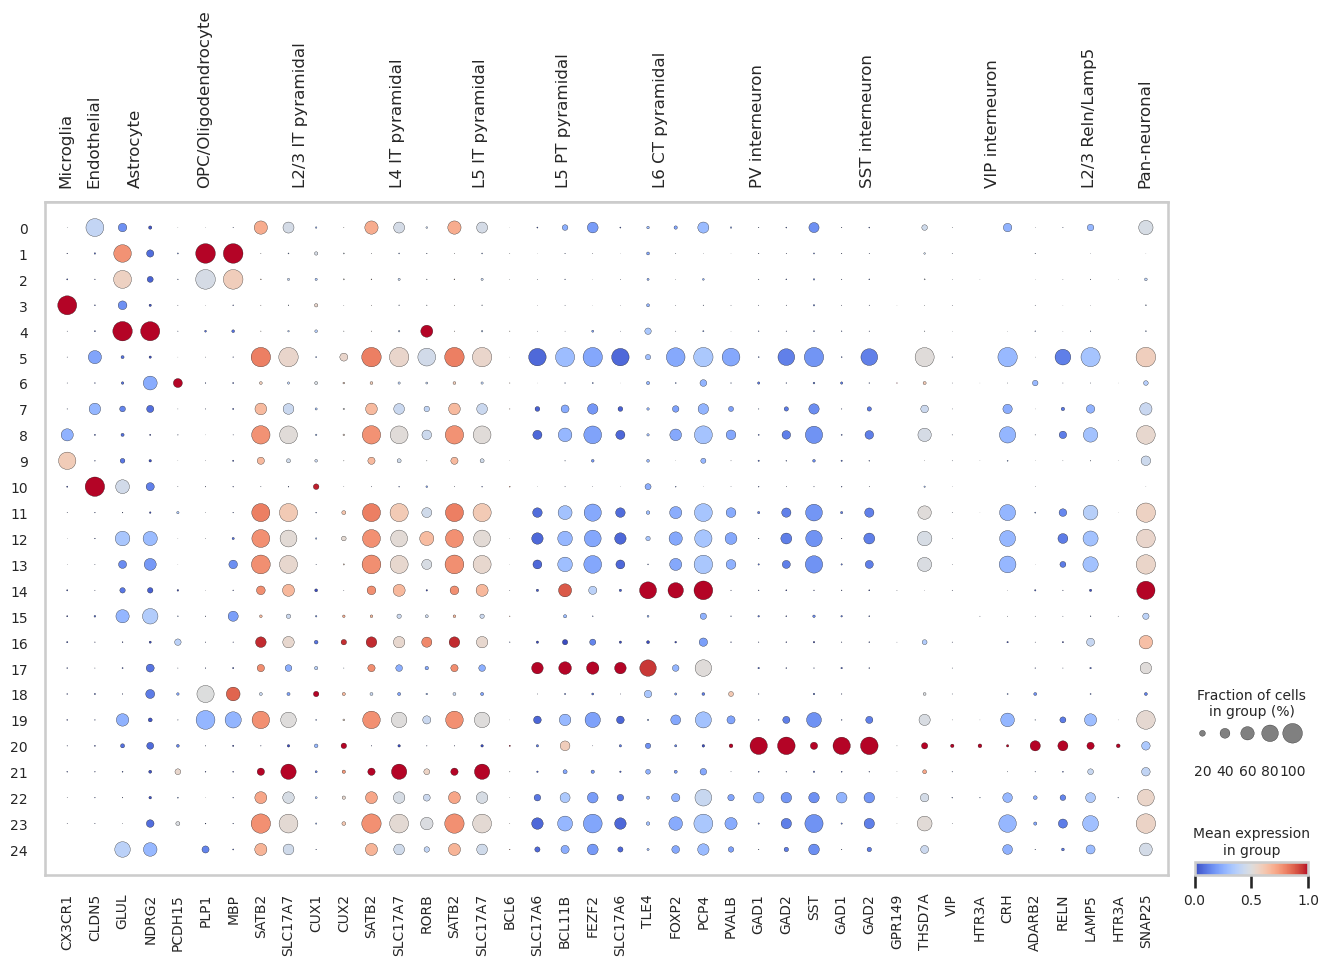

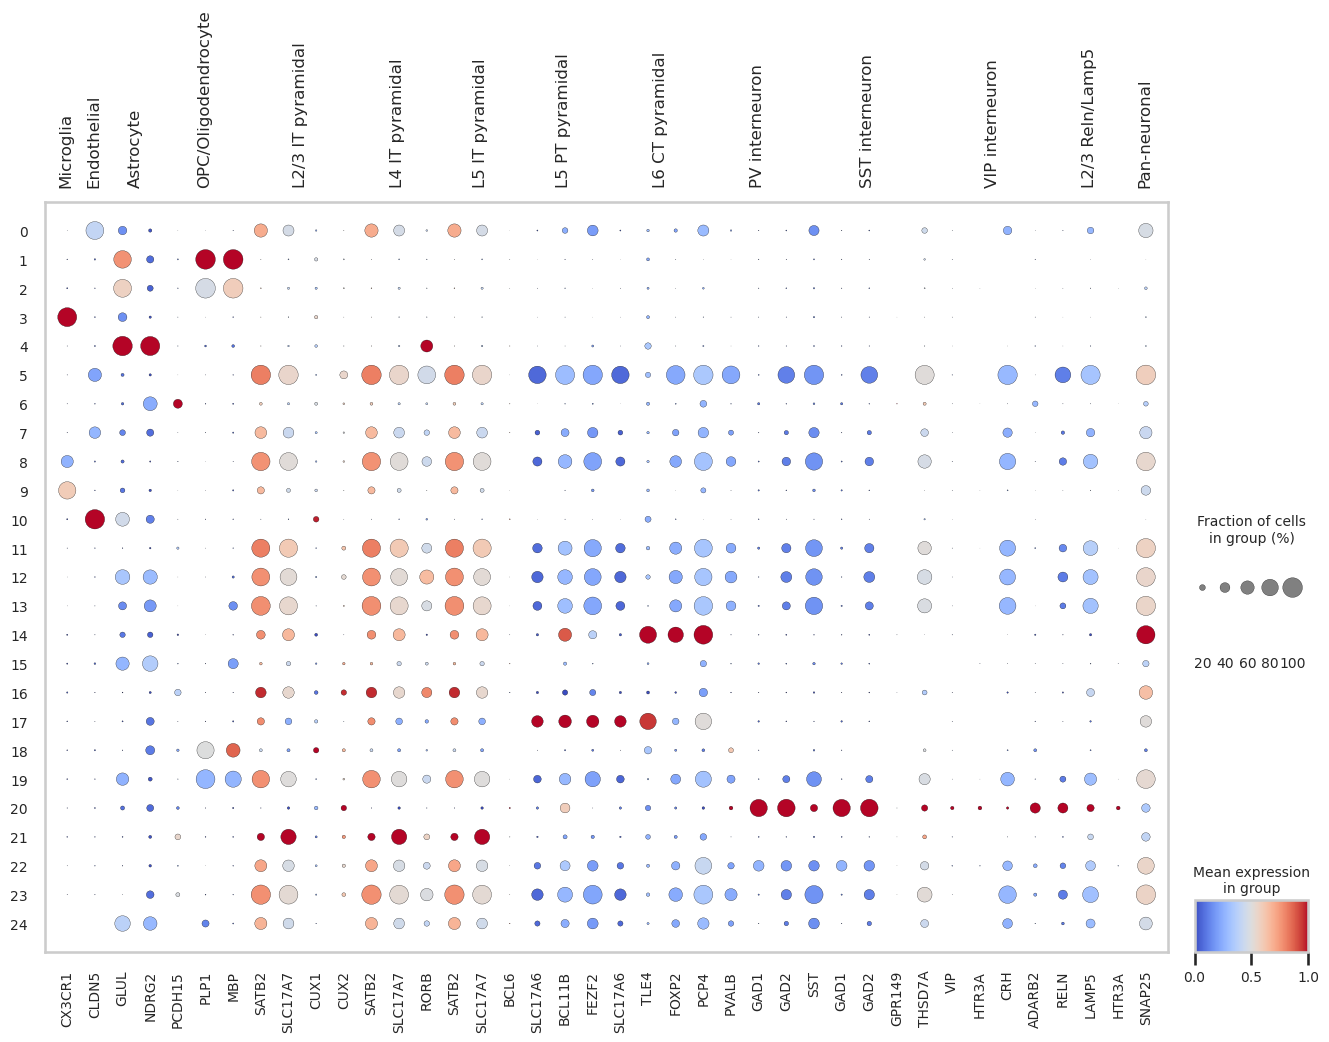

In [33]:
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rcParams

# フォントなど（必要なら）
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "DejaVu Sans"
rcParams["font.size"] = 12
rcParams["axes.unicode_minus"] = False

# --- dotplot を作る（マーカー複数・dict指定版） ---
dp = sc.pl.dotplot(
    adata,
    var_names=marker_dict_extended,  # {"celltype": [genes...], ...}
    groupby="leiden",
    standard_scale="var",
    color_map="coolwarm",
    show=True,
    return_fig=True
)

# --- 軸オブジェクトを取る ---
axes = dp.get_axes()
gax = axes["gene_group_ax"]   # ← セルタイプラベルの軸

# --- 下線（spine）を復活させる ---
gax.spines["bottom"].set_visible(True)
gax.spines["bottom"].set_linewidth(1.0)
gax.spines["bottom"].set_color("black")
gax.axhline(0, color="black", lw=1)
# 必要なら全スパインをONにしてもOK
# for side in ["bottom", "left", "right", "top"]:
#     gax.spines[side].set_visible(True)
#     gax.spines[side].set_linewidth(1.0)
#     gax.spines[side].set_color("black")

# --- PDF保存（Illustratorで編集可能） ---
out_pdf = "/data/mouse_PFC/WT_only/figures/dotplot_marker_with_group_line.pdf"
dp.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_pdf)


In [ ]:
import scanpy as sc
import pandas as pd

# ===== 1. マーカー辞書の定義 =====
marker_dict_extended = {
    "Microglia": ["CX3CR1"],
    "Endothelial": ["CLDN5"],
    "Astrocyte": ["GLUL", "NDRG2"],
    "OPC/Oligodendrocyte": ["PCDH15", "PLP1", "MBP"],

    "L2/3 IT pyramidal": ["SATB2", "SLC17A7", "CUX1", "CUX2"],
    "L4 IT pyramidal": ["SATB2", "SLC17A7", "RORB"],
    "L5 IT pyramidal": ["SATB2", "SLC17A7", "BCL6"],
    "L5 PT pyramidal": ["SLC17A6", "BCL11B", "FEZF2"],
    "L6 CT pyramidal": ["SLC17A6", "TLE4", "FOXP2", "PCP4"],

    "PV interneuron": ["PVALB", "GAD1", "GAD2"],
    "SST interneuron": ["SST", "GAD1", "GAD2", "GPR149", "THSD7A"],
    "VIP interneuron": ["VIP", "HTR3A", "CRH", "ADARB2"],
    "L2/3 Reln/Lamp5": ["RELN", "LAMP5", "HTR3A"],

    "Pan-neuronal": ["SNAP25"],
}

# ===== 2. 各細胞に cell-type スコアを付ける =====
for ct_name, genes in marker_dict_extended.items():
    sc.tl.score_genes(
        adata,
        gene_list=genes,
        score_name=f"score_{ct_name}",
        use_raw=False,      # 必要に応じて True に
    )

# ===== 3. leiden クラスタごとの平均スコアを計算 =====
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]

cluster_scores = (
    adata.obs
    .groupby("leiden")[score_cols]
    .mean()
)

print("Cluster × cell-type score (mean per leiden):")
print(cluster_scores.round(2))

# ===== 4. 各クラスタで最大スコアの cell-type を自動候補として取得 =====
best_label_per_cluster = cluster_scores.idxmax(axis=1)             # "score_xxx"
best_label_per_cluster = best_label_per_cluster.str.replace(
    "^score_", "", regex=True
)  # "score_" プレフィックスを削除

print("\nAuto-suggested cell type per leiden cluster:")
print(best_label_per_cluster)

# （オプション）各細胞に予測 celltype を付与したい場合：
cluster2celltype = best_label_per_cluster.to_dict()
adata.obs["celltype_pred"] = adata.obs["leiden"].map(cluster2celltype)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ===== フォント・PDF設定（Illustrator編集しやすく） =====
rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.unicode_minus": False,
})

# 1) score_◯◯ の列をピックアップ
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]

# 2) クラスタごと × celltypeごとの平均スコア
cluster_scores = (
    adata.obs
    .groupby("leiden")[score_cols]
    .mean()
)

# 表示用に "score_" を外した列名に
cluster_scores.columns = [c.replace("score_", "") for c in cluster_scores.columns]

# 3) 小さめのヒートマップ
plt.figure(figsize=(12, 8))  # コンパクトなサイズ
sns.heatmap(
    cluster_scores.T,    # 行: celltype, 列: cluster にしたいので転置
    cmap="viridis",
    cbar_kws={"label": "mean score"},
    annot=False
)

plt.xlabel("Leiden cluster")
plt.ylabel("Cell-type score")
plt.tight_layout()

out_pdf = "/data/figures/cluster_celltype_score_heatmap.pdf"
plt.savefig(out_pdf)

print("saved:", out_pdf)

Saved grouped bar plot to: /data/mouse_PFC/WT_only/figures/bar_cAMP_by_cluster_4drugs.pdf


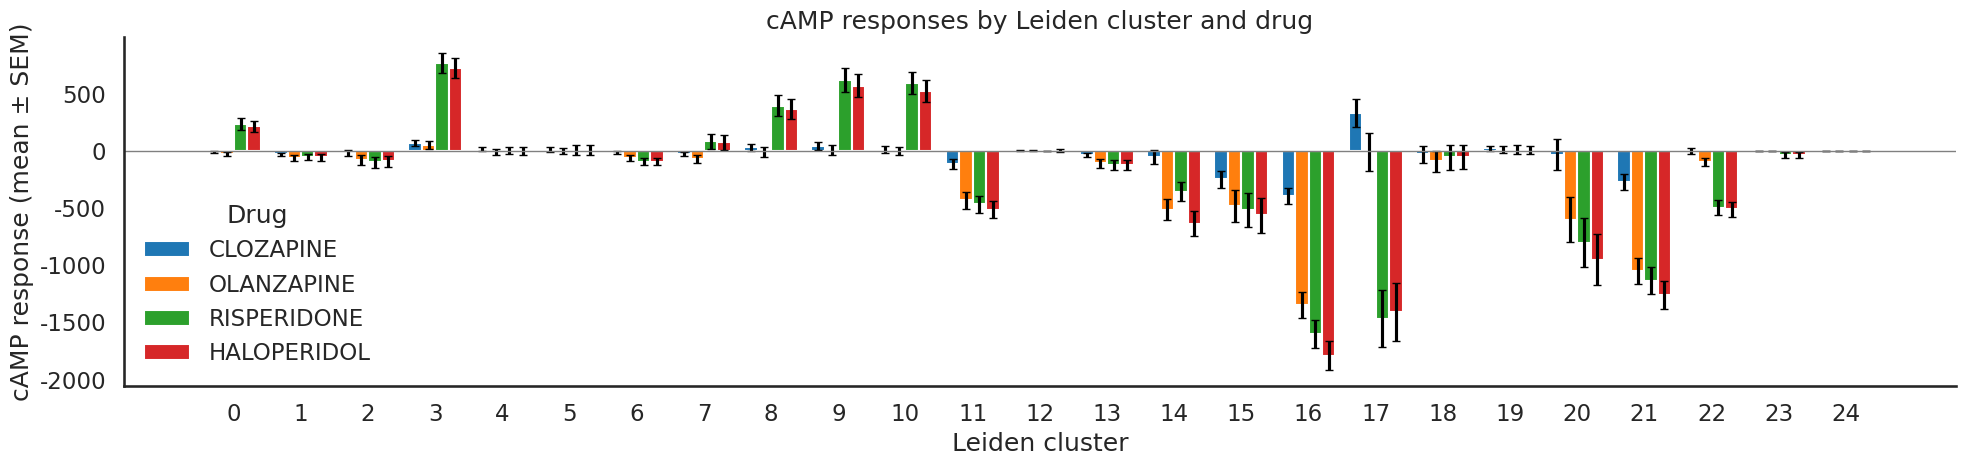

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ============================
# フォント設定（Illustratorで編集しやすい）
# ============================
rcParams["font.family"] = "DejaVu Sans"  # Arialがない環境でも代用OK
rcParams["pdf.fonttype"] = 42            # Illustratorで文字編集可能
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")  # 背景グリッドなし（whitegrid → white に変更）

# ============================
# 1. 対象の列・ラベル定義
# ============================
keys = [
    "cAMP_CLOZAPINE",
    "cAMP_OLANZAPINE",
    "cAMP_RISPERIDONE",
    "cAMP_HALOPERIDOL",
]

drug_labels = {
    "cAMP_CLOZAPINE":   "CLOZAPINE",
    "cAMP_OLANZAPINE":  "OLANZAPINE",
    "cAMP_RISPERIDONE": "RISPERIDONE",
    "cAMP_HALOPERIDOL": "HALOPERIDOL",
}

# ============================
# 2. データ準備（long形式）
# ============================
if not pd.api.types.is_categorical_dtype(adata.obs["leiden"]):
    adata.obs["leiden"] = adata.obs["leiden"].astype("category")

df = adata.obs[["leiden"] + keys].copy()
df_long = df.melt(id_vars="leiden", value_vars=keys, var_name="drug", value_name="response").dropna()

# ============================
# 3. クラスタ × 薬剤ごとの mean, SEM
# ============================
def sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

summary = (
    df_long.groupby(["leiden", "drug"])["response"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

clusters = adata.obs["leiden"].cat.categories.tolist()
mean_pivot = summary.pivot(index="leiden", columns="drug", values="mean").loc[clusters]
sem_pivot  = summary.pivot(index="leiden", columns="drug", values="sem").loc[clusters]

# ============================
# 4. プロット
# ============================
n_clusters = len(clusters)
n_drugs = len(keys)
x = np.arange(n_clusters)
width = 0.2

fig, ax = plt.subplots(figsize=(20, 5))

for i, key in enumerate(keys):
    offset = (i - (n_drugs - 1) / 2) * width
    y = mean_pivot[key].values
    yerr = sem_pivot[key].values
    ax.bar(
        x + offset,
        y,
        width,
        label=drug_labels[key],
        yerr=yerr,
        capsize=3,
    )

# ===== 背景グリッド削除 & y=0 ラインを残す =====
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.yaxis.grid(False)         # グリッド線をすべてOFF
ax.axhline(0, color="gray", lw=1, linestyle="-")  # y=0線だけ明示的に描く

# ===== 軸とラベル =====
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.set_xlabel("Leiden cluster")
ax.set_ylabel("cAMP response (mean ± SEM)")
ax.set_title("cAMP responses by Leiden cluster and drug")
ax.legend(title="Drug", frameon=False)

plt.tight_layout()


# ============================
# 5. Illustratorで編集可能なPDFとして保存
# ============================
out_pdf = "/data/mouse_PFC/WT_only/figures/bar_cAMP_by_cluster_4drugs.pdf"
plt.savefig(out_pdf)   # ベクターPDF

print(f"Saved grouped bar plot to: {out_pdf}")


Saved summary to: /data/mouse_PFC/WT_only/figures/summary_Ca_by_cluster_4drugs.csv


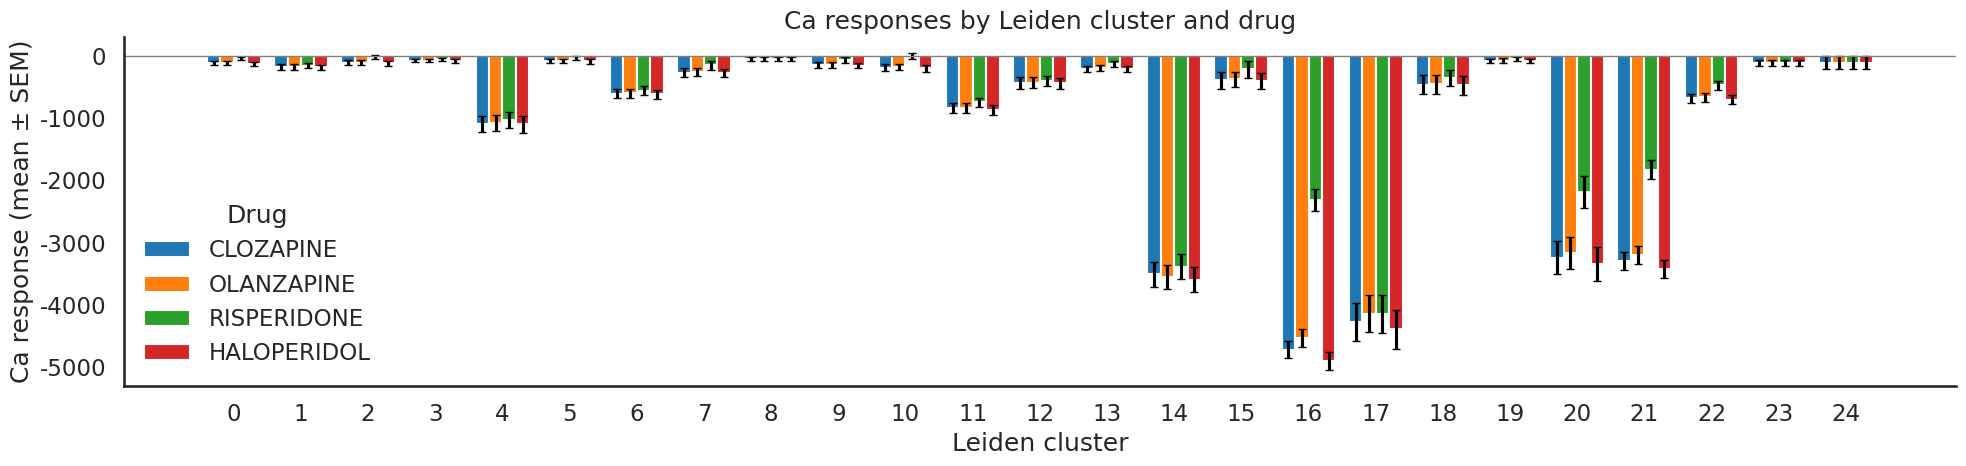

Saved grouped bar plot to: /data/mouse_PFC/WT_only/figures/bar_Ca_by_cluster_4drugs.pdf


In [35]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ============================
# フォント設定（Illustratorで編集しやすい）
# ============================
rcParams["font.family"] = "DejaVu Sans"
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")

# ============================
# 1. 対象の列・ラベル定義
# ============================
keys = [
    "Ca_CLOZAPINE",
    "Ca_OLANZAPINE",
    "Ca_RISPERIDONE",
    "Ca_HALOPERIDOL",
]

drug_labels = {
    "Ca_CLOZAPINE":   "CLOZAPINE",
    "Ca_OLANZAPINE":  "OLANZAPINE",
    "Ca_RISPERIDONE": "RISPERIDONE",
    "Ca_HALOPERIDOL": "HALOPERIDOL",
}

# 存在チェック
missing_keys = [k for k in keys if k not in adata.obs.columns]
if len(missing_keys) > 0:
    raise ValueError(f"These columns are missing in adata.obs: {missing_keys}")

# ============================
# 2. データ準備（long形式）
# ============================
if not pd.api.types.is_categorical_dtype(adata.obs["leiden"]):
    adata.obs["leiden"] = adata.obs["leiden"].astype("category")

df = adata.obs[["leiden"] + keys].copy()

df_long = (
    df.melt(
        id_vars="leiden",
        value_vars=keys,
        var_name="drug",
        value_name="response",
    )
    .dropna()
)

# ============================
# 3. クラスタ × 薬剤ごとの mean, SEM
# ============================
def sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

summary = (
    df_long.groupby(["leiden", "drug"], observed=False)["response"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

clusters = adata.obs["leiden"].cat.categories.tolist()

mean_pivot = (
    summary.pivot(index="leiden", columns="drug", values="mean")
    .loc[clusters, keys]
)

sem_pivot = (
    summary.pivot(index="leiden", columns="drug", values="sem")
    .loc[clusters, keys]
)

# summaryも保存しておくと便利
out_dir = "/data/mouse_PFC/WT_only/figures"
os.makedirs(out_dir, exist_ok=True)

summary_csv = os.path.join(out_dir, "summary_Ca_by_cluster_4drugs.csv")
summary.to_csv(summary_csv, index=False)
print(f"Saved summary to: {summary_csv}")

# ============================
# 4. プロット
# ============================
n_clusters = len(clusters)
n_drugs = len(keys)

x = np.arange(n_clusters)
width = 0.2

fig, ax = plt.subplots(figsize=(20, 5))

for i, key in enumerate(keys):
    offset = (i - (n_drugs - 1) / 2) * width

    y = mean_pivot[key].values
    yerr = sem_pivot[key].values

    ax.bar(
        x + offset,
        y,
        width,
        label=drug_labels[key],
        yerr=yerr,
        capsize=3,
    )

# ===== 背景グリッド削除 & y=0 ラインを残す =====
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

ax.yaxis.grid(False)
ax.axhline(0, color="gray", lw=1, linestyle="-")

# ===== 軸とラベル =====
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.set_xlabel("Leiden cluster")
ax.set_ylabel("Ca response (mean ± SEM)")
ax.set_title("Ca responses by Leiden cluster and drug")
ax.legend(title="Drug", frameon=False)

plt.tight_layout()

# ============================
# 5. Illustratorで編集可能なPDFとして保存
# ============================
out_pdf = os.path.join(out_dir, "bar_Ca_by_cluster_4drugs.pdf")
plt.savefig(out_pdf)
plt.show()

print(f"Saved grouped bar plot to: {out_pdf}")

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

# ===============================
# データ準備（すでに df_long がある前提）
# ===============================
# df_long : columns = ["leiden", "drug", "response"]
df_long = df_long.dropna().copy()
df_long["leiden"] = df_long["leiden"].astype("category")
df_long["drug"] = df_long["drug"].astype("category")

# ===============================
# 1. 全体の2要因ANOVA（interaction含む）
# ===============================
model = ols("response ~ C(leiden) * C(drug)", data=df_long).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n=== Two-way ANOVA (drug × cluster) ===")
print(anova_table)

interaction_p = anova_table.loc["C(leiden):C(drug)", "PR(>F)"]
if interaction_p < 0.05:
    print(f"\n✅ Significant interaction detected (p = {interaction_p:.3e})")
else:
    print(f"\n❌ No significant interaction (p = {interaction_p:.3e})")

# ===============================
# 2. 各クラスタごとの薬剤効果をANOVAでチェック
# ===============================
results = []

for cluster in df_long["leiden"].cat.categories:
    sub = df_long[df_long["leiden"] == cluster]
    if sub["drug"].nunique() < 2:
        continue

    model_sub = ols("response ~ C(drug)", data=sub).fit()
    anova_sub = sm.stats.anova_lm(model_sub, typ=2)
    pval = anova_sub.loc["C(drug)", "PR(>F)"]

    results.append({"cluster": cluster, "pval": pval})

cluster_anova_df = pd.DataFrame(results)

# ===============================
# 3. 多重比較補正（FDR, Benjamini-Hochberg）
# ===============================
cluster_anova_df["pval_adj_FDR"] = multipletests(
    cluster_anova_df["pval"], method="fdr_bh"
)[1]

# 有意なクラスタを抽出
sig_clusters = cluster_anova_df[cluster_anova_df["pval_adj_FDR"] < 0.05]

print("\n=== Per-cluster drug effect (1-way ANOVA) ===")
print(cluster_anova_df.round(4))

if len(sig_clusters) > 0:
    print("\n✅ Significant clusters after FDR correction:")
    print(sig_clusters[["cluster", "pval", "pval_adj_FDR"]].round(4))
else:
    print("\n❌ No clusters show significant drug effects after FDR correction.")

# ===============================
# 4. 保存したい場合
# ===============================
cluster_anova_df.to_csv("/data/mouse_PFC/WT_only/figures/cluster_drug_anova_FDR_4drug.csv", index=False)
print("\n📄 Saved detailed results to: cluster_drug_anova_FDR.csv")

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# ====================================
# フォント設定（Illustrator編集対応）
# ====================================
rcParams["font.family"] = "DejaVu Sans"
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")

# ====================================
# 1. データ準備（long形式）
# ====================================
# df_long: ["leiden", "drug", "response"]
df_long = df_long.dropna().copy()
df_long["leiden"] = df_long["leiden"].astype("category")
df_long["drug"] = df_long["drug"].astype("category")

# ====================================
# 2. 全体 2-way ANOVA
# ====================================
model = ols("response ~ C(leiden) * C(drug)", data=df_long).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n=== Two-way ANOVA (drug × cluster) ===")
print(anova_table)

interaction_p = anova_table.loc["C(leiden):C(drug)", "PR(>F)"]
if interaction_p < 0.05:
    print(f"\n✅ Significant interaction detected (p = {interaction_p:.3e})")
else:
    print(f"\n❌ No significant interaction (p = {interaction_p:.3e})")

# ====================================
# 3. 各クラスタごとの1要因ANOVA（drug効果）
# ====================================
results = []

for cluster in df_long["leiden"].cat.categories:
    sub = df_long[df_long["leiden"] == cluster]
    if sub["drug"].nunique() < 2:
        continue
    model_sub = ols("response ~ C(drug)", data=sub).fit()
    anova_sub = sm.stats.anova_lm(model_sub, typ=2)
    pval = anova_sub.loc["C(drug)", "PR(>F)"]
    results.append({"cluster": cluster, "pval": pval})

cluster_anova_df = pd.DataFrame(results)

# ====================================
# 4. 多重比較補正（FDR）
# ====================================
cluster_anova_df["pval_adj_FDR"] = multipletests(
    cluster_anova_df["pval"], method="fdr_bh"
)[1]

sig_clusters = cluster_anova_df[cluster_anova_df["pval_adj_FDR"] < 0.05]
print("\n=== Per-cluster drug effect (1-way ANOVA + FDR) ===")
print(cluster_anova_df.round(4))
if len(sig_clusters) > 0:
    print("\n✅ Significant clusters after FDR correction:")
    print(sig_clusters[["cluster", "pval", "pval_adj_FDR"]].round(4))
else:
    print("\n❌ No clusters show significant drug effects after FDR correction.")

# ====================================
# 5. 有意クラスタ内でTukey HSD posthoc
# ====================================
posthoc_results = []
for cluster in sig_clusters["cluster"]:
    sub = df_long[df_long["leiden"] == cluster]
    tukey = pairwise_tukeyhsd(sub["response"], sub["drug"], alpha=0.05)

    # SimpleTable からデータを直接取り出して DataFrame 化
    tbl = tukey.summary()
    data = tbl.data[1:]   # 0行目はヘッダ
    cols = tbl.data[0]

    res = pd.DataFrame(data, columns=cols)

    # 数値列を float / bool に変換（文字列のままだと扱いづらいので）
    for c in ["meandiff", "p-adj", "lower", "upper"]:
        res[c] = res[c].astype(float)
    res["reject"] = res["reject"].astype(bool)

    res["cluster"] = cluster
    posthoc_results.append(res)

if len(posthoc_results) > 0:
    posthoc_df = pd.concat(posthoc_results, ignore_index=True)

    # ★★ ここで p値に応じて星の数を付ける関数を定義 ★★
    def p_to_stars(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return "ns"

    posthoc_df["stars"] = posthoc_df["p-adj"].apply(p_to_stars)

    # p値＋星をコンソールに出力（clusterごと）
    print("\n=== Tukey HSD posthoc (adjusted p-values & stars) ===")
    for cluster in sig_clusters["cluster"]:
        sub_ph = posthoc_df[posthoc_df["cluster"] == cluster]
        if sub_ph.empty:
            continue
        print(f"\n--- Cluster {cluster} ---")
        # p 値は見やすいように指数表示
        print(
            sub_ph[["group1", "group2", "meandiff", "p-adj", "stars"]]
            .to_string(index=False, float_format=lambda x: f"{x:.3e}")
        )

    posthoc_df.to_csv(
        "/data/figures/posthoc_TukeyHSD_by_cluster.csv", index=False
    )
    print("\n📄 Saved posthoc results to: posthoc_TukeyHSD_by_cluster.csv")
else:
    posthoc_df = pd.DataFrame()
    print("\n❌ No significant clusters for Tukey posthoc.")

# ====================================
# 6. 可視化：バーグラフ＋星（p値に応じて * / ** / ***）
# ====================================
palette = sns.color_palette("Set2")
out_pdf = "/data/figures/bar_cAMP_by_cluster_posthoc.pdf"
fig, axes = plt.subplots(
    1, len(sig_clusters), figsize=(5 * len(sig_clusters), 5), sharey=True
)

if len(sig_clusters) == 1:
    axes = [axes]

for ax, cluster in zip(axes, sig_clusters["cluster"]):
    sub = df_long[df_long["leiden"] == cluster]
    order = sub["drug"].cat.categories

    # 平均 ± SEM
    summary = (
        sub.groupby("drug")["response"]
        .agg(["mean", "std", "count"])
        .assign(sem=lambda d: d["std"] / np.sqrt(d["count"]))
        .loc[order]          # drug の順番をそろえる
    )

    # seaborn barplot: 誤差バーは seaborn に任せず、自前で描く
    sns.barplot(
        x=summary.index,
        y=summary["mean"],
        ax=ax,
        palette=palette,
        edgecolor="black",
        errorbar=None,   # ← 重要：エラーバーは seaborn に描かせない
    )

    # 手動で errorbar を追加（mean ± SEM）
    x_pos = np.arange(len(summary))
    ax.errorbar(
        x_pos,
        summary["mean"].values,
        yerr=summary["sem"].values,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        capsize=3,
    )

    ax.axhline(0, color="gray", lw=1)
    ax.set_title(f"Cluster {cluster}")
    ax.set_ylabel("cAMP response")
    ax.set_xlabel("Drug")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(summary.index, rotation=45, ha="right")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(False)

    # ★マーク追加（Tukeyで有意だったペア）
    sig_pairs = posthoc_df[
        (posthoc_df["cluster"] == cluster) & (posthoc_df["p-adj"] < 0.05)
    ]
    if not sig_pairs.empty:
        ymax = (summary["mean"] + summary["sem"]).max()
        step = (summary["mean"] + summary["sem"]).max() * 0.15 or 0.1

        for _, row in sig_pairs.iterrows():
            drug1, drug2 = row["group1"], row["group2"]
            if drug1 not in summary.index or drug2 not in summary.index:
                continue

            idx1, idx2 = list(summary.index).index(drug1), list(summary.index).index(drug2)
            ax.plot([idx1, idx2], [ymax, ymax], color="black", lw=1)

            # ★★ ここで星の数を p値に応じて変える ★★
            star_text = row.get("stars", "*")  # "ns" になることもある

            ax.text(
                (idx1 + idx2) / 2,
                ymax + step * 0.2,
                star_text,
                ha="center",
                va="bottom",
                fontsize=14,
            )
            ymax += step

plt.tight_layout()
plt.savefig(out_pdf)
plt.close(fig)

print(f"\n✅ Saved summary plot with posthoc significance stars to: {out_pdf}")


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ============================
# フォント設定（Illustratorで編集しやすい）
# ============================
rcParams["font.family"] = "DejaVu Sans"  # Arialがない環境でも代用OK
rcParams["pdf.fonttype"] = 42            # Illustratorで文字編集可能
rcParams["ps.fonttype"] = 42
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")  # 背景グリッドなし（whitegrid → white に変更）

# ============================
# 1. 対象の列・ラベル定義
# ============================
keys = [
    "cAMP_CLOZAPINE",
    "cAMP_OLANZAPINE"
]

drug_labels = {
    "cAMP_CLOZAPINE":   "CLOZAPINE",
    "cAMP_OLANZAPINE":  "OLANZAPINE"
}

# ============================
# 2. データ準備（long形式）
# ============================
if not pd.api.types.is_categorical_dtype(adata.obs["leiden"]):
    adata.obs["leiden"] = adata.obs["leiden"].astype("category")

df = adata.obs[["leiden"] + keys].copy()
df_long = df.melt(id_vars="leiden", value_vars=keys, var_name="drug", value_name="response").dropna()

# ============================
# 3. クラスタ × 薬剤ごとの mean, SEM
# ============================
def sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

summary = (
    df_long.groupby(["leiden", "drug"])["response"]
    .agg(mean="mean", sem=sem)
    .reset_index()
)

clusters = adata.obs["leiden"].cat.categories.tolist()
mean_pivot = summary.pivot(index="leiden", columns="drug", values="mean").loc[clusters]
sem_pivot  = summary.pivot(index="leiden", columns="drug", values="sem").loc[clusters]

# ============================
# 4. プロット
# ============================
n_clusters = len(clusters)
n_drugs = len(keys)
x = np.arange(n_clusters)
width = 0.3

fig, ax = plt.subplots(figsize=(15, 5))

for i, key in enumerate(keys):
    offset = (i - (n_drugs - 1) / 2) * width
    y = mean_pivot[key].values
    yerr = sem_pivot[key].values
    ax.bar(
        x + offset,
        y,
        width,
        label=drug_labels[key],
        yerr=yerr,
        capsize=3,
    )

# ===== 背景グリッド削除 & y=0 ラインを残す =====
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.yaxis.grid(False)         # グリッド線をすべてOFF
ax.axhline(0, color="gray", lw=1, linestyle="-")  # y=0線だけ明示的に描く

# ===== 軸とラベル =====
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.set_xlabel("Leiden cluster")
ax.set_ylabel("cAMP response (mean ± SEM)")
ax.set_title("cAMP responses by Leiden cluster and drug")
ax.legend(title="Drug", frameon=False)

plt.tight_layout()


# ============================
# 5. Illustratorで編集可能なPDFとして保存
# ============================
out_pdf = "/data/figures/bar_cAMP_by_cluster_2drugs.pdf"
plt.savefig(out_pdf)   # ベクターPDF

print(f"Saved grouped bar plot to: {out_pdf}")


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ====== データ準備 ======
# long形式: 列は ["leiden", "drug", "response"]
# すでに df_long が存在する場合（bar plot で使ったもの）を利用
# 無ければ下のように作る：
# df_long = adata.obs.melt(id_vars="leiden", value_vars=keys, var_name="drug", value_name="response")

df_long = df_long.dropna().copy()
df_long["leiden"] = df_long["leiden"].astype("category")
df_long["drug"] = df_long["drug"].astype("category")

# ====== 2要因 ANOVA (leiden × drug) ======
model = ols("response ~ C(leiden) * C(drug)", data=df_long).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\n=== Two-way ANOVA (drug × cluster) ===")
print(anova_table)

# ====== 有意なinteractionをチェック ======
interaction_p = anova_table.loc["C(leiden):C(drug)", "PR(>F)"]
if interaction_p < 0.05:
    print(f"\n✅ Significant interaction detected (p = {interaction_p:.3e})")
else:
    print(f"\n❌ No significant interaction (p = {interaction_p:.3e})")

significant_clusters = []

for cluster in df_long["leiden"].cat.categories:
    sub = df_long[df_long["leiden"] == cluster]
    if sub["drug"].nunique() < 2:
        continue
    model_sub = ols("response ~ C(drug)", data=sub).fit()
    anova_sub = sm.stats.anova_lm(model_sub, typ=2)
    pval = anova_sub.loc["C(drug)", "PR(>F)"]
    if pval < 0.05:
        significant_clusters.append((cluster, pval))

if significant_clusters:
    print("\n✅ Clusters with significant drug effects:")
    for c, p in significant_clusters:
        print(f"  cluster {c}: p = {p:.3e}")
else:
    print("\n❌ No clusters show significant drug effect.")

In [ ]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# ============================
# 出力ディレクトリ
# ============================
outdir = "/data/figures"
os.makedirs(outdir, exist_ok=True)

# ============================
# フォント / PDF 設定（イラレ対応）
# ============================
rcParams["pdf.fonttype"] = 42   # TrueTypeとして埋め込み → Illustratorで編集可
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "DejaVu Sans"
rcParams["font.size"] = 11
rcParams["axes.unicode_minus"] = False

sns.set_context("talk")
sns.set_style("white")

# ============================
# 基本情報
# ============================
# leiden をカテゴリ化（まだなら）
adata.obs["leiden"] = adata.obs["leiden"].astype("category")

# is_clz_selective を bool に揃える（0/1でも動くように）
adata.obs["is_clz_selective"] = adata.obs["is_clz_selective"].astype(bool)

# UMAP と同じクラスタ色を使う（あれば）
leiden_cats = adata.obs["leiden"].cat.categories
if "leiden_colors" in adata.uns:
    leiden_colors = adata.uns["leiden_colors"]
    cluster_palette = {cat: col for cat, col in zip(leiden_cats, leiden_colors)}
else:
    palette = sns.color_palette("tab20", n_colors=len(leiden_cats))
    cluster_palette = {cat: col for cat, col in zip(leiden_cats, palette)}


# ============================
# 1) UMAP (leiden)
# ============================
fig1 = sc.pl.umap(
    adata,
    color="leiden",
    show=False,
    return_fig=True
)
fig1.savefig(os.path.join(outdir, "umap_leiden.pdf"),
             bbox_inches="tight")
plt.close(fig1)

# ============================
# 2) UMAP (is_clz_selective)
# ============================
fig2 = sc.pl.umap(
    adata,
    color="is_clz_selective",
    show=False,
    return_fig=True
)
fig2.savefig(os.path.join(outdir, "umap_is_clz_selective.pdf"),
             bbox_inches="tight")
plt.close(fig2)


# ============================
# 3-1) is_clz_selective な細胞のうち、
#      各 leiden クラスターの割合（横棒グラフ）
# ============================
sel = adata.obs[adata.obs["is_clz_selective"]]

# 各クラスターのカウント
sel_counts = sel["leiden"].value_counts().reindex(leiden_cats, fill_value=0)

# 0 個のクラスターは落としてよければ除外
sel_counts = sel_counts[sel_counts > 0]

# 割合（%）に変換して、見やすいように小さい方からソート
sel_pct = (sel_counts / sel_counts.sum() * 100).sort_values(ascending=True)

fig3, ax3 = plt.subplots(
    figsize=(5, max(3, 0.3 * len(sel_pct)))  # クラスター数に応じて縦サイズ少し伸ばす
)

colors = [cluster_palette[c] for c in sel_pct.index]

y_pos = np.arange(len(sel_pct))

ax3.barh(
    y_pos,
    sel_pct.values,
    color=colors,
    edgecolor="black"
)

ax3.set_yticks(y_pos)
ax3.set_yticklabels(sel_pct.index)
ax3.set_xlabel("Fraction of clz-selective cells (%)")
ax3.set_ylabel("Leiden cluster")
ax3.set_title("Cluster composition of clz-selective cells")

# 棒の右端に % ラベルを表示（混み具合で邪魔なら消してOK）
max_val = sel_pct.values.max() if len(sel_pct) > 0 else 0
for y, pct in zip(y_pos, sel_pct.values):
    ax3.text(
        pct + max_val * 0.01,  # 右にちょっとずらす
        y,
        f"{pct:.1f}%",
        va="center",
        ha="left",
        fontsize=8
    )

plt.tight_layout()
fig3.savefig(os.path.join(outdir, "barh_clz_selective_by_cluster.pdf"),
             bbox_inches="tight")
#plt.close(fig3)


# ============================
# 3-2) 各 leinden クラスターのうち、
#      is_clz_selective な割合の棒グラフ
#      （横軸: leiden, 縦軸: %）
# ============================
# クラスターごとに total / selective を集計
group = (
    adata.obs
    .groupby("leiden")["is_clz_selective"]
    .agg(total="size", sel="sum")
    .reindex(leiden_cats)
)

group["percent"] = group["sel"] / group["total"] * 100

fig4, ax4 = plt.subplots(figsize=(10, 4))

x = np.arange(len(leiden_cats))
heights = group["percent"].values
bar_colors = [cluster_palette[c] for c in leiden_cats]

ax4.bar(
    x,
    heights,
    color=bar_colors,
    edgecolor="black"
)

ax4.set_xticks(x)
ax4.set_xticklabels(leiden_cats, rotation=0)
ax4.set_ylabel("clz-selective cells (%)")
ax4.set_xlabel("Leiden cluster")

ax4.axhline(0, color="black", linewidth=1)
ax4.set_ylim(0, max(heights) * 1.2 if np.any(~np.isnan(heights)) else 1.0)

# （任意）バーの上に値を書きたい場合
for xi, h in zip(x, heights):
    ax4.text(
        xi,
        h + max(heights) * 0.02,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

fig4.tight_layout()
fig4.savefig(os.path.join(outdir, "bar_fraction_clz_selective_by_cluster.pdf"),
             bbox_inches="tight")
#plt.close(fig4)

print("✅ Saved:")
print("  - umap_leiden.pdf")
print("  - umap_is_clz_selective.pdf")
print("  - pie_clz_selective_by_cluster.pdf")
print("  - bar_fraction_clz_selective_by_cluster.pdf")


In [ ]:
# ============================
# 3-1) is_clz_selective な細胞のうち、
#      各 leiden クラスターの割合（横棒グラフ）
# ============================
sel = adata.obs[adata.obs["is_clz_selective"]]

# 各クラスターのカウント
sel_counts = sel["leiden"].value_counts().reindex(leiden_cats, fill_value=0)

# 0 個のクラスターは落としてよければ除外
sel_counts = sel_counts[sel_counts > 0]

# 割合（%）に変換して、見やすいように小さい方からソート
sel_pct = (sel_counts / sel_counts.sum() * 100).sort_values(ascending=True)

fig3, ax3 = plt.subplots(
    figsize=(5, max(3, 0.3 * len(sel_pct)))  # クラスター数に応じて縦サイズ少し伸ばす
)

colors = [cluster_palette[c] for c in sel_pct.index]
y_pos = np.arange(len(sel_pct))

ax3.barh(
    y_pos,
    sel_pct.values,
    color=colors,
    edgecolor="black"
)

ax3.set_yticks(y_pos)
ax3.set_yticklabels(sel_pct.index)
ax3.set_xlabel("Fraction of clozapine-responsive cells (%)")
ax3.set_ylabel("Leiden cluster")
ax3.set_title("Cluster composition of clz-selective cells")

# ---- グリッドとスパイン設定 ----
ax3.spines["right"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.xaxis.set_ticks_position("bottom")
ax3.yaxis.set_ticks_position("left")

# x軸に目盛り線（ticks）を追加
#ax3.xaxis.grid(True, linestyle="--", alpha=0.6)
ax3.tick_params(axis='x', which='both', direction='out')

# 棒の右端に % ラベルを表示
#max_val = sel_pct.values.max() if len(sel_pct) > 0 else 0
#for y, pct in zip(y_pos, sel_pct.values):
#    ax3.text(
#        pct + max_val * 0.01,  # 右に少しずらす
#        y,
#        f"{pct:.1f}%",
#        va="center",
#        ha="left",
#        fontsize=8
#    )

plt.tight_layout()
fig3.savefig(os.path.join(outdir, "barh_clz_selective_by_cluster.pdf"),
             bbox_inches="tight")

# ============================
# 3-2) 各 leinden クラスターのうち、
#      is_clz_selective な割合の棒グラフ
# ============================
group = (
    adata.obs
    .groupby("leiden")["is_clz_selective"]
    .agg(total="size", sel="sum")
    .reindex(leiden_cats)
)
group["percent"] = group["sel"] / group["total"] * 100

fig4, ax4 = plt.subplots(figsize=(6, 4))

x = np.arange(len(leiden_cats))
heights = group["percent"].values
bar_colors = [cluster_palette[c] for c in leiden_cats]

ax4.bar(
    x,
    heights,
    color=bar_colors,
    edgecolor="black"
)

ax4.set_xticks(x)
ax4.set_xticklabels(
    [str(i) if i % 5 == 0 else "" for i in range(len(leiden_cats))]
)
#ax4.set_xticklabels(leiden_cats, rotation=0)
ax4.set_ylabel("clozapine-responsive \n cells (%)")
ax4.set_xlabel("Leiden cluster")


ax4.axhline(0, color="black", linewidth=1)
ax4.set_ylim(0, max(heights) * 1.2 if np.any(~np.isnan(heights)) else 1.0)
ax4.set_yticks([0,5,10])
ax4.set_yticklabels([0,5,10])

# ---- 枠線とグリッド調整 ----
ax4.spines["right"].set_visible(False)
ax4.spines["top"].set_visible(False)
#ax4.yaxis.grid(True, linestyle="--", alpha=0.6)
ax4.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=4,
    width=1,
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True
)


# バー上にラベル
#for xi, h in zip(x, heights):
###    ax4.text(
#        xi,
#        h + max(heights) * 0.02,
#        f"{h:.1f}%",
#        ha="center",
#        va="bottom",
#        fontsize=9
#    )

fig4.tight_layout()
fig4.savefig(os.path.join(outdir, "bar_fraction_clz_selective_by_cluster.pdf"),
             bbox_inches="tight")

In [ ]:
adata.obs["is_Pyr"] = (adata.obs["CAMK2A_raw"]>2)&(adata.obs["CAMK2B_raw"]>2)
print(sum(adata.obs["is_Pyr"]))
adata.obs["is_Pyr"] =adata.obs["is_Pyr"].astype("category")

In [ ]:
drug_conc=10**3
results_df_sorted,all_responses=ct.sim_inhibit_pattern_3r(adata,GPCR_adata_norm_df,GPCR_type_df,drug_conc,group_col="is_Pyr", selected_label=True,n_inhibited=3)
dir="/data/mouse_PFC/Pyr-thre2-3r"

if not os.path.exists(dir):
    os.makedirs(dir)
results_df_sorted.to_pickle(os.path.join(dir,"results_df_sorted_3r.pkl"))
all_responses.to_pickle(os.path.join(dir,"all_responses_3r.pkl"))
ct.visualize_patterns(results_df_sorted, top_n=30, top_n_for_heatmap=30, scatter_n=500)

In [ ]:
drug_conc=10**5
results_df_sorted,all_responses=ct.sim_inhibit_pattern_3r(adata,GPCR_adata_norm_df,GPCR_type_df,drug_conc,group_col="is_clz_selective", selected_label=True,n_inhibited=3)
dir="/data/mouse_PFC/clz-selective-3r_conc100000"

if not os.path.exists(dir):
    os.makedirs(dir)
results_df_sorted.to_pickle(os.path.join(dir,"results_df_sorted_3r.pkl"))
all_responses.to_pickle(os.path.join(dir,"all_responses_3r.pkl"))
ct.visualize_patterns(results_df_sorted, top_n=30, top_n_for_heatmap=30, scatter_n=500)

In [ ]:
dir="/data/mouse_PFC/CZPengram-3r"
results_df_sorted=pd.read_pickle(os.path.join(dir,"results_df_sorted_3r.pkl"))
all_responses=pd.read_pickle(os.path.join(dir,"all_responses_3r.pkl"))
#ct.visualize_patterns(results_df_sorted, top_n=20, top_n_for_heatmap=20, scatter_n=500)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib as mpl

# Illustratorで文字編集可能にする設定
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

def visualize_patterns(results_df_sorted, top_n=None, top_n_for_heatmap=None, scatter_n=None,
                       save_prefix=None, save_dir=None):
    """
    Parameters:
      results_df_sorted: DataFrame with columns 'pattern_name', 'pattern', 'diff'
      top_n: ヒートマップ・棒グラフで表示する上位パターン数
      top_n_for_heatmap: 拡大版ヒートマップで表示する上位パターン数
      scatter_n: 散布図で表示するパターン数
      save_prefix: 保存ファイル名のプレフィックス（例: 'patterns'）
      save_dir: 保存先ディレクトリ（例: 'figures'）
    """
    # 保存ディレクトリの準備
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # 保存パスを組み立てるヘルパー関数
    def save_figure(fig, filename):
        if save_prefix is not None:
            if save_dir:
                filepath = os.path.join(save_dir, f"{save_prefix}_{filename}.pdf")
            else:
                filepath = f"{save_prefix}_{filename}.pdf"
            fig.savefig(filepath, bbox_inches="tight")
            print(f"Saved: {filepath}")

    # top_nの処理
    df_subset = results_df_sorted.head(top_n).reset_index(drop=True) if top_n else results_df_sorted.copy().reset_index(drop=True)
    n_patterns_subset = df_subset.shape[0]
    
    # ---- Heatmap ----
    def plot_heatmap(df, label):
        n_patterns = df.shape[0]
        first_pattern = df.iloc[0]['pattern']
        receptor_keys = list(first_pattern.keys())
        receptors = [key.replace('_raw', '') for key in receptor_keys]
        
        # True/False行列
        mat = np.array([[1 if pat.get(key, False) else 0 for key in receptor_keys] for pat in df['pattern']])
        cmap = ListedColormap(['white', 'steelblue'])
        fig, ax = plt.subplots(figsize=(12, max(6, n_patterns * 0.3)))
        im = ax.imshow(mat, aspect='auto', cmap=cmap)
        
        ax.set_xticks(np.arange(len(receptors)))
        ax.set_xticklabels(receptors, rotation=90)
        ax.set_yticks(np.arange(n_patterns))
        ax.set_yticklabels([str(i+1) for i in range(n_patterns)])
        ax.set_xlabel('Receptor Name')
        ax.set_ylabel('Pattern (sorted by diff descending)')
        ax.set_title(f'Pattern Visualization ({label}) (Top {n_patterns} Patterns)')
        ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        length=4,
        width=1,
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=True,
        labelleft=True
    )
        
        # Legend
        patches = [mpatches.Patch(color=cmap(0), label='False'),
                   mpatches.Patch(color=cmap(1), label='True')]
        ax.legend(handles=patches, title='Value',
                  bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        save_figure(fig, f"heatmap_{label or 'all'}")
        plt.show()
        plt.close(fig)

    # 通常ヒートマップ
    plot_heatmap(df_subset, label="all")

    # 拡大ヒートマップ
    if top_n_for_heatmap is not None:
        df_enlarge = results_df_sorted.head(top_n_for_heatmap).reset_index(drop=True)
        plot_heatmap(df_enlarge, label=f"top{top_n_for_heatmap}")
    
    # ---- Bar plot ----
    first_pattern = df_subset.iloc[0]['pattern']
    receptor_keys = list(first_pattern.keys())
    receptors = [key.replace('_raw', '') for key in receptor_keys]
    mat = np.array([[1 if pat.get(key, False) else 0 for key in receptor_keys] for pat in df_subset['pattern']])
    true_percentage = mat.mean(axis=0) * 100

    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.bar(np.arange(len(receptors)), true_percentage)
    ax2.set_xticks(np.arange(len(receptors)))
    ax2.set_xticklabels(receptors, rotation=90)
    ax2.set_xlabel('Receptor Name')
    ax2.set_ylabel('True Percentage (%)')
    ax2.set_title(f'True Percentage per Receptor (Top {n_patterns_subset} Patterns)')
    ax2.legend(handles=[mpatches.Patch(color='none', label='')],
               bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=4,
    width=1,
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True
)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    save_figure(fig2, "bar_true_percentage")
    plt.show()
    plt.close(fig2)
    
    # ---- Scatter plot ----
    df_scatter = results_df_sorted.head(scatter_n).reset_index(drop=True) if scatter_n else results_df_sorted.copy().reset_index(drop=True)
    total_patterns = df_scatter.shape[0]
    ticks = np.arange(0, total_patterns, 50)
    tick_labels = [str(t + 1) for t in ticks]
    
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    ax3.scatter(np.arange(total_patterns), df_scatter['diff'], s=10)
    ax3.set_xlabel('Pattern (sorted by diff descending)')
    ax3.set_ylabel('Diff')
    ax3.set_title(f'Diff Values for Top {total_patterns} Patterns (sorted descending)')
    ax3.set_xticks(ticks)
    ax3.set_xticklabels(tick_labels, rotation=90)
    ax3.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=4,
    width=1,
    bottom=True,
    top=False,
    left=True,
    right=False,
    labelbottom=True,
    labelleft=True
)
    plt.tight_layout()
    save_figure(fig3, "scatter_diff")
    plt.show()
    plt.close(fig3)


In [ ]:
visualize_patterns(
    results_df_sorted,
    top_n=10,
    top_n_for_heatmap=10,
    scatter_n=300,
    save_prefix="mouse_PFC_patterns",
    save_dir="/data/figures"
)

In [ ]:
D_R_mtx,GPCR_type_df,drug_list,GPCR_list=ct.load_parameters()

In [ ]:
import pandas as pd
import numpy as np

def compute_camp_response_for_pattern(
    adata,
    GPCR_adata_norm_df,
    GPCR_type_df,
    drug_conc,
    pattern,
    group_col="is_clz_selective",
    selected_label=True,
    Ki_inhibited=0.01,
    Ki_not_inhibited=10000,
):
    """
    特定のGPCR阻害パターンを指定したときの cAMP response を計算し、
    - clz_selective / non_clz_selective の response
    - Leiden クラスター情報
    をまとめた DataFrame を返す。

    pattern:
        キー: 'HTR1A_raw' などの GPCR 列名
        値: True (阻害) / False (非阻害)
    """

    # ---- 0. 形を揃える（位置ベースで合わせる）----
    n_cells_expr = GPCR_adata_norm_df.shape[0]

    # adata.obs のフラグを取り出して、長さだけ揃える（RangeIndex ベース）
    if group_col not in adata.obs.columns:
        raise ValueError(f"{group_col} が adata.obs にありません。")
    group_values = adata.obs[group_col].values
    if len(group_values) < n_cells_expr:
        raise ValueError("GPCR_adata_norm_df の行数の方が adata.obs より多いです。対応するセル数が足りない。")
    group_values = group_values[:n_cells_expr]
    selective_mask = pd.Series(group_values == selected_label,
                               index=pd.RangeIndex(n_cells_expr))

    # Leiden クラスタも同様に取り出し（あれば）
    if "leiden" in adata.obs.columns:
        leiden_values = adata.obs["leiden"].astype(str).values
        if len(leiden_values) < n_cells_expr:
            raise ValueError("GPCR_adata_norm_df の行数の方が adata.obs より多いです（leiden列）。")
        leiden_values = leiden_values[:n_cells_expr]
    else:
        leiden_values = np.array(["NA"] * n_cells_expr)

    # ---- 1. GPCR 発現行列の準備 ----
    GPCR_list2 = [col for col in GPCR_adata_norm_df.columns if col != "Unnamed: 0"]
    all_expr = GPCR_adata_norm_df[GPCR_list2].copy()
    # index を RangeIndex にしておく（元コードと同じノリ）
    all_expr.index = pd.RangeIndex(n_cells_expr)

    # ---- 2. Gs / Gi リスト作成 ----
    Gs = GPCR_type_df[GPCR_type_df.type == "Gs"]["receptor_name"].values
    Gi = GPCR_type_df[GPCR_type_df.type == "Gi"]["receptor_name"].values

    Gs_filtered = [gene for gene in Gs if (gene + "_raw" in all_expr.columns)]
    Gi_filtered = [gene for gene in Gi if (gene + "_raw" in all_expr.columns)]

    Gs_cols = [gene + "_raw" for gene in Gs_filtered]
    Gi_cols = [gene + "_raw" for gene in Gi_filtered]

    # ---- 3. 1パターンで cAMP response を計算 ----
    def simulate_response_all(expression_df, pattern, drug_conc, Gs_cols, Gi_cols):
        # pattern に無いキーは阻害しない(False)
        effective_Ki = pd.Series(
            {
                receptor: (Ki_inhibited if pattern.get(receptor, False) else Ki_not_inhibited)
                for receptor in expression_df.columns
            }
        )

        gs_effect = (expression_df[Gs_cols].divide(1 + drug_conc / effective_Ki[Gs_cols])).sum(axis=1)
        gi_effect = (expression_df[Gi_cols].divide(1 + drug_conc / effective_Ki[Gi_cols])).sum(axis=1)
        basal_cAMP = (expression_df[Gs_cols] - expression_df[Gi_cols]).sum(axis=1)

        cAMPmod = (gs_effect - gi_effect) - basal_cAMP  # Series(index = cell)
        return cAMPmod

    all_responses = simulate_response_all(all_expr, pattern, drug_conc, Gs_cols, Gi_cols)

    # ---- 4. plot 用 DataFrame ----
    df_plot = pd.DataFrame(index=all_responses.index)
    df_plot["cAMP_response"] = all_responses.values
    df_plot["is_clz_selective"] = selective_mask.values
    df_plot["leiden"] = leiden_values
    df_plot["group"] = np.where(df_plot["is_clz_selective"],
                                "clz_selective",
                                "non_clz_selective")

    # ---- 5. サマリー ----
    selective_mean = df_plot.loc[df_plot["is_clz_selective"], "cAMP_response"].mean()
    nonselective_mean = df_plot.loc[~df_plot["is_clz_selective"], "cAMP_response"].mean()
    diff = selective_mean - nonselective_mean

    summary = {
        "selective_mean": selective_mean,
        "nonselective_mean": nonselective_mean,
        "diff": diff,
        "n_clz_selective": int(df_plot["is_clz_selective"].sum()),
        "n_nonselective": int((~df_plot["is_clz_selective"]).sum()),
    }

    print("n_clz_selective:", summary["n_clz_selective"])
    print("n_nonselective:", summary["n_nonselective"])

    return df_plot, summary



In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Illustratorで文字編集可能にする設定
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# === 静的閾値 ===
THRESHOLD_CLZ_CELLS = 2   # ← ここを変更すれば閾値変更できる

def save_figure(fig, filename, outdir="/data/figures"):
    """図をPDFで保存（イラレ編集可）"""
    os.makedirs(outdir, exist_ok=True)
    filepath = os.path.join(outdir, filename)
    if not filepath.lower().endswith(".pdf"):
        filepath += ".pdf"
    fig.savefig(filepath, bbox_inches="tight")
    print(f"✅ Saved: {filepath}")


def plot_camp_responses(df_plot, summary, pattern_name="pattern", outdir="/data/figures"):
    """
    clz_selective vs non_clz_selective / Leiden別のcAMP反応を可視化しPDF保存。
    外れ値非表示、上右スパイン非表示、clz_selectiveを赤、その他を黒で描画。
    clz_selective細胞が THRESHOLD_CLZ_CELLS 未満のクラスタは非表示。
    """
    # === 1. clz_selective vs non_clz_selective ===
    fig1, ax1 = plt.subplots(figsize=(4, 6))
    groups = ["clz_selective", "non_clz_selective"]
    colors = ["red", "black"]

    data = [df_plot.loc[df_plot["group"] == g, "cAMP_response"].values for g in groups]
    ax1.boxplot(data, labels=groups, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='white', edgecolor='black'))
    ax1.set_ylabel("cAMP response (Δ)")
    ax1.set_title("cAMP response by clozapine selectivity")

    # 上・右スパインを非表示
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # scatter overlay
    #for i, grp in enumerate(groups, start=1):
    #    y = df_plot.loc[df_plot["group"] == grp, "cAMP_response"].values
    #    x = np.random.normal(loc=i, scale=0.05, size=len(y))
    #    ax1.scatter(x, y, s=6, alpha=0.5, color=colors[i - 1])

    plt.tight_layout()
    save_figure(fig1, f"{pattern_name}_cAMP_clz_vs_nonclz.pdf", outdir)
    plt.close(fig1)

    # === 2. LeidenクラスタごとのcAMP反応 ===
    clusters = sorted(df_plot["leiden"].unique(), key=lambda x: int(x) if str(x).isdigit() else str(x))
    fig2, ax2 = plt.subplots(figsize=(max(6, len(clusters) * 0.4), 6))
    data = [df_plot.loc[df_plot["leiden"] == cl, "cAMP_response"].values for cl in clusters]
    labels = [str(cl) for cl in clusters]
    ax2.boxplot(data, labels=labels, showfliers=False)
    ax2.set_ylabel("cAMP response (Δ)")
    ax2.set_title("cAMP response by Leiden cluster")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    plt.xticks(rotation=90)
    plt.tight_layout()
    save_figure(fig2, f"{pattern_name}_cAMP_by_leiden.pdf", outdir)
    plt.close(fig2)

    # === 3. Leiden × clz_selective / non_clz_selective ===
    fig3, ax3 = plt.subplots(figsize=(max(6, len(clusters) * 0.8), 6))
    positions, data, tick_pos, tick_labels = [], [], [], []

    for cl in clusters:
        # 各クラスタでclz_selective細胞数をチェック
        n_clz = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "clz_selective")].shape[0]
        if n_clz < THRESHOLD_CLZ_CELLS:
            print(f"⚠️ Skipped Leiden {cl}: clz_selective cells < threshold ({n_clz} < {THRESHOLD_CLZ_CELLS})")
            continue

        # ここで「採用済みクラスタ数」から base を決める → 歯抜け防止
        base = len(tick_pos) * 3

        vals_sel = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "clz_selective"),
                               "cAMP_response"].values
        vals_non = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "non_clz_selective"),
                               "cAMP_response"].values

        positions.extend([base - 0.5, base + 0.5])
        data.extend([vals_sel, vals_non])
        tick_pos.append(base)
        tick_labels.append(str(cl))

    if data:
        bp = ax3.boxplot(data, positions=positions, showfliers=False, patch_artist=True)
        for j, box in enumerate(bp['boxes']):
            box.set(facecolor='white',
                    edgecolor='red' if j % 2 == 0 else 'black',
                    linewidth=1.2)

        ax3.set_xticks(tick_pos)
        ax3.set_xticklabels(tick_labels, rotation=90)
        ax3.set_ylabel("cAMP response (Δ)")
        ax3.set_title("cAMP response by Leiden cluster × clozapine selectivity")

        # 上右スパインを非表示
        ax3.spines["top"].set_visible(False)
        ax3.spines["right"].set_visible(False)

        plt.tight_layout()
        save_figure(fig3, f"{pattern_name}_cAMP_by_leiden_and_clz_old.pdf", outdir)
    else:
        print(f"⚠️ No clusters with ≥{THRESHOLD_CLZ_CELLS} clz_selective cells to plot.")
    plt.close(fig3)

    print(f"🎨 Figures saved to '{outdir}' (threshold={THRESHOLD_CLZ_CELLS}, clz=red, others=black)")


In [ ]:
# 例: diff が最大のパターン
best_pattern = results_df_sorted.iloc[1]["pattern"]

THRESHOLD_CLZ_CELLS = 4
# cAMP反応の計算済みデータを利用
df_plot, summary = compute_camp_response_for_pattern(
    adata=adata,
    GPCR_adata_norm_df=GPCR_adata_norm_df,
    GPCR_type_df=GPCR_type_df,
    drug_conc=drug_conc,
    pattern=best_pattern,
    group_col="is_clz_selective",
    selected_label=True,
)

# プロットして保存
plot_camp_responses(df_plot, summary, pattern_name="best_pattern")

In [ ]:
def plot_camp_responses(df_plot, summary, adata, pattern_name="pattern", outdir="/data/figures"):
    """
    Leidenクラスタカラーを adata.uns['leiden_colors'] から取得。
    clz_selective枠線を赤、non_clzを黒に。
    スキップクラスタ分を詰めて配置し、図幅も自動調整。
    """
    clusters_all = sorted(df_plot["leiden"].unique(), key=lambda x: int(x) if str(x).isdigit() else str(x))

    # --- Scanpy UMAPのクラスタカラーを使用 ---
    if "leiden_colors" in adata.uns:
        leiden_colors = adata.uns["leiden_colors"]
        print(f"🎨 Using {len(leiden_colors)} Leiden colors from adata.uns['leiden_colors']")
    else:
        import matplotlib.cm as cm
        cmap = cm.get_cmap("tab10", len(clusters_all))
        leiden_colors = [cmap(i) for i in range(len(clusters_all))]
        print("⚠️ adata.uns['leiden_colors'] not found. Using tab10 fallback palette.")

    # === プロット対象クラスタを抽出 ===
    clusters_valid = []
    for cl in clusters_all:
        n_clz = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "clz_selective")].shape[0]
        if n_clz >= THRESHOLD_CLZ_CELLS:
            clusters_valid.append(cl)
        else:
            print(f"⚠️ Skipped Leiden {cl}: clz_selective cells < threshold ({n_clz} < {THRESHOLD_CLZ_CELLS})")

    if len(clusters_valid) == 0:
        print(f"⚠️ No clusters with ≥{THRESHOLD_CLZ_CELLS} clz_selective cells to plot.")
        return

    # --- 有効クラスタ数に基づいて図の横幅を調整 ---
    fig_width = max(8, len(clusters_valid) * 1)
    fig3, ax3 = plt.subplots(figsize=(fig_width, 6))

    positions, data, tick_pos, tick_labels, colors_used = [], [], [], [], []

    # === データと色をまとめる ===
    for cl in clusters_valid:
        base = len(tick_pos) * 3  # 歯抜け防止

        vals_sel = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "clz_selective"), "cAMP_response"].values
        vals_non = df_plot.loc[(df_plot["leiden"] == cl) & (df_plot["group"] == "non_clz_selective"), "cAMP_response"].values

        positions.extend([base - 0.5, base + 0.5])
        data.extend([vals_sel, vals_non])
        tick_pos.append(base)
        tick_labels.append(str(cl))

        # Leiden カラーを adata.uns['leiden_colors'] から取得
        try:
            colors_used.append(leiden_colors[int(cl)])
        except Exception:
            colors_used.append(leiden_colors[len(colors_used) % len(leiden_colors)])

    # === ボックスプロット描画 ===
    bp = ax3.boxplot(data, positions=positions, showfliers=False, patch_artist=True)
    for j, box in enumerate(bp['boxes']):
        cluster_idx = j // 2
        cluster_color = colors_used[cluster_idx]
        if j % 2 == 0:
            # clz_selective
            box.set(facecolor=cluster_color, edgecolor='red', linewidth=1.5)
        else:
            # non_clz_selective
            box.set(facecolor=cluster_color, edgecolor='black', linewidth=1.2)

    # 軸ラベル設定
    ax3.set_xticks(tick_pos)
    ax3.set_xticklabels(tick_labels, rotation=90)
    ax3.set_ylabel("cAMP response (Δ)")
    ax3.set_title(f"cAMP response by Leiden cluster × clozapine selectivity\n(threshold={THRESHOLD_CLZ_CELLS})")

    # スパイン非表示
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)

    plt.tight_layout()
    save_figure(fig3, f"{pattern_name}_cAMP_by_leiden_and_clz.pdf", outdir)
    plt.close(fig3)

    print(f"🎨 Finished plotting {len(clusters_valid)} clusters → width adjusted to {fig_width:.1f}")

In [ ]:
THRESHOLD_CLZ_CELLS = 4  # 閾値設定（例）
plot_camp_responses(df_plot, summary, adata=adata, pattern_name="best_pattern")

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

def ttest_clz_vs_nonclz(df_plot):
    """
    clz_selective vs non_clz_selective で cAMP_response の t検定（Welch）を実行
    """
    df = df_plot.copy()
    df = df.dropna(subset=["cAMP_response", "group"])  # 念のため

    clz_vals = df.loc[df["group"] == "clz_selective", "cAMP_response"].values
    non_vals = df.loc[df["group"] == "non_clz_selective", "cAMP_response"].values

    res = ttest_ind(clz_vals, non_vals, equal_var=False, nan_policy="omit")

    result_dict = {
        "n_clz": int(np.sum(~np.isnan(clz_vals))),
        "n_nonclz": int(np.sum(~np.isnan(non_vals))),
        "t_stat": res.statistic,
        "p_value": res.pvalue,
    }
    return result_dict
tt_res = ttest_clz_vs_nonclz(df_plot)
print(tt_res)

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import ttest_ind

def anova_and_posthoc_camp(df_plot):
    """
    2因子ANOVA (group × leiden) と、
    各Leidenクラスター内での clz vs non-clz の posthoc t検定を行う。
    
    Returns
    -------
    anova_table : pd.DataFrame
        2因子 ANOVA の分散分析表
    posthoc_df : pd.DataFrame
        各 Leiden 内での t検定結果（pをBonferroni補正したものも含む）
    """
    df = df_plot.copy()
    df = df.dropna(subset=["cAMP_response", "group", "leiden"])

    # カテゴリ型にしておく
    df["group"] = df["group"].astype("category")
    df["leiden"] = df["leiden"].astype("category")

    # ---- 2因子ANOVA ----
    model = ols("cAMP_response ~ C(group) * C(leiden)", data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)  # typ=2 か 3 は好みで

    # ---- posthoc: 各Leiden内でclz vs non-clz を t検定 ----
    posthoc_results = []
    clusters = sorted(df["leiden"].cat.categories, key=lambda x: int(x) if str(x).isdigit() else str(x))

    for cl in clusters:
        sub = df[df["leiden"] == cl]
        vals_clz = sub.loc[sub["group"] == "clz_selective", "cAMP_response"].values
        vals_non = sub.loc[sub["group"] == "non_clz_selective", "cAMP_response"].values

        # 両群にデータがない/1例以下ならスキップ
        if np.sum(~np.isnan(vals_clz)) < 2 or np.sum(~np.isnan(vals_non)) < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            t_res = ttest_ind(vals_clz, vals_non, equal_var=False, nan_policy="omit")
            t_stat, p_val = t_res.statistic, t_res.pvalue

        posthoc_results.append({
            "leiden": cl,
            "n_clz": int(np.sum(~np.isnan(vals_clz))),
            "n_nonclz": int(np.sum(~np.isnan(vals_non))),
            "t_stat": t_stat,
            "p_raw": p_val,
        })

    posthoc_df = pd.DataFrame(posthoc_results)

    # Bonferroni補正（Leidenの数で割る）
    m = posthoc_df["p_raw"].notna().sum()
    if m > 0:
        posthoc_df["p_bonferroni"] = np.minimum(posthoc_df["p_raw"] * m, 1.0)
    else:
        posthoc_df["p_bonferroni"] = np.nan

    return anova_table, posthoc_df

anova_table, posthoc_df = anova_and_posthoc_camp(df_plot)

print("=== 2-way ANOVA (group × leiden) ===")
print(anova_table)

print("\n=== Posthoc: clz vs non-clz within each Leiden (t-test, Bonferroni corrected) ===")
print(posthoc_df)

In [ ]:
# 例: diff が最大のパターン
best_pattern = results_df_sorted.iloc[1]["pattern"]

import matplotlib.pyplot as plt
import numpy as np
mpl.rcParams.update(mpl.rcParamsDefault)
df_plot, summary = compute_camp_response_for_pattern(
    adata=adata,
    GPCR_adata_norm_df=GPCR_adata_norm_df,
    GPCR_type_df=GPCR_type_df,
    drug_conc=drug_conc,
    pattern=best_pattern,          # 使いたいパターン
    group_col="is_clz_selective",
    selected_label=True,
)

print(summary)

# clz_selective vs non_clz_selective boxplot
fig, ax = plt.subplots(figsize=(4, 6))

data = [
    df_plot.loc[df_plot["group"] == "clz_selective", "cAMP_response"].values,
    df_plot.loc[df_plot["group"] == "non_clz_selective", "cAMP_response"].values,
]
labels = ["clz_selective", "non_clz_selective"]

ax.boxplot(data, labels=labels)
ax.set_ylabel("cAMP response (Δ)")
ax.set_title("cAMP response by clozapine selectivity")

plt.tight_layout()
plt.show()

In [ ]:
best_pattern

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Illustrator で編集しやすい PDF 設定 =====
plt.rcParams["pdf.fonttype"] = 42   # フォントをアウトライン化しない（TrueType）
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["figure.dpi"] = 300    # 表示用。PDF自体はベクターなのでここはお好み
plt.rcParams["font.size"] = 16
# ===== データ読み込み =====
# 例: タブ区切りの場合（質問の表っぽい形式）
df = D_R_mtx
# CSVなら↓
# 薬剤名（index）を頭文字のみ大文字に統一
df.index = [name.capitalize() for name in df.index]
# 行: drug（Ligand）, 列: 受容体名 になっている前提
# 値のダイナミックレンジが大きいので log10 にして可視化した方が見やすい場合が多い
data = df.astype(float)
log_data = np.log10(data)

# ===== ヒートマップ描画 =====
fig, ax = plt.subplots(figsize=(10, 4))  # サイズはお好みで

# imshow でヒートマップを描く（ベクター PDF で保存される）
im = ax.imshow(
    log_data.values,
    aspect="auto",      # 行数・列数に応じて自動調整
    cmap="coolwarm_r",     # カラーマップ（お好みで変更）
    interpolation="nearest"
)

# 軸ラベル・目盛
ax.set_xticks(np.arange(log_data.shape[1]))
ax.set_xticklabels(log_data.columns, rotation=90)

ax.set_yticks(np.arange(log_data.shape[0]))
ax.set_yticklabels(log_data.index)

ax.set_xlabel("Receptor")
ax.set_ylabel("Drug")



# カラーバー（log10[affinity] であることを明記）
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("log10(Ki)")

plt.tight_layout()


# ===== PDF 保存（Illustrator で編集可能） =====
output_path = "/data/figures/drug_receptor_affinity_heatmap.pdf"
plt.savefig(output_path, format="pdf")  # ベクター形式で保存
plt.show(fig)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# cAMP_clozapine のカラム名判定
if "cAMP_CLOZAPINE" in adata.obs.columns:
    camp_key = "cAMP_CLOZAPINE"
elif "cAMP_clozapine" in adata.obs.columns:
    camp_key = "cAMP_clozapine"
else:
    raise KeyError("adata.obs に cAMP_CLOZAPINE / cAMP_clozapine が見つからないよ")

adata.obs["leiden"] = adata.obs["leiden"].astype("category")

# クラスターのリスト（文字列としてソート）
clusters = sorted(adata.obs["leiden"].cat.categories, key=lambda x: int(x))

# 各クラスターの値をリストにまとめる
data_per_cluster = [
    adata.obs.loc[adata.obs["leiden"] == cl, camp_key].values
    for cl in clusters
]

plt.figure(figsize=(8, 4))
plt.boxplot(data_per_cluster, showfliers=False)  # 外れ値を非表示にするなら showfliers=False

plt.xticks(np.arange(1, len(clusters) + 1), clusters, rotation=90)
plt.xlabel("Leiden cluster")
plt.ylabel(camp_key)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Illustrator で編集しやすい PDF 設定（必要なら）
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 18
# 使う薬剤リスト
drug_list = [
    'CHLORPROMAZINE',
    'FLUPHENAZINE',
    'HALOPERIDOL',
    'ZOTEPINE',
    'RISPERIDONE',
    'QUETIAPINE',
    'OLANZAPINE',
    'CLOZAPINE'
]

# ===== 前提：adata には既に以下が入っている =====
#  - adata.obs["leiden"] : クラスターラベル（文字列）
#  - adata.obs["cAMP_<DRUG>"] : 各薬剤の cAMP 反応

# leiden をカテゴリに統一
adata.obs["leiden"] = adata.obs["leiden"].astype("category")

# クラスターを数値順にソート（"0","1","2",... を想定）
clusters = sorted(adata.obs["leiden"].cat.categories, key=lambda x: int(x))

# ヒートマップ用の行列 (行: drug, 列: leiden cluster)
heatmap = np.zeros((len(drug_list), len(clusters)), dtype=float)

for i, drug in enumerate(drug_list):
    col_name = f"cAMP_{drug}"
    if col_name not in adata.obs.columns:
        raise KeyError(f"{col_name} が adata.obs に見つからない")

    # クラスターごとの平均 cAMP 反応
    mean_per_cluster = (
        adata.obs
        .groupby("leiden")[col_name]
        .mean()
        .reindex(clusters)   # クラスター順を揃える
    )
    heatmap[i, :] = mean_per_cluster.values

# 表示用の薬剤名（頭文字だけ大文字）
drug_labels = [d.capitalize() for d in drug_list]

# === ヒートマップ描画 ===
fig, ax = plt.subplots(
    figsize=(max(6, len(clusters) * 0.6), max(4, len(drug_list) * 0.5))
)

# 0 を中心にしたいので vmin/vmax を対称に設定（任意で調整）
vmax = np.nanmax(np.abs(heatmap))
vmin = -vmax

im = ax.imshow(
    heatmap,
    aspect="auto",
    cmap="bwr",   # 負: 青, 正: 赤（cAMP 上昇/低下を直感的に）
    vmin=-4,
    vmax=4,
    interpolation="nearest"
)

# 軸ラベル・目盛り
ax.set_xticks(np.arange(len(clusters)))
ax.set_xticklabels(clusters, rotation=90)
ax.set_xlabel("Leiden cluster")

ax.set_yticks(np.arange(len(drug_list)))
ax.set_yticklabels(drug_labels)
ax.set_ylabel("Drug")

# カラーバー
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("cAMP response (a.u.)")
cbar.set_ticks([-4, -2, 0, 2, 4])
cbar.set_ticklabels(["-4", "-2", "0", "+2", "+4"])
plt.tight_layout()

# 画面表示
plt.show()

# Illustrator で編集可能な PDF として保存したい場合
plt.savefig("/data/figures/drug_receptor_affinity_heatmap.pdf", format="pdf")
# plt.close(fig)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# LaTeX は使わず mathtext だけで描画
rcParams["text.usetex"] = False
rcParams["font.family"] = "serif"
rcParams["mathtext.fontset"] = "dejavuserif"   # 好きに変えてOK

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

y = 0.9
dy = 0.12

# 1. Dissociation constant
ax.text(0.02, y, "Dissociation constant",
        fontsize=20, transform=ax.transAxes)
ax.text(0.45, y,
        r"$K = \frac{[I][R]}{[IR]}$",
        fontsize=22, transform=ax.transAxes)
ax.text(0.75, y,
        r"$[IR] + [R] = [R_0]$",
        fontsize=22, transform=ax.transAxes)

# 2. Receptor occupancy
y -= dy * 1.3
ax.text(0.02, y, "Receptor occupancy",
        fontsize=20, transform=ax.transAxes)
ax.text(0.45, y,
        r"$\theta = \frac{[IR]}{[R_0]} = \frac{[I]}{[I]+K}$",
        fontsize=22, transform=ax.transAxes)

# 3. Fraction of unoccupied receptors
y -= dy * 1.3
ax.text(0.02, y, "Fraction of unoccupied receptors",
        fontsize=20, transform=ax.transAxes)
ax.text(0.45, y,
        r"$1-\theta = \frac{K}{[I]+K} = \frac{1}{1+[I]/K}$",
        fontsize=22, transform=ax.transAxes)

# 4. Total cAMP concentration
y -= dy * 1.8
ax.text(0.02, y, "Total cAMP concentration",
        fontsize=20, transform=ax.transAxes)

ax.text(
    0.02, y-0.12,
    r"$[cAMP]_{\mathrm{total}}"
    r" = [cAMP]^{Gs}_{\mathrm{max}} \cdot"
    r" \sum_j \frac{[R^{Gs}_j]}{1 + [I]/K^{Gs}_{i,j}}"
    r" - [cAMP]^{Gi}_{\mathrm{max}} \cdot"
    r" \sum_k \frac{[R^{Gi}_k]}{1 + [I]/K^{Gi}_{i,k}}$",
    fontsize=22,
    transform=ax.transAxes
)

# 保存パスは好きなパスに変えてOK
plt.savefig("/data/figures/receptor_model_equations.pdf", bbox_inches="tight")
plt.show()

In [ ]:
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 18
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
sc.pl.umap(adata, color=["louvain"])
sc.pl.umap(adata, color=["cAMP_HALOPERIDOL"],size=5,dpi=400)
sc.pl.umap(adata, color=["cAMP_OLANZAPINE"])
sc.pl.umap(adata, color=["cAMP_RISPERIDONE"])
sc.pl.umap(adata, color=["cAMP_CLOZAPINE"])

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(adata.obs["cAMP_HALOPERIDOL"].dropna(), bins=2000, color="steelblue", edgecolor="black")
plt.xlabel("cAMP_HALOPERIDOL")
plt.ylabel("Cell count")
plt.title("Distribution of cAMP_HALOPERIDOL across single cells")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
sc.pl.umap(adata, color=["cAMP_HALOPERIDOL"],size=10)

In [ ]:
print(adata.obs["cAMP_CLOZAPINE"].max())
print(adata.obs["cAMP_CLOZAPINE"].min())

print(adata.obs["cAMP_RISPERIDONE"].max())
print(adata.obs["cAMP_RISPERIDONE"].min())

print(adata.obs["cAMP_OLANZAPINE"].max())
print(adata.obs["cAMP_OLANZAPINE"].min())

print(adata.obs["cAMP_QUETIAPINE"].max())
print(adata.obs["cAMP_QUETIAPINE"].min())

In [ ]:
adata.obs["is_clz_selective"]